In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

# Go up two directories, then into 02_processed_data
csv_path = Path.cwd().parents[1] / "02_processed_data" / "final_df_insurance_merged_data_in_california.csv"

df = pd.read_csv(csv_path, low_memory=False)

print("Loaded:", csv_path)
print("Shape:", df.shape)
df.head()

id_year = ["county_fips5", "yr"]
zip_year = ["ZIP Code", "yr"]

print("Shape:", df.shape)
print("Unique counties:", df["county_fips5"].nunique())
print("Year range:", df["yr"].min(), "to", df["yr"].max())

# ----------------------------
# 1) Key uniqueness checks
# ----------------------------
print("\n--- Uniqueness checks ---")
print("Duplicate (county,yr) rows:", df.duplicated(subset=id_year).sum())
print("Duplicate (ZIP,yr) rows   :", df.duplicated(subset=zip_year).sum())

if df.duplicated(subset=id_year).any():
    print("\nTop duplicated (county,yr) keys:")
    print(df.loc[df.duplicated(subset=id_year, keep=False), id_year]
            .value_counts().head(15))

if df.duplicated(subset=zip_year).any():
    print("\nTop duplicated (ZIP,yr) keys:")
    print(df.loc[df.duplicated(subset=zip_year, keep=False), zip_year]
            .value_counts().head(15))

# ----------------------------
# 2) Check if ZIP maps to multiple counties (classic merge issue)
# ----------------------------
print("\n--- ZIP -> county mapping sanity ---")
zip_to_counties = df.groupby("ZIP Code")["county_fips5"].nunique().sort_values(ascending=False)
print("ZIPs mapping to >1 county:", int((zip_to_counties > 1).sum()))
if (zip_to_counties > 1).any():
    print("Examples of ZIPs with multiple counties:")
    bad_zips = zip_to_counties[zip_to_counties > 1].head(15).index.tolist()
    print(df[df["ZIP Code"].isin(bad_zips)][["ZIP Code","county_fips5","state","yr"]]
          .drop_duplicates().sort_values(["ZIP Code","yr"]).head(50))

# ----------------------------
# 3) Check if county has multiple ZIPs (normal) but verify aggregation is right
# ----------------------------
county_zip_counts = df.groupby(id_year)["ZIP Code"].nunique()
print("\nMedian #ZIPs per (county,yr):", float(county_zip_counts.median()))
print("Max #ZIPs per (county,yr):", int(county_zip_counts.max()))

# ----------------------------
# 4) Premium consistency: prem_per_unit should equal Earned Prem / Earned Exp
# ----------------------------
print("\n--- prem_per_unit consistency ---")
df["Earned Prem"] = pd.to_numeric(df["Earned Prem"], errors="coerce")
df["Earned Exp"]  = pd.to_numeric(df["Earned Exp"],  errors="coerce")
df["prem_per_unit"] = pd.to_numeric(df["prem_per_unit"], errors="coerce")

eps = 1e-9
calc = df["Earned Prem"] / (df["Earned Exp"] + eps)

mask_valid = df["Earned Prem"].notna() & df["Earned Exp"].notna() & (df["Earned Exp"] > 0) & df["prem_per_unit"].notna()
diff = (df.loc[mask_valid, "prem_per_unit"] - calc.loc[mask_valid]).abs()

print("Rows with Earned Exp > 0 and prem_per_unit present:", int(mask_valid.sum()))
print("Median abs diff:", float(diff.median()) if len(diff) else None)
print("95th pct abs diff:", float(np.percentile(diff, 95)) if len(diff) else None)

# show worst mismatches
if len(diff) > 0:
    worst_idx = diff.sort_values(ascending=False).head(20).index
    print("\nWorst prem_per_unit mismatches (top 20):")
    print(df.loc[worst_idx, ["yr","ZIP Code","county_fips5","state","Earned Prem","Earned Exp","prem_per_unit"]]
          .assign(calc_prem_per_unit=calc.loc[worst_idx],
                  abs_diff=diff.loc[worst_idx])
          .sort_values("abs_diff", ascending=False))

# ----------------------------
# 5) Check for implausible values / placeholders
# ----------------------------
print("\n--- Value sanity ---")
print("Earned Exp <= 0:", int((df["Earned Exp"] <= 0).sum()))
print("Earned Prem < 0 :", int((df["Earned Prem"] < 0).sum()))
print("prem_per_unit <= 0:", int((df["prem_per_unit"] <= 0).sum()))

# distribution quick look
for c in ["Earned Prem","Earned Exp","prem_per_unit","hpi_change","hpi","unemployment_rate","real_gdp","prop_rate"]:
    if c in df.columns:
        s = pd.to_numeric(df[c], errors="coerce")
        print(f"\n{c} describe:")
        print(s.describe())

# ----------------------------
# 6) County FIPS consistency (if county_fips exists too)
# ----------------------------
print("\n--- county_fips vs county_fips5 ---")
if "county_fips" in df.columns:
    a = df["county_fips5"].astype("Int64").astype(str)
    b = pd.to_numeric(df["county_fips"], errors="coerce").astype("Int64").astype(str)
    mismatch = (a != b) & b.notna()
    print("Mismatches:", int(mismatch.sum()))
    if mismatch.any():
        print(df.loc[mismatch, ["yr","ZIP Code","county_fips5","county_fips","state"]].head(30))


Loaded: /Users/Jeep/Documents/duke_mss/stat_698/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data/final_df_insurance_merged_data_in_california.csv
Shape: (5692, 26)
Shape: (5692, 26)
Unique counties: 58
Year range: 2018 to 2020

--- Uniqueness checks ---
Duplicate (county,yr) rows: 5515
Duplicate (ZIP,yr) rows   : 0

Top duplicated (county,yr) keys:
county_fips5  yr  
6037.0        2018    286
              2019    285
              2020    284
6073.0        2020    112
              2019    112
              2018    108
6059.0        2018    100
              2019     98
6071.0        2018     98
6059.0        2020     98
6071.0        2019     97
              2020     96
6065.0        2020     81
              2018     78
              2019     76
Name: count, dtype: int64

--- ZIP -> county mapping sanity ---
ZIPs mapping to >1 county: 0

Median #ZIPs per (county,yr): 20.0
Max #ZIPs per (county,yr): 286

--- prem_per_unit consistency ---
Rows with E

In [2]:
df.dtypes

yr                             int64
ZIP Code                       int64
Earned Prem                    int64
Earned Exp                     int64
county_fips5                 float64
hpi_change                   float64
hpi                          float64
state                         object
flood_frequency              float64
flood_property_damage        float64
flood_duration_hours         float64
heat_stress_index            float64
drought_annual_mean_index    float64
fire_frequency               float64
fire_size                    float64
deaths_hurricane             float64
injuries_hurricane           float64
damage_hurricane             float64
real_gdp                     float64
unemployment_rate            float64
prop_rate                    float64
county_fips                  float64
total_home_purchase          float64
total_amt_purchase           float64
total_population             float64
prem_per_unit                float64
dtype: object

After cleaning: (5549, 28)
prem_per_unit 1%/99%: 571.7662565339767 5190.254651625734
MLR sample size: (5549, 28)
                            OLS Regression Results                            
Dep. Variable:             log_prem_w   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     27.71
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           2.47e-20
Time:                        10:44:30   Log-Likelihood:                -2341.5
No. Observations:                5549   AIC:                             4713.
Df Residuals:                    5534   BIC:                             4812.
Df Model:                          14                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 14
  warnings.warn('covariance of constraints does not have full '


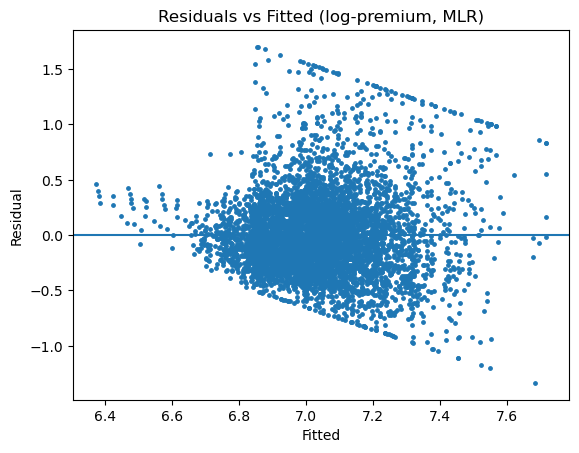

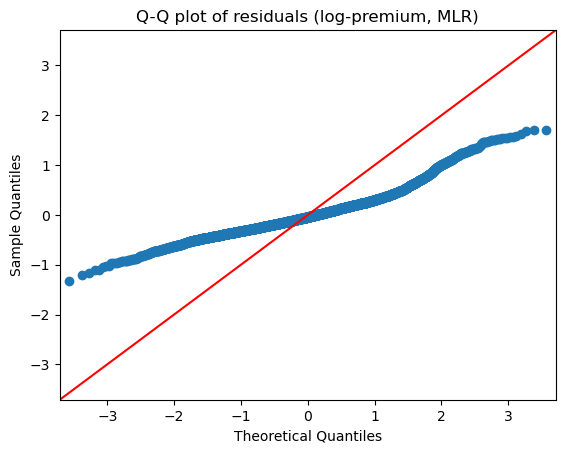


Top 15 coefficients by absolute magnitude (careful: includes dummies):
const                       -220.478280
heat_stress_index             -0.463444
prop_rate                     -0.261884
total_population              -0.146037
yr                             0.113040
real_gdp                       0.107656
Earned Exp                    -0.030721
unemployment_rate             -0.015386
hpi_change                    -0.007487
drought_annual_mean_index     -0.006372
flood_property_damage          0.005246
fire_size                     -0.003541
flood_frequency               -0.001026
fire_frequency                 0.000259
hpi                            0.000127
dtype: float64

Interpretation: +1 unit in hpi_change -> ~-0.75% change in prem_per_unit (holding others fixed).


NameError: name 'data_dir' is not defined

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path


# 2) Basic cleaning + types
# -----------------------------
num_cols = [
    "prem_per_unit","Earned Prem","Earned Exp","hpi_change","hpi",
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index","fire_frequency","fire_size",
    "deaths_hurricane","injuries_hurricane","damage_hurricane",
    "real_gdp","unemployment_rate","prop_rate",
    "total_home_purchase","total_amt_purchase","total_population"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["state"] = df["state"].astype(str)

# keep valid target
df = df.dropna(subset=["prem_per_unit","yr","county_fips5","state"]).copy()
df = df[df["prem_per_unit"] > 0].copy()

# optional: winsorize heavy tail then log-transform target
lo, hi = df["prem_per_unit"].quantile([0.01, 0.99])
df["prem_w"] = df["prem_per_unit"].clip(lo, hi)
df["log_prem_w"] = np.log(df["prem_w"])

print("After cleaning:", df.shape)
print("prem_per_unit 1%/99%:", float(lo), float(hi))

# -----------------------------
# 3) Choose predictors for MLR
#    (Keep it moderate + interpretable)
# -----------------------------
base_predictors = [
    # exposure volume proxy (pricing often varies with risk/portfolio; also stabilizes)
    "Earned Exp",

    # housing market
    "hpi_change", "hpi",

    # macro
    "unemployment_rate", "real_gdp",

    # climate risk
    "flood_frequency", "flood_property_damage",
    "fire_frequency", "fire_size",
    "heat_stress_index", "drought_annual_mean_index",
    "damage_hurricane",

    # controls
    "total_population", "prop_rate"
]

# keep only columns that exist
base_predictors = [c for c in base_predictors if c in df.columns]

# drop rows missing predictors
df_m = df.dropna(subset=base_predictors + ["log_prem_w"]).copy()
print("MLR sample size:", df_m.shape)

# -----------------------------
# 4) Build design matrix with fixed effects (state + year)
# -----------------------------
X_num = df_m[base_predictors].copy()

# log-scale some skewed predictors (optional but often helps)
for c in ["Earned Exp", "real_gdp", "total_population", "flood_property_damage", "damage_hurricane", "fire_size"]:
    if c in X_num.columns:
        X_num[c] = np.log1p(X_num[c])

# add categorical fixed effects
X_cat = pd.get_dummies(df_m[["state", "yr"]].astype({"yr": "int"}), drop_first=True)

X = pd.concat([X_num, X_cat], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem_w"]

# -----------------------------
# 5) Fit MLR with clustered SE (county clusters)
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["county_fips5"]}
)
print(model.summary())

# -----------------------------
# 6) Basic diagnostics (residuals)
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

plt.figure()
plt.scatter(fitted, resid, s=6)
plt.axhline(0)
plt.title("Residuals vs Fitted (log-premium, MLR)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

sm.qqplot(resid, line="45")
plt.title("Q-Q plot of residuals (log-premium, MLR)")
plt.show()

# -----------------------------
# 7) Interpret coefficients (approx % effect)
# -----------------------------
# For log(y): a 1-unit increase in X multiplies y by exp(beta)
# For small beta, it's ~100*beta % change.
coef = model.params.sort_values(key=lambda s: np.abs(s), ascending=False)
print("\nTop 15 coefficients by absolute magnitude (careful: includes dummies):")
print(coef.head(15))

# Example: effect of hpi_change in percent terms (approx)
if "hpi_change" in model.params.index:
    beta = model.params["hpi_change"]
    print(f"\nInterpretation: +1 unit in hpi_change -> ~{100*beta:.2f}% change in prem_per_unit (holding others fixed).")

# -----------------------------
# 8) (Optional) Save fitted values back
# -----------------------------
df_m["pred_log_prem_w"] = fitted
df_m["pred_prem_w"] = np.exp(df_m["pred_log_prem_w"])
out_path = data_dir / "mlr_predictions_logprem.csv"
df_m[[ "yr","ZIP Code","county_fips5","state","prem_per_unit","prem_w","pred_prem_w" ]].to_csv(out_path, index=False)
print("\nSaved:", out_path.resolve())


In [ ]:
cols = ["deaths_hurricane","injuries_hurricane","damage_hurricane"]
tmp = df_m[cols].copy()

print("Non-missing counts:\n", tmp.notna().sum())
print("\nUnique values (up to 10):")
for c in cols:
    print(c, tmp[c].dropna().unique()[:10])

print("\nFraction exactly zero:")
for c in cols:
    s = tmp[c].dropna()
    print(c, float((s == 0).mean()) if len(s) else None)

print("\nStd dev (0 => constant):")
print(tmp.std(numeric_only=True))

print("\nNon-zero row counts:")
for c in cols:
    s = tmp[c].dropna()
    print(c, int((s != 0).sum()))


In [ ]:
df

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path


# 2) Types + cleaning
# -----------------------------
y_col = "prem_per_unit"
df[y_col] = pd.to_numeric(df[y_col], errors="coerce")
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["state"] = df["state"].astype(str)

# keep valid target
df = df.dropna(subset=[y_col, "yr", "county_fips5", "state"]).copy()
df = df[df[y_col] > 0].copy()

# winsorize + log target (helps a LOT)
lo, hi = df[y_col].quantile([0.01, 0.99])
df["prem_w"] = df[y_col].clip(lo, hi)
df["log_prem_w"] = np.log(df["prem_w"])

print("After cleaning:", df.shape)
print("prem_per_unit 1%/99%:", float(lo), float(hi))

# -----------------------------
# 3) Climate-only predictors
# -----------------------------
climate_vars = [
    "flood_frequency", "flood_property_damage", "flood_duration_hours",
    "heat_stress_index", "drought_annual_mean_index",
    "fire_frequency", "fire_size",
    "deaths_hurricane", "injuries_hurricane", "damage_hurricane"
]
climate_vars = [c for c in climate_vars if c in df.columns]

# numeric coercion
for c in climate_vars:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows missing any climate vars
df_m = df.dropna(subset=climate_vars + ["log_prem_w"]).copy()
print("Climate-only MLR sample size:", df_m.shape)
print("Climate vars used:", climate_vars)

# -----------------------------
# 4) Build X: climate vars + state/year FE
# -----------------------------
X_num = df_m[climate_vars].copy()

# log1p transform highly skewed damage/size variables (helps linearity)
for c in ["flood_property_damage", "damage_hurricane", "fire_size", "injuries_hurricane", "deaths_hurricane"]:
    if c in X_num.columns:
        X_num[c] = np.log1p(X_num[c])

X_cat = pd.get_dummies(df_m[["state", "yr"]].astype({"yr": "int"}), drop_first=True)

X = pd.concat([X_num, X_cat], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem_w"]

# -----------------------------
# 5) Fit with clustered SE (county)
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["county_fips5"]}
)
print(model.summary())

# -----------------------------
# 6) Quick diagnostics
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

plt.figure()
plt.scatter(fitted, resid, s=6)
plt.axhline(0)
plt.title("Residuals vs Fitted (climate-only MLR, log-premium)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

sm.qqplot(resid, line="45")
plt.title("Q-Q plot (climate-only MLR, log-premium)")
plt.show()

# -----------------------------
# 7) Interpret climate effects (approx % change)
# -----------------------------
# for log(y): 100*beta ≈ % change for +1 unit X (when beta small)
clim_coefs = model.params[[c for c in model.params.index if c in X_num.columns]]
clim_pvals = model.pvalues[[c for c in model.pvalues.index if c in X_num.columns]]

summary_tbl = pd.DataFrame({
    "beta": clim_coefs,
    "p_value": clim_pvals,
    "approx_%_per_1_unit": 100 * clim_coefs
}).sort_values("p_value")

print("\nClimate coefficients (sorted by p-value):")
print(summary_tbl)

# -----------------------------
# 8) Save fitted values
# -----------------------------
df_m["pred_log_prem_w"] = fitted
df_m["pred_prem_w"] = np.exp(df_m["pred_log_prem_w"])

out_path = data_dir / "mlr_climate_only_predictions.csv"
df_m[["yr","ZIP Code","county_fips5","state","prem_per_unit","prem_w","pred_prem_w"]].to_csv(out_path, index=False)
print("\nSaved:", out_path.resolve())


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import shap

# 2) Drop hurricane features
# -----------------------------
hurr_cols = ["deaths_hurricane", "injuries_hurricane", "damage_hurricane"]
df = df.drop(columns=[c for c in hurr_cols if c in df.columns], errors="ignore")
print("Dropped hurricane cols:", [c for c in hurr_cols if c in df.columns or c in hurr_cols])

# -----------------------------
# 3) Target: prem_per_unit (winsorize + log)
# -----------------------------
y_raw = "prem_per_unit"
df[y_raw] = pd.to_numeric(df[y_raw], errors="coerce")
df = df.dropna(subset=[y_raw]).copy()
df = df[df[y_raw] > 0].copy()

lo, hi = df[y_raw].quantile([0.01, 0.99])
df["prem_w"] = df[y_raw].clip(lo, hi)
df["y_model"] = np.log(df["prem_w"])

print("Target winsor 1%/99%:", float(lo), float(hi))
print("y_model = log(prem_w)")

# -----------------------------
# 4) Feature set: "all variables except hurricane + leakage + identifiers"
# -----------------------------
# Columns you should NOT use as features
drop_features = {
    y_raw, "prem_w", "y_model",
    "Earned Prem",          # leakage into prem_per_unit
    "Unnamed: 0"            # if present
}

# Optional: You may also want to drop ZIP if it's just an ID (high-cardinality).
# We'll keep it OUT by default for interpretability.
high_cardinality_ids = {"ZIP Code"}

# Strongly consider keeping county_fips5 as categorical? Often too many levels -> noisy.
# We'll keep it OUT by default.
other_ids = {"county_fips5", "county_fips"}

drop_features |= high_cardinality_ids | other_ids

feature_cols = [c for c in df.columns if c not in drop_features]
print("Num candidate feature cols:", len(feature_cols))

# Identify categorical vs numeric
# We'll treat "state" as categorical; everything else we'll coerce numeric if possible.
cat_cols = []
if "state" in feature_cols:
    cat_cols.append("state")

# Also treat any remaining object columns as categorical (low-ish cardinality)
obj_cols = [c for c in feature_cols if df[c].dtype == "object" and c != "state"]
cat_cols += obj_cols

num_cols = [c for c in feature_cols if c not in cat_cols]

# Coerce numeric columns
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Numeric cols:", len(num_cols), "| Categorical cols:", len(cat_cols))
print("Categoricals:", cat_cols)

# Keep only needed columns
keep = feature_cols + ["y_model", y_raw, "prem_w"]
df_m = df[keep].copy()

# -----------------------------
# 5) Time-aware split: test=2020, train/val from others
# -----------------------------
if "yr" not in df_m.columns:
    raise ValueError("Expected 'yr' column for time-aware split.")

df_m["yr"] = pd.to_numeric(df_m["yr"], errors="coerce")
df_m = df_m.dropna(subset=["yr"]).copy()

test_year = 2020
test_df = df_m[df_m["yr"] == test_year].copy()
train_all = df_m[df_m["yr"] != test_year].copy()

train_df, val_df = train_test_split(train_all, test_size=0.2, random_state=42)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test(2020):", test_df.shape)

# -----------------------------
# 6) Preprocess
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# -----------------------------
# 7) Model
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=800,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

# Fit
model.fit(train_df[feature_cols], train_df["y_model"].values)

# -----------------------------
# 8) Evaluation
# -----------------------------
def eval_split(name, d):
    X = d[feature_cols]
    y_true_log = d["y_model"].values
    y_pred_log = model.predict(X)

    mse = mean_squared_error(y_true_log, y_pred_log)
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true_log, y_pred_log))
    r2 = float(r2_score(y_true_log, y_pred_log))

    print(f"\n=== {name} (log scale) ===")
    print("N:", len(d))
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    prem_pred = np.exp(y_pred_log)
    prem_true = np.exp(y_true_log)

    mse_p = mean_squared_error(prem_true, prem_pred)
    rmse_p = float(np.sqrt(mse_p))
    mae_p = float(mean_absolute_error(prem_true, prem_pred))
    r2_p = float(r2_score(prem_true, prem_pred))

    print(f"=== {name} (premium scale) ===")
    print("RMSE:", rmse_p)
    print("MAE :", mae_p)
    print("R2  :", r2_p)

    return y_pred_log

_ = eval_split("TRAIN", train_df)
_ = eval_split("VAL", val_df)
y_pred_test_log = eval_split("TEST (2020)", test_df)

# -----------------------------
# 9) SHAP (TreeExplainer) on test sample
# -----------------------------
pre = model.named_steps["preprocess"]
rf_fitted = model.named_steps["rf"]

X_test = test_df[feature_cols]
X_test_trans = pre.transform(X_test)

# feature names after preprocessing
num_names = num_cols
cat_names = []
if len(cat_cols) > 0:
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(cat_cols).tolist()
feature_names = num_names + cat_names

# sample for speed
n_shap = min(1500, X_test_trans.shape[0])
rng = np.random.RandomState(42)
idx = rng.choice(X_test_trans.shape[0], size=n_shap, replace=False)
X_shap = X_test_trans[idx]

explainer = shap.TreeExplainer(rf_fitted)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, feature_names=feature_names)
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar")

# -----------------------------
# 10) Save predictions
# -----------------------------
out = test_df.copy()
out["pred_log_prem"] = y_pred_test_log
out["pred_prem"] = np.exp(out["pred_log_prem"])

out_path = data_dir / "rf_all_nonhurricane_preds_2020.csv"
out.to_csv(out_path, index=False)
print("\nSaved:", out_path.resolve())


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence

from pathlib import Path

# -----------------------------
# 2) Drop hurricane features
# -----------------------------
hurr_cols = ["deaths_hurricane", "injuries_hurricane", "damage_hurricane"]
df = df.drop(columns=[c for c in hurr_cols if c in df.columns], errors="ignore")

# -----------------------------
# 3) Coerce types
# -----------------------------
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["Earned Prem"] = pd.to_numeric(df.get("Earned Prem"), errors="coerce")
df["Earned Exp"]  = pd.to_numeric(df.get("Earned Exp"),  errors="coerce")

# numeric coercion for likely numeric covariates (skip if absent)
numeric_candidates = [
    "hpi_change","hpi","flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index","fire_frequency","fire_size",
    "real_gdp","unemployment_rate","prop_rate",
    "total_home_purchase","total_amt_purchase","total_population"
]
for c in numeric_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["state"] = df["state"].astype(str)

# -----------------------------
# 4) Aggregate to county-year
# -----------------------------
id_cols = ["county_fips5", "state", "yr"]

# Keep only rows with keys and earned components (needed to form premium)
df_agg_base = df.dropna(subset=id_cols + ["Earned Prem", "Earned Exp"]).copy()
df_agg_base = df_agg_base[df_agg_base["Earned Exp"] > 0].copy()

# For county-year covariates: they should be identical within a county-year.
# We take "first" after aggregation. If you worry about minor discrepancies,
# you can switch to "mean" for continuous covariates.
cov_cols = [c for c in numeric_candidates if c in df_agg_base.columns]

agg_dict = {
    "Earned Prem": "sum",
    "Earned Exp": "sum",
}
for c in cov_cols:
    agg_dict[c] = "first"

county_year = df_agg_base.groupby(id_cols, as_index=False).agg(agg_dict)

county_year["prem_per_unit"] = county_year["Earned Prem"] / county_year["Earned Exp"]

print("\nAggregated county-year shape:", county_year.shape)
print("Unique county-years:", county_year.shape[0])
print("Year range:", int(county_year["yr"].min()), "to", int(county_year["yr"].max()))

# sanity: no duplicates
dups = county_year.duplicated(subset=["county_fips5","yr"]).sum()
print("Duplicate (county,yr) after aggregation:", int(dups))

# -----------------------------
# 5) Build target: winsorize + log
# -----------------------------
y_raw = "prem_per_unit"
county_year = county_year.dropna(subset=[y_raw]).copy()
county_year = county_year[county_year[y_raw] > 0].copy()

lo, hi = county_year[y_raw].quantile([0.01, 0.99])
county_year["prem_w"] = county_year[y_raw].clip(lo, hi)
county_year["log_prem_w"] = np.log(county_year["prem_w"])

print("\nTarget winsor 1%/99%:", float(lo), float(hi))
print("Target used in regression: log_prem_w")

# -----------------------------
# 6) Choose MLR predictors (all non-hurricane covariates you have)
#     Keep it interpretable: climate + macro + housing + population + prop_rate
# -----------------------------
predictors = [
    # housing/market
    "hpi", "hpi_change",
    "total_population", "prop_rate",
    "total_home_purchase", "total_amt_purchase",

    # macro
    "unemployment_rate", "real_gdp",

    # climate
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size",

    # time trend
    "yr"
]
predictors = [c for c in predictors if c in county_year.columns]

df_m = county_year.dropna(subset=["log_prem_w"] + predictors + ["county_fips5"]).copy()
print("\nMLR sample size:", df_m.shape)
print("Predictors:", predictors)

# Optional: log1p transform skewed predictors for linearity
for c in ["real_gdp","total_population","total_amt_purchase","total_home_purchase",
          "flood_property_damage","fire_size"]:
    if c in df_m.columns:
        df_m[c] = np.log1p(df_m[c])

# Add state fixed effects (important for P&C pricing differences)
X_num = df_m[predictors].copy()
X_state = pd.get_dummies(df_m["state"], prefix="state", drop_first=True)
X = pd.concat([X_num, X_state], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem_w"]

# -----------------------------
# 7) Fit OLS with clustered SE by county (panel-safe inference)
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["county_fips5"]}
)
print("\n========== MLR (county-year) on log premium ==========")
print(model.summary())

# -----------------------------
# 8) Assumption checks (same style as before)
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

# 8.1 Residuals vs fitted (homoscedasticity + functional form)
plt.figure()
plt.scatter(fitted, resid, s=8)
plt.axhline(0)
plt.title("Residuals vs Fitted (county-year MLR, log premium)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

# 8.2 Q-Q plot (normality check for inference)
sm.qqplot(resid, line="45")
plt.title("Q-Q plot of residuals (county-year MLR, log premium)")
plt.show()

# 8.3 Breusch–Pagan test (heteroskedasticity)
bp = het_breuschpagan(resid, X)
bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print("\nBreusch–Pagan test (heteroskedasticity):")
print(dict(zip(bp_labels, bp)))

# 8.4 Durbin–Watson (serial correlation indicator)
dw = durbin_watson(resid)
print("\nDurbin–Watson (~2 good; <2 indicates positive autocorrelation):", float(dw))

# 8.5 Influence / outliers (Cook's distance)
infl = OLSInfluence(model)
cooks_d = infl.cooks_distance[0]

top_k = 15
top_idx = np.argsort(cooks_d)[-top_k:][::-1]

print(f"\nTop {top_k} influential county-years by Cook's distance:")
show_cols = ["county_fips5","state","yr","prem_per_unit","prem_w","log_prem_w"] + predictors
show_cols = [c for c in show_cols if c in df_m.columns]
print(df_m.iloc[top_idx][show_cols].assign(cooks_d=cooks_d[top_idx]).head(top_k))

plt.figure()
plt.stem(cooks_d, markerfmt=",", basefmt=" ")
plt.title("Cook's distance (county-year MLR)")
plt.xlabel("Row index")
plt.ylabel("Cook's D")
plt.show()



In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence

from pathlib import Path


# -----------------------------
# 2) Drop hurricane features
# -----------------------------
hurr_cols = ["deaths_hurricane", "injuries_hurricane", "damage_hurricane"]
df = df.drop(columns=[c for c in hurr_cols if c in df.columns], errors="ignore")

# -----------------------------
# 3) Coerce types
# -----------------------------
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["Earned Prem"] = pd.to_numeric(df.get("Earned Prem"), errors="coerce")
df["Earned Exp"]  = pd.to_numeric(df.get("Earned Exp"),  errors="coerce")
df["state"] = df["state"].astype(str)

numeric_candidates = [
    "hpi_change","hpi",
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size",
    "real_gdp","unemployment_rate","prop_rate",
    "total_home_purchase","total_amt_purchase","total_population"
]
for c in numeric_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------
# 4) Aggregate ZIP -> county-year
# -----------------------------
id_cols = ["county_fips5", "state", "yr"]
base = df.dropna(subset=id_cols + ["Earned Prem","Earned Exp"]).copy()
base = base[base["Earned Exp"] > 0].copy()

cov_cols = [c for c in numeric_candidates if c in base.columns]
agg_dict = {"Earned Prem": "sum", "Earned Exp": "sum"}
for c in cov_cols:
    agg_dict[c] = "first"  # county-year covariates should be identical across ZIPs

cy = base.groupby(id_cols, as_index=False).agg(agg_dict)
cy["prem_per_unit"] = cy["Earned Prem"] / cy["Earned Exp"]

print("\nCounty-year shape:", cy.shape)
print("Duplicate (county,yr):", int(cy.duplicated(["county_fips5","yr"]).sum()))

# -----------------------------
# 5) LOG target (no winsor by default)
#    If you want winsor+log, flip USE_WINSOR=True
# -----------------------------
USE_WINSOR = False

cy = cy.dropna(subset=["prem_per_unit"]).copy()
cy = cy[cy["prem_per_unit"] > 0].copy()

if USE_WINSOR:
    lo, hi = cy["prem_per_unit"].quantile([0.01, 0.99])
    cy["prem_use"] = cy["prem_per_unit"].clip(lo, hi)
    print("Winsor 1%/99%:", float(lo), float(hi))
else:
    cy["prem_use"] = cy["prem_per_unit"]

cy["log_prem"] = np.log(cy["prem_use"])

print("Target used: log_prem = log(prem_use)")
print(cy["log_prem"].describe())

# -----------------------------
# 6) MLR predictors (edit as you like)
# -----------------------------
predictors = [
    # housing/market
    "hpi", "hpi_change",
    "total_population", "prop_rate",
    "total_home_purchase", "total_amt_purchase",

    # macro
    "unemployment_rate", "real_gdp",

    # climate
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size",

    # year trend
    "yr"
]
predictors = [c for c in predictors if c in cy.columns]

df_m = cy.dropna(subset=["log_prem"] + predictors + ["county_fips5","state"]).copy()
print("\nMLR sample size:", df_m.shape)
print("Predictors:", predictors)

# Optional transforms for skewed Xs (helps linearity)
for c in ["real_gdp","total_population","total_amt_purchase","total_home_purchase",
          "flood_property_damage","fire_size"]:
    if c in df_m.columns:
        df_m[c] = np.log1p(df_m[c])

# Build X with state FE
X_num = df_m[predictors].copy()
X_state = pd.get_dummies(df_m["state"], prefix="state", drop_first=True)
X = pd.concat([X_num, X_state], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem"]

# -----------------------------
# 7) Fit OLS with clustered SE by county
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["county_fips5"]}
)

print("\n========== County-year MLR on log(prem_per_unit) ==========")
print(model.summary())





County-year shape: (174, 21)
Duplicate (county,yr): 0
Target used: log_prem = log(prem_use)
count    174.000000
mean       7.000871
std        0.226460
min        6.534352
25%        6.836237
50%        6.998382
75%        7.137573
max        7.617796
Name: log_prem, dtype: float64

MLR sample size: (174, 23)
Predictors: ['hpi', 'hpi_change', 'total_population', 'prop_rate', 'total_home_purchase', 'total_amt_purchase', 'unemployment_rate', 'real_gdp', 'flood_frequency', 'flood_property_damage', 'flood_duration_hours', 'heat_stress_index', 'drought_annual_mean_index', 'fire_frequency', 'fire_size', 'yr']

========== County-year MLR on log(prem_per_unit) ==========
                            OLS Regression Results                            
Dep. Variable:               log_prem   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     34.45
Date:      

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X):
    Xv = X.copy()

    # Drop intercept/constant if present
    if "const" in Xv.columns:
        Xv = Xv.drop(columns=["const"])

    # VIF needs purely numeric + no infs
    Xv = Xv.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    vif = pd.DataFrame({
        "feature": Xv.columns,
        "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]
    }).sort_values("VIF", ascending=False)

    return vif

vif_df = compute_vif(X)
print(vif_df.head(30))


                      feature           VIF
5          total_amt_purchase  19204.636398
15                         yr   8525.600063
2            total_population   5459.241635
4         total_home_purchase   4335.546457
7                    real_gdp   3971.839956
3                   prop_rate    984.821136
0                         hpi     47.248391
11          heat_stress_index     22.065340
14                  fire_size      9.627500
6           unemployment_rate      8.719767
1                  hpi_change      3.339539
13             fire_frequency      2.723801
8             flood_frequency      2.214981
9       flood_property_damage      2.079571
12  drought_annual_mean_index      1.987821
10       flood_duration_hours      1.866110


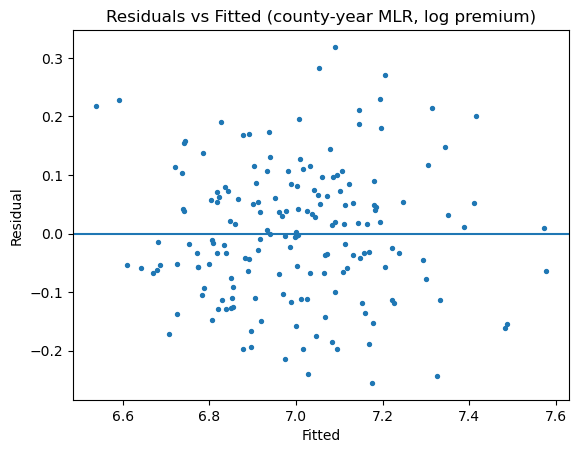

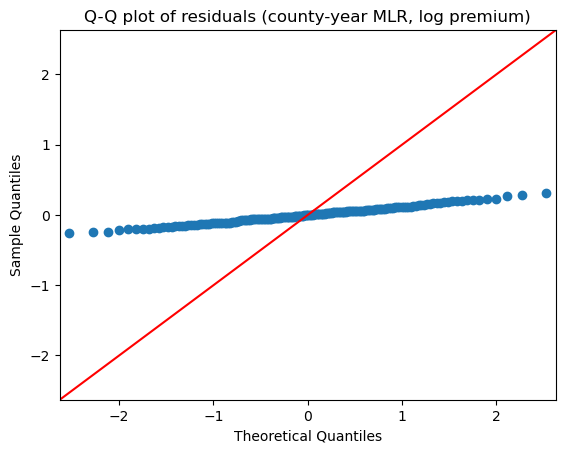


Breusch–Pagan test (heteroskedasticity):
{'LM stat': 28.60550213289334, 'LM p-value': 0.026735979215726968, 'F stat': 1.9305509754266859, 'F p-value': 0.021223920695072812}

Durbin–Watson (~2 good; <2 indicates positive autocorrelation): 0.9280272919131004

Top 15 influential county-years by Cook's distance:
     county_fips5       state    yr  prem_per_unit     prem_use  log_prem  \
37         6025.0  CALIFORNIA  2019     914.960832   914.960832  6.818881   
36         6025.0  CALIFORNIA  2018     858.633550   858.633550  6.755342   
113        6075.0  CALIFORNIA  2020    1859.700815  1859.700815  7.528171   
112        6075.0  CALIFORNIA  2019    1675.219153  1675.219153  7.423699   
40         6027.0  CALIFORNIA  2019    1011.636283  1011.636283  6.919324   
111        6075.0  CALIFORNIA  2018    1564.589424  1564.589424  7.355379   
128        6085.0  CALIFORNIA  2020    1189.707639  1189.707639  7.081463   
145        6097.0  CALIFORNIA  2019    1095.415674  1095.415674  6.998889

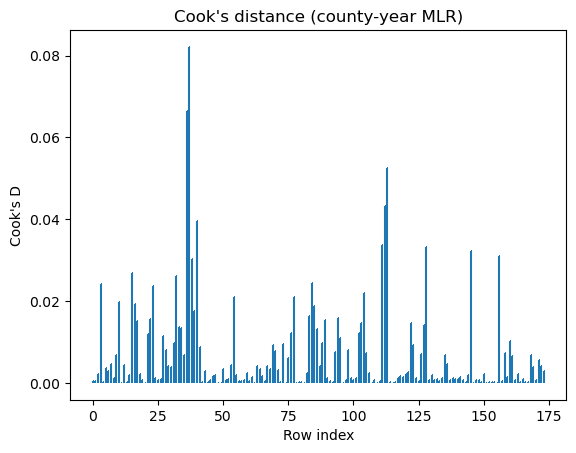

In [30]:
# -----------------------------
# 8) Assumption checks
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

# Residuals vs fitted
plt.figure()
plt.scatter(fitted, resid, s=8)
plt.axhline(0)
plt.title("Residuals vs Fitted (county-year MLR, log premium)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

# Q-Q plot
sm.qqplot(resid, line="45")
plt.title("Q-Q plot of residuals (county-year MLR, log premium)")
plt.show()

# Breusch–Pagan
bp = het_breuschpagan(resid, X)
bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print("\nBreusch–Pagan test (heteroskedasticity):")
print(dict(zip(bp_labels, bp)))

# Durbin–Watson
dw = durbin_watson(resid)
print("\nDurbin–Watson (~2 good; <2 indicates positive autocorrelation):", float(dw))

# Cook's distance (influence)
infl = OLSInfluence(model)
cooks_d = infl.cooks_distance[0]

top_k = 15
top_idx = np.argsort(cooks_d)[-top_k:][::-1]

print(f"\nTop {top_k} influential county-years by Cook's distance:")
cols_to_show = ["county_fips5","state","yr","prem_per_unit","prem_use","log_prem"] + predictors
cols_to_show = [c for c in cols_to_show if c in df_m.columns]
print(df_m.iloc[top_idx][cols_to_show].assign(cooks_d=cooks_d[top_idx]).head(top_k))

plt.figure()
plt.stem(cooks_d, markerfmt=",", basefmt=" ")
plt.title("Cook's distance (county-year MLR)")
plt.xlabel("Row index")
plt.ylabel("Cook's D")
plt.show()

In [32]:
# Rebuild X pieces (same as your model)
X_num = df_m[predictors].copy()
X_state = pd.get_dummies(df_m["state"], prefix="state", drop_first=True)
X_full = pd.concat([X_num, X_state], axis=1)

corr_full = X_full.corr(method="pearson")

print("\nCorrelation (full X, incl. state dummies) — showing top pairs only:")

corr_pairs_full = (
    corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
    .stack()
    .rename("corr")
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2"})
)
corr_pairs_full["abs_corr"] = corr_pairs_full["corr"].abs()
corr_pairs_full = corr_pairs_full.sort_values("abs_corr", ascending=False)

print(corr_pairs_full.head(50).round(3))



Correlation (full X, incl. state dummies) — showing top pairs only:
                          var1                       var2   corr  abs_corr
30            total_population        total_home_purchase  0.985     0.985
54         total_home_purchase         total_amt_purchase  0.982     0.982
33            total_population                   real_gdp  0.979     0.979
31            total_population         total_amt_purchase  0.977     0.977
66          total_amt_purchase                   real_gdp  0.975     0.975
56         total_home_purchase                   real_gdp  0.953     0.953
6                          hpi                   real_gdp  0.784     0.784
4                          hpi         total_amt_purchase  0.759     0.759
1                          hpi           total_population  0.694     0.694
43                   prop_rate         total_amt_purchase  0.691     0.691
42                   prop_rate        total_home_purchase  0.689     0.689
45                   prop_rate 

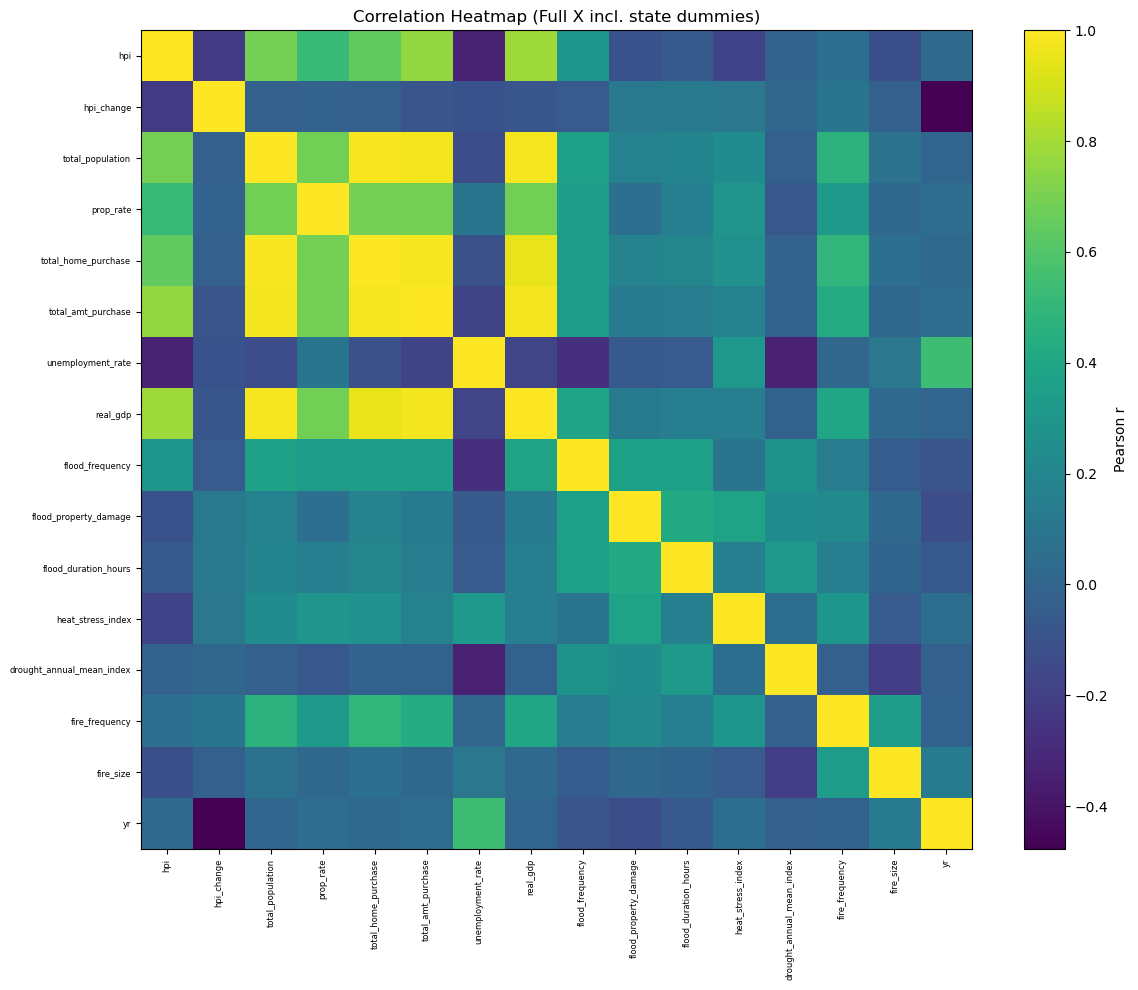

In [34]:
import matplotlib.pyplot as plt

# If X_full is very wide (many states), this will be unreadable.
# Consider plotting climate-only instead (see note below).
plt.figure(figsize=(12, 10))
plt.imshow(corr_full.values, aspect="auto")
plt.xticks(range(len(corr_full.columns)), corr_full.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr_full.index)), corr_full.index, fontsize=6)
plt.colorbar(label="Pearson r")
plt.title("Correlation Heatmap (Full X incl. state dummies)")
plt.tight_layout()
plt.show()


In [22]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# -----------------------------
# 2) Drop hurricane features
# -----------------------------
hurr_cols = ["deaths_hurricane", "injuries_hurricane", "damage_hurricane"]
df = df.drop(columns=[c for c in hurr_cols if c in df.columns], errors="ignore")

# -----------------------------
# 3) Coerce types
# -----------------------------
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["Earned Prem"] = pd.to_numeric(df.get("Earned Prem"), errors="coerce")
df["Earned Exp"]  = pd.to_numeric(df.get("Earned Exp"),  errors="coerce")
df["state"] = df["state"].astype(str)

climate_candidates = [
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size"
]
for c in climate_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------
# 4) Aggregate ZIP -> county-year
# -----------------------------
id_cols = ["county_fips5", "state", "yr"]  # keep yr for grouping, but NOT as a predictor
base = df.dropna(subset=id_cols + ["Earned Prem","Earned Exp"]).copy()
base = base[base["Earned Exp"] > 0].copy()

cov_cols = [c for c in climate_candidates if c in base.columns]
agg_dict = {"Earned Prem": "sum", "Earned Exp": "sum"}
for c in cov_cols:
    agg_dict[c] = "first"  # assumes identical across ZIPs within county-year

cy = base.groupby(id_cols, as_index=False).agg(agg_dict)
cy["prem_per_unit"] = cy["Earned Prem"] / cy["Earned Exp"]

# -----------------------------
# 5) LOG target
# -----------------------------
cy = cy.dropna(subset=["prem_per_unit"]).copy()
cy = cy[cy["prem_per_unit"] > 0].copy()
cy["log_prem"] = np.log(cy["prem_per_unit"])

# -----------------------------
# 6) Climate predictors ONLY (yr dropped)
# -----------------------------
predictors = [c for c in climate_candidates if c in cy.columns]

df_m = cy.dropna(subset=["log_prem"] + predictors + ["county_fips5","state"]).copy()
print("MLR sample size:", df_m.shape)
print("Predictors:", predictors)

# Optional transforms for skewed climate severity vars
for c in ["flood_property_damage","fire_size"]:
    if c in df_m.columns:
        df_m[c] = np.log1p(df_m[c])

# Build X with state FE (keep this if you want to control for state pricing level differences)
X_num = df_m[predictors].copy()
X_state = pd.get_dummies(df_m["state"], prefix="state", drop_first=True)
X = pd.concat([X_num, X_state], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem"]

# -----------------------------
# VIF
# -----------------------------
def compute_vif(X):
    Xv = X.copy()
    if "const" in Xv.columns:
        Xv = Xv.drop(columns=["const"])
    Xv = Xv.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    return (pd.DataFrame({
        "feature": Xv.columns,
        "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]
    }).sort_values("VIF", ascending=False))

vif_df = compute_vif(X)
print("\nTop VIFs:")
print(vif_df.head(25))

# -----------------------------
# 7) Fit OLS with clustered SE by county
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["county_fips5"]}
)

print("\n========== Climate-only County-year MLR (NO yr) on log(prem_per_unit) ==========")
print(model.summary())


MLR sample size: (174, 14)
Predictors: ['flood_frequency', 'flood_property_damage', 'flood_duration_hours', 'heat_stress_index', 'drought_annual_mean_index', 'fire_frequency', 'fire_size']

Top VIFs:
                     feature       VIF
3          heat_stress_index  5.254066
6                  fire_size  5.227540
5             fire_frequency  1.869772
1      flood_property_damage  1.786084
4  drought_annual_mean_index  1.699815
0            flood_frequency  1.633918
2       flood_duration_hours  1.599922

========== Climate-only County-year MLR (NO yr) on log(prem_per_unit) ==========
                            OLS Regression Results                            
Dep. Variable:               log_prem   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     7.568
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           1.96e-06
Time:      

In [ ]:
# -----------------------------
# 8) Assumption checks
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

# Residuals vs fitted
plt.figure()
plt.scatter(fitted, resid, s=8)
plt.axhline(0)
plt.title("Residuals vs Fitted (county-year MLR, log premium)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

# Q-Q plot
sm.qqplot(resid, line="45")
plt.title("Q-Q plot of residuals (county-year MLR, log premium)")
plt.show()

# Breusch–Pagan
bp = het_breuschpagan(resid, X)
bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print("\nBreusch–Pagan test (heteroskedasticity):")
print(dict(zip(bp_labels, bp)))

# Durbin–Watson
dw = durbin_watson(resid)
print("\nDurbin–Watson (~2 good; <2 indicates positive autocorrelation):", float(dw))

# Cook's distance (influence)
infl = OLSInfluence(model)
cooks_d = infl.cooks_distance[0]

top_k = 15
top_idx = np.argsort(cooks_d)[-top_k:][::-1]

print(f"\nTop {top_k} influential county-years by Cook's distance:")
cols_to_show = ["county_fips5","state","yr","prem_per_unit","prem_use","log_prem"] + predictors
cols_to_show = [c for c in cols_to_show if c in df_m.columns]
print(df_m.iloc[top_idx][cols_to_show].assign(cooks_d=cooks_d[top_idx]).head(top_k))

plt.figure()
plt.stem(cooks_d, markerfmt=",", basefmt=" ")
plt.title("Cook's distance (county-year MLR)")
plt.xlabel("Row index")
plt.ylabel("Cook's D")
plt.show()

Winsor 1%/99%: 571.7662565339767 5190.254651625734
Target used: log_prem = log(prem_use)
count    5549.000000
mean        7.040384
std         0.403639
min         6.348730
25%         6.754459
50%         6.980785
75%         7.237032
max         8.554538
Name: log_prem, dtype: float64

MLR sample size: (5549, 27)
Predictors: ['Earned Exp', 'hpi', 'hpi_change', 'total_population', 'prop_rate', 'total_home_purchase', 'total_amt_purchase', 'unemployment_rate', 'real_gdp', 'flood_frequency', 'flood_property_damage', 'flood_duration_hours', 'heat_stress_index', 'drought_annual_mean_index', 'fire_frequency', 'fire_size', 'yr']

========== ZIP-year MLR on log(prem_per_unit) ==========
                            OLS Regression Results                            
Dep. Variable:               log_prem   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     1

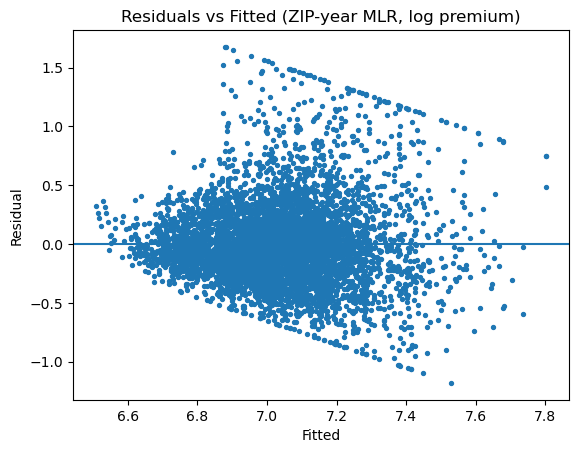

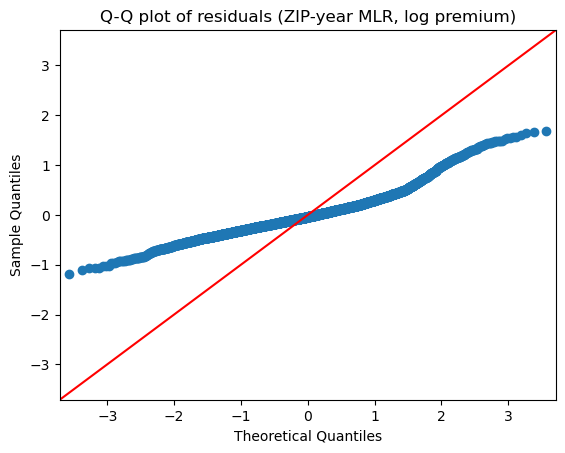


Breusch–Pagan test (heteroskedasticity):
{'LM stat': 857.8047318846345, 'LM p-value': 2.153806349251273e-171, 'F stat': 59.49214997948286, 'F p-value': 8.037353275288027e-187}

Durbin–Watson (~2 good; <2 indicates positive autocorrelation): 0.6497467795441687

Top 15 influential ZIP-years by Cook's distance:
      ZIP Code  county_fips5       state    yr  prem_per_unit     prem_use  \
4249     95402        6097.0  CALIFORNIA  2019   13021.000000  5190.254652   
3174     94158        6075.0  CALIFORNIA  2020     472.800000   571.766257   
3144     94123        6075.0  CALIFORNIA  2020    5171.018232  5171.018232   
3123     94115        6075.0  CALIFORNIA  2020    6452.941414  5190.254652   
1282     92235        6065.0  CALIFORNIA  2020    5979.000000  5190.254652   
2762     93642        6019.0  CALIFORNIA  2019    3077.000000  3077.000000   
3108     94109        6075.0  CALIFORNIA  2020    5043.259197  5043.259197   
3121     94115        6075.0  CALIFORNIA  2018    5340.996545  51

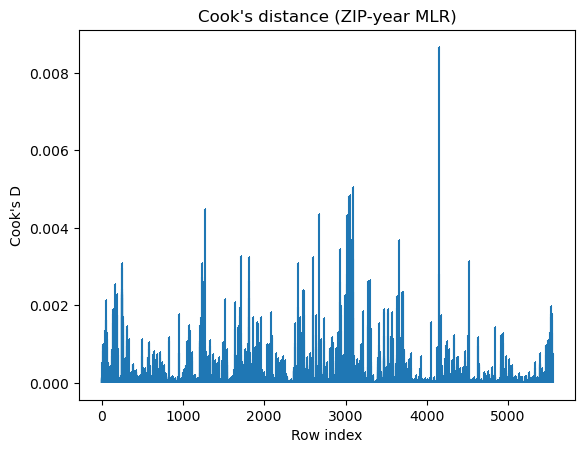

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence

from pathlib import Path

# -----------------------------
# 2) Drop hurricane features
# -----------------------------
hurr_cols = ["deaths_hurricane", "injuries_hurricane", "damage_hurricane"]
df = df.drop(columns=[c for c in hurr_cols if c in df.columns], errors="ignore")

# -----------------------------
# 3) Coerce types
# -----------------------------
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["ZIP Code"] = pd.to_numeric(df["ZIP Code"], errors="coerce")  # keep numeric zip id
df["Earned Exp"] = pd.to_numeric(df.get("Earned Exp"), errors="coerce")
df["Earned Prem"] = pd.to_numeric(df.get("Earned Prem"), errors="coerce")
df["state"] = df["state"].astype(str)

numeric_candidates = [
    "prem_per_unit",
    "hpi_change","hpi",
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size",
    "real_gdp","unemployment_rate","prop_rate",
    "total_home_purchase","total_amt_purchase","total_population"
]
for c in numeric_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------
# 4) Ensure prem_per_unit exists (no leakage in X later)
# -----------------------------
if "prem_per_unit" not in df.columns or df["prem_per_unit"].isna().all():
    if ("Earned Prem" in df.columns) and ("Earned Exp" in df.columns):
        df["prem_per_unit"] = df["Earned Prem"] / df["Earned Exp"]
    else:
        raise ValueError("prem_per_unit missing and cannot be constructed (need Earned Prem and Earned Exp).")

# basic target cleaning
df = df.dropna(subset=["prem_per_unit", "yr", "ZIP Code", "state"]).copy()
df = df[df["prem_per_unit"] > 0].copy()

# -----------------------------
# 5) LOG target (optionally winsorize first)
# -----------------------------
USE_WINSOR = True  # set False if you want pure log without clipping

if USE_WINSOR:
    lo, hi = df["prem_per_unit"].quantile([0.01, 0.99])
    df["prem_use"] = df["prem_per_unit"].clip(lo, hi)
    print("Winsor 1%/99%:", float(lo), float(hi))
else:
    df["prem_use"] = df["prem_per_unit"]

df["log_prem"] = np.log(df["prem_use"])
print("Target used: log_prem = log(prem_use)")
print(df["log_prem"].describe())

# -----------------------------
# 6) MLR predictors (ZIP-year level)
#    Exclude Earned Prem (leakage); Earned Exp is OK as exposure/size control.
# -----------------------------
predictors = [
    # exposure / portfolio size (OK)
    "Earned Exp",

    # housing/market
    "hpi", "hpi_change",
    "total_population", "prop_rate",
    "total_home_purchase", "total_amt_purchase",

    # macro
    "unemployment_rate", "real_gdp",

    # climate
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size",

    # time trend
    "yr"
]
predictors = [c for c in predictors if c in df.columns]

df_m = df.dropna(subset=["log_prem"] + predictors).copy()
print("\nMLR sample size:", df_m.shape)
print("Predictors:", predictors)

# Optional transforms for skewed Xs (helps linearity)
for c in ["real_gdp","total_population","total_amt_purchase","total_home_purchase",
          "flood_property_damage","fire_size","Earned Exp"]:
    if c in df_m.columns:
        df_m[c] = np.log1p(df_m[c])

# Build X with state fixed effects
X_num = df_m[predictors].copy()
X_state = pd.get_dummies(df_m["state"], prefix="state", drop_first=True)
X = pd.concat([X_num, X_state], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem"]

# -----------------------------
# 7) Fit OLS with clustered SE by ZIP (panel-safe inference)
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["ZIP Code"]}
)

print("\n========== ZIP-year MLR on log(prem_per_unit) ==========")
print(model.summary())

# -----------------------------
# 8) Assumption checks
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

# Residuals vs fitted
plt.figure()
plt.scatter(fitted, resid, s=8)
plt.axhline(0)
plt.title("Residuals vs Fitted (ZIP-year MLR, log premium)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

# Q-Q plot
sm.qqplot(resid, line="45")
plt.title("Q-Q plot of residuals (ZIP-year MLR, log premium)")
plt.show()

# Breusch–Pagan (on OLS residuals; inference uses clustered SE anyway)
bp = het_breuschpagan(resid, X)
bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print("\nBreusch–Pagan test (heteroskedasticity):")
print(dict(zip(bp_labels, bp)))

# Durbin–Watson (serial correlation indicator; panel data usually <2)
dw = durbin_watson(resid)
print("\nDurbin–Watson (~2 good; <2 indicates positive autocorrelation):", float(dw))

# Cook's distance (influence)
infl = OLSInfluence(model)
cooks_d = infl.cooks_distance[0]

top_k = 15
top_idx = np.argsort(cooks_d)[-top_k:][::-1]

print(f"\nTop {top_k} influential ZIP-years by Cook's distance:")
cols_to_show = ["ZIP Code","county_fips5","state","yr","prem_per_unit","prem_use","log_prem"] + predictors
cols_to_show = [c for c in cols_to_show if c in df_m.columns]
print(df_m.iloc[top_idx][cols_to_show].assign(cooks_d=cooks_d[top_idx]).head(top_k))

plt.figure()
plt.stem(cooks_d, markerfmt=",", basefmt=" ")
plt.title("Cook's distance (ZIP-year MLR)")
plt.xlabel("Row index")
plt.ylabel("Cook's D")
plt.show()



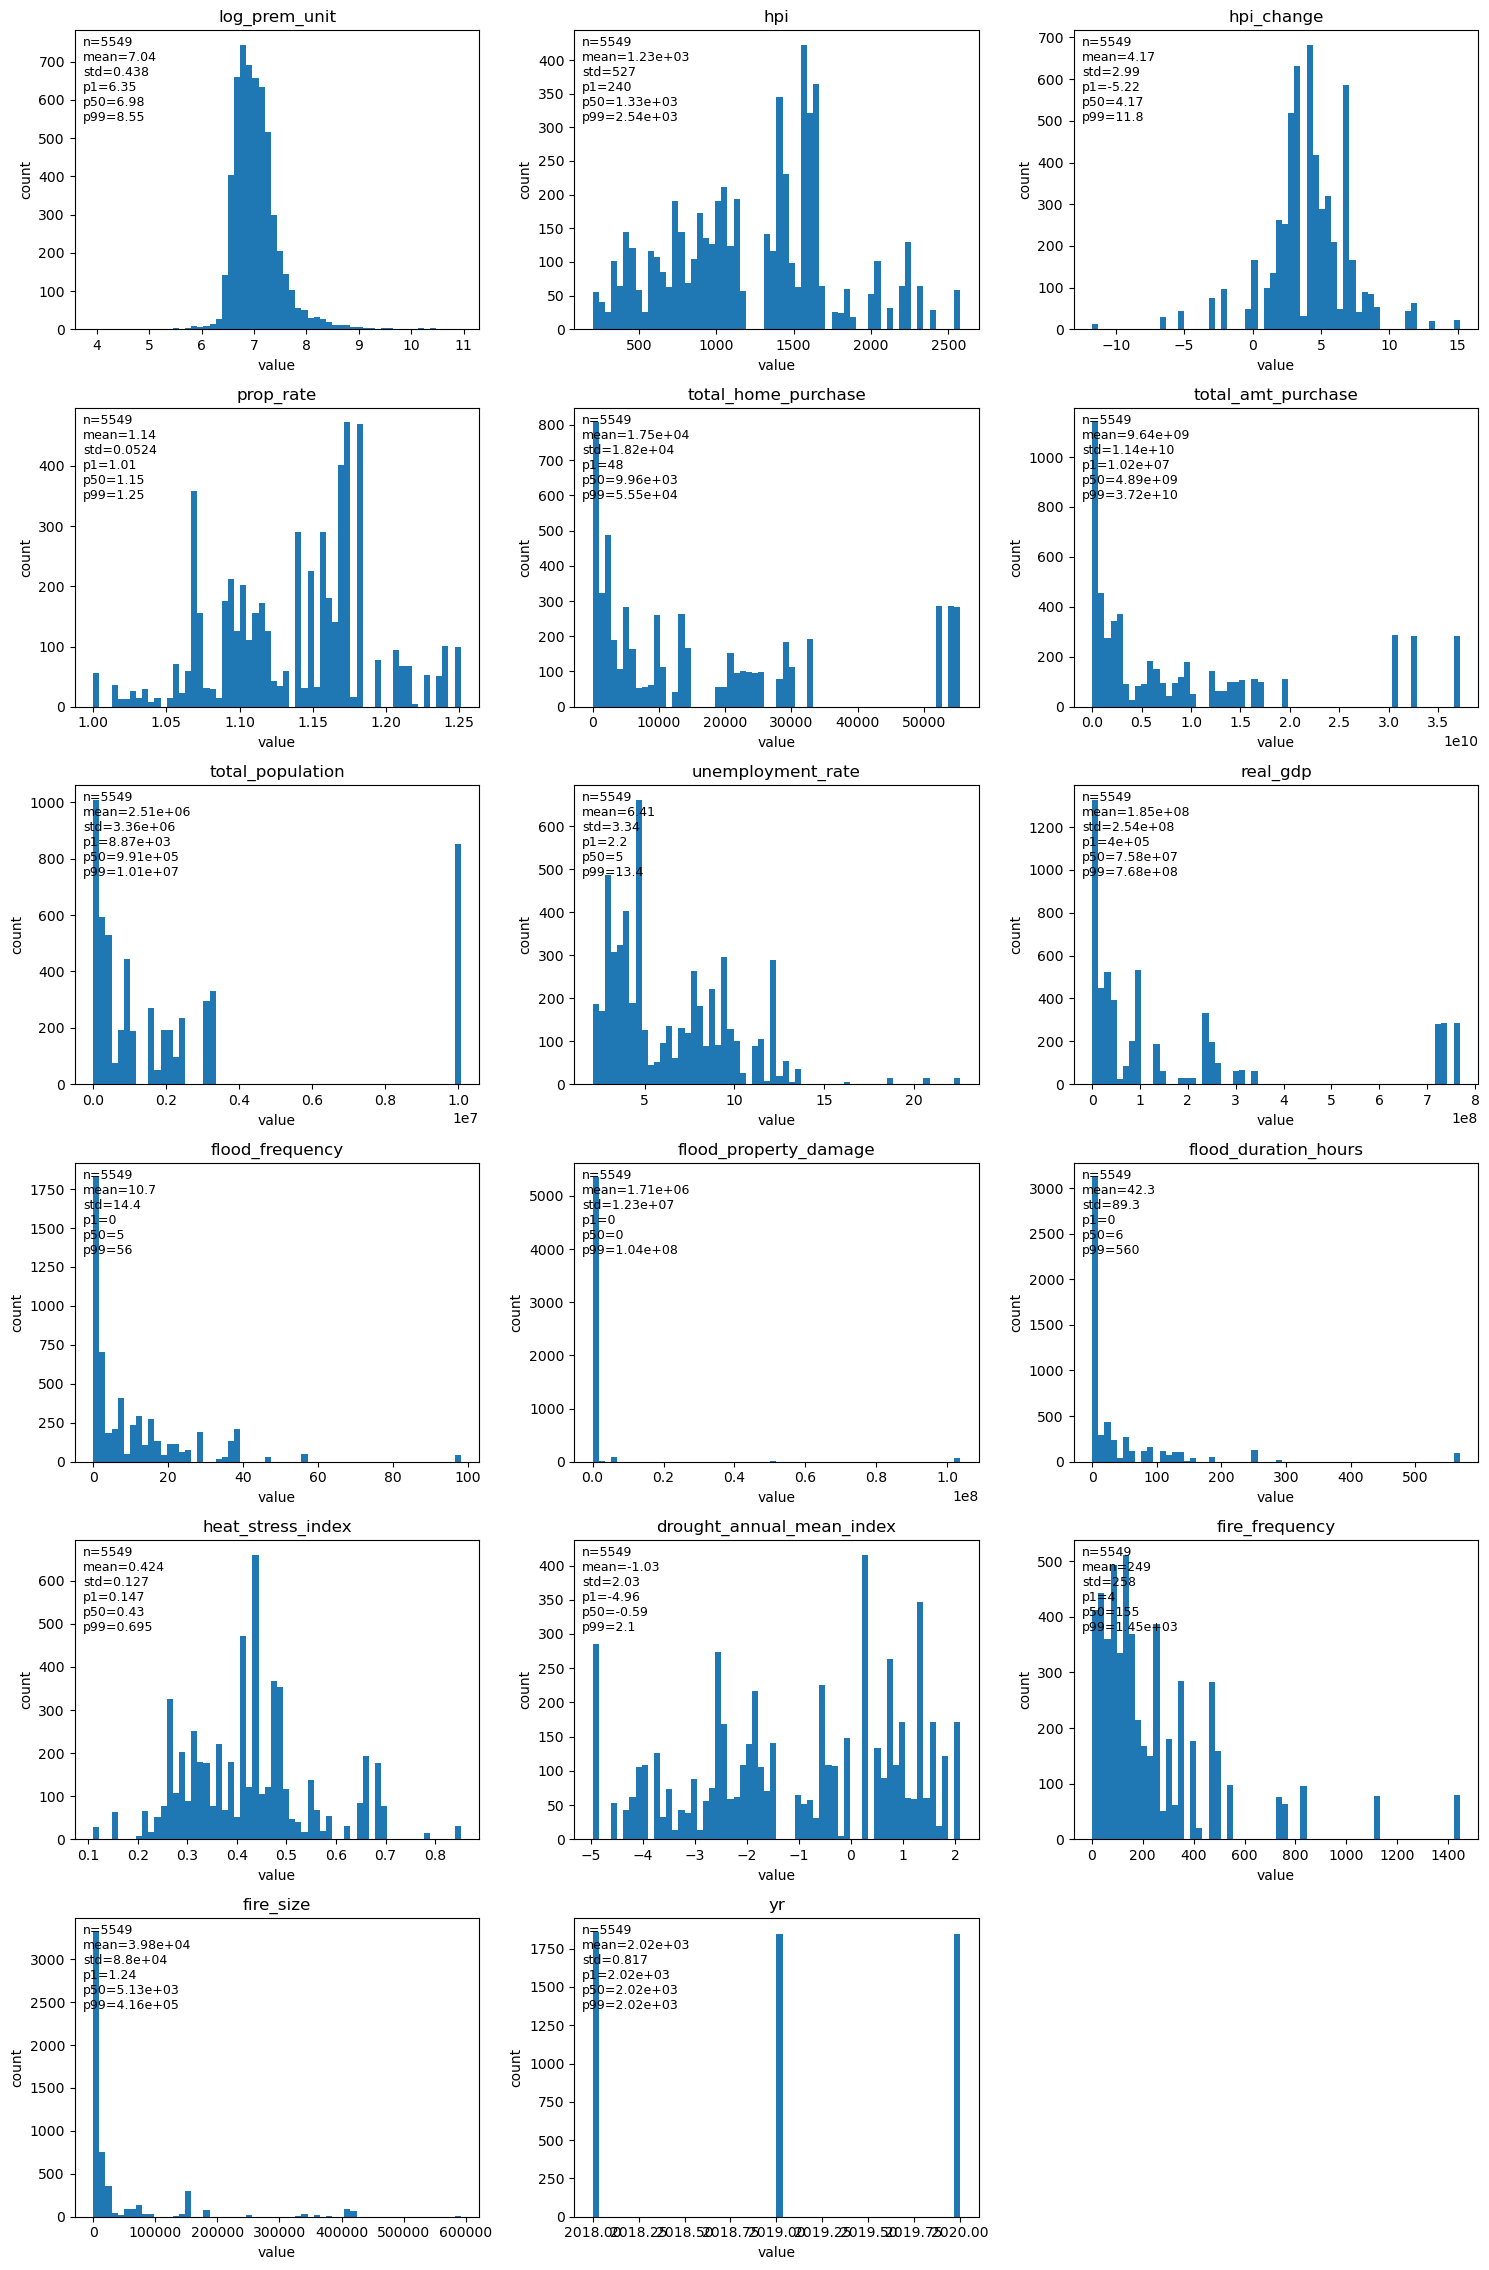

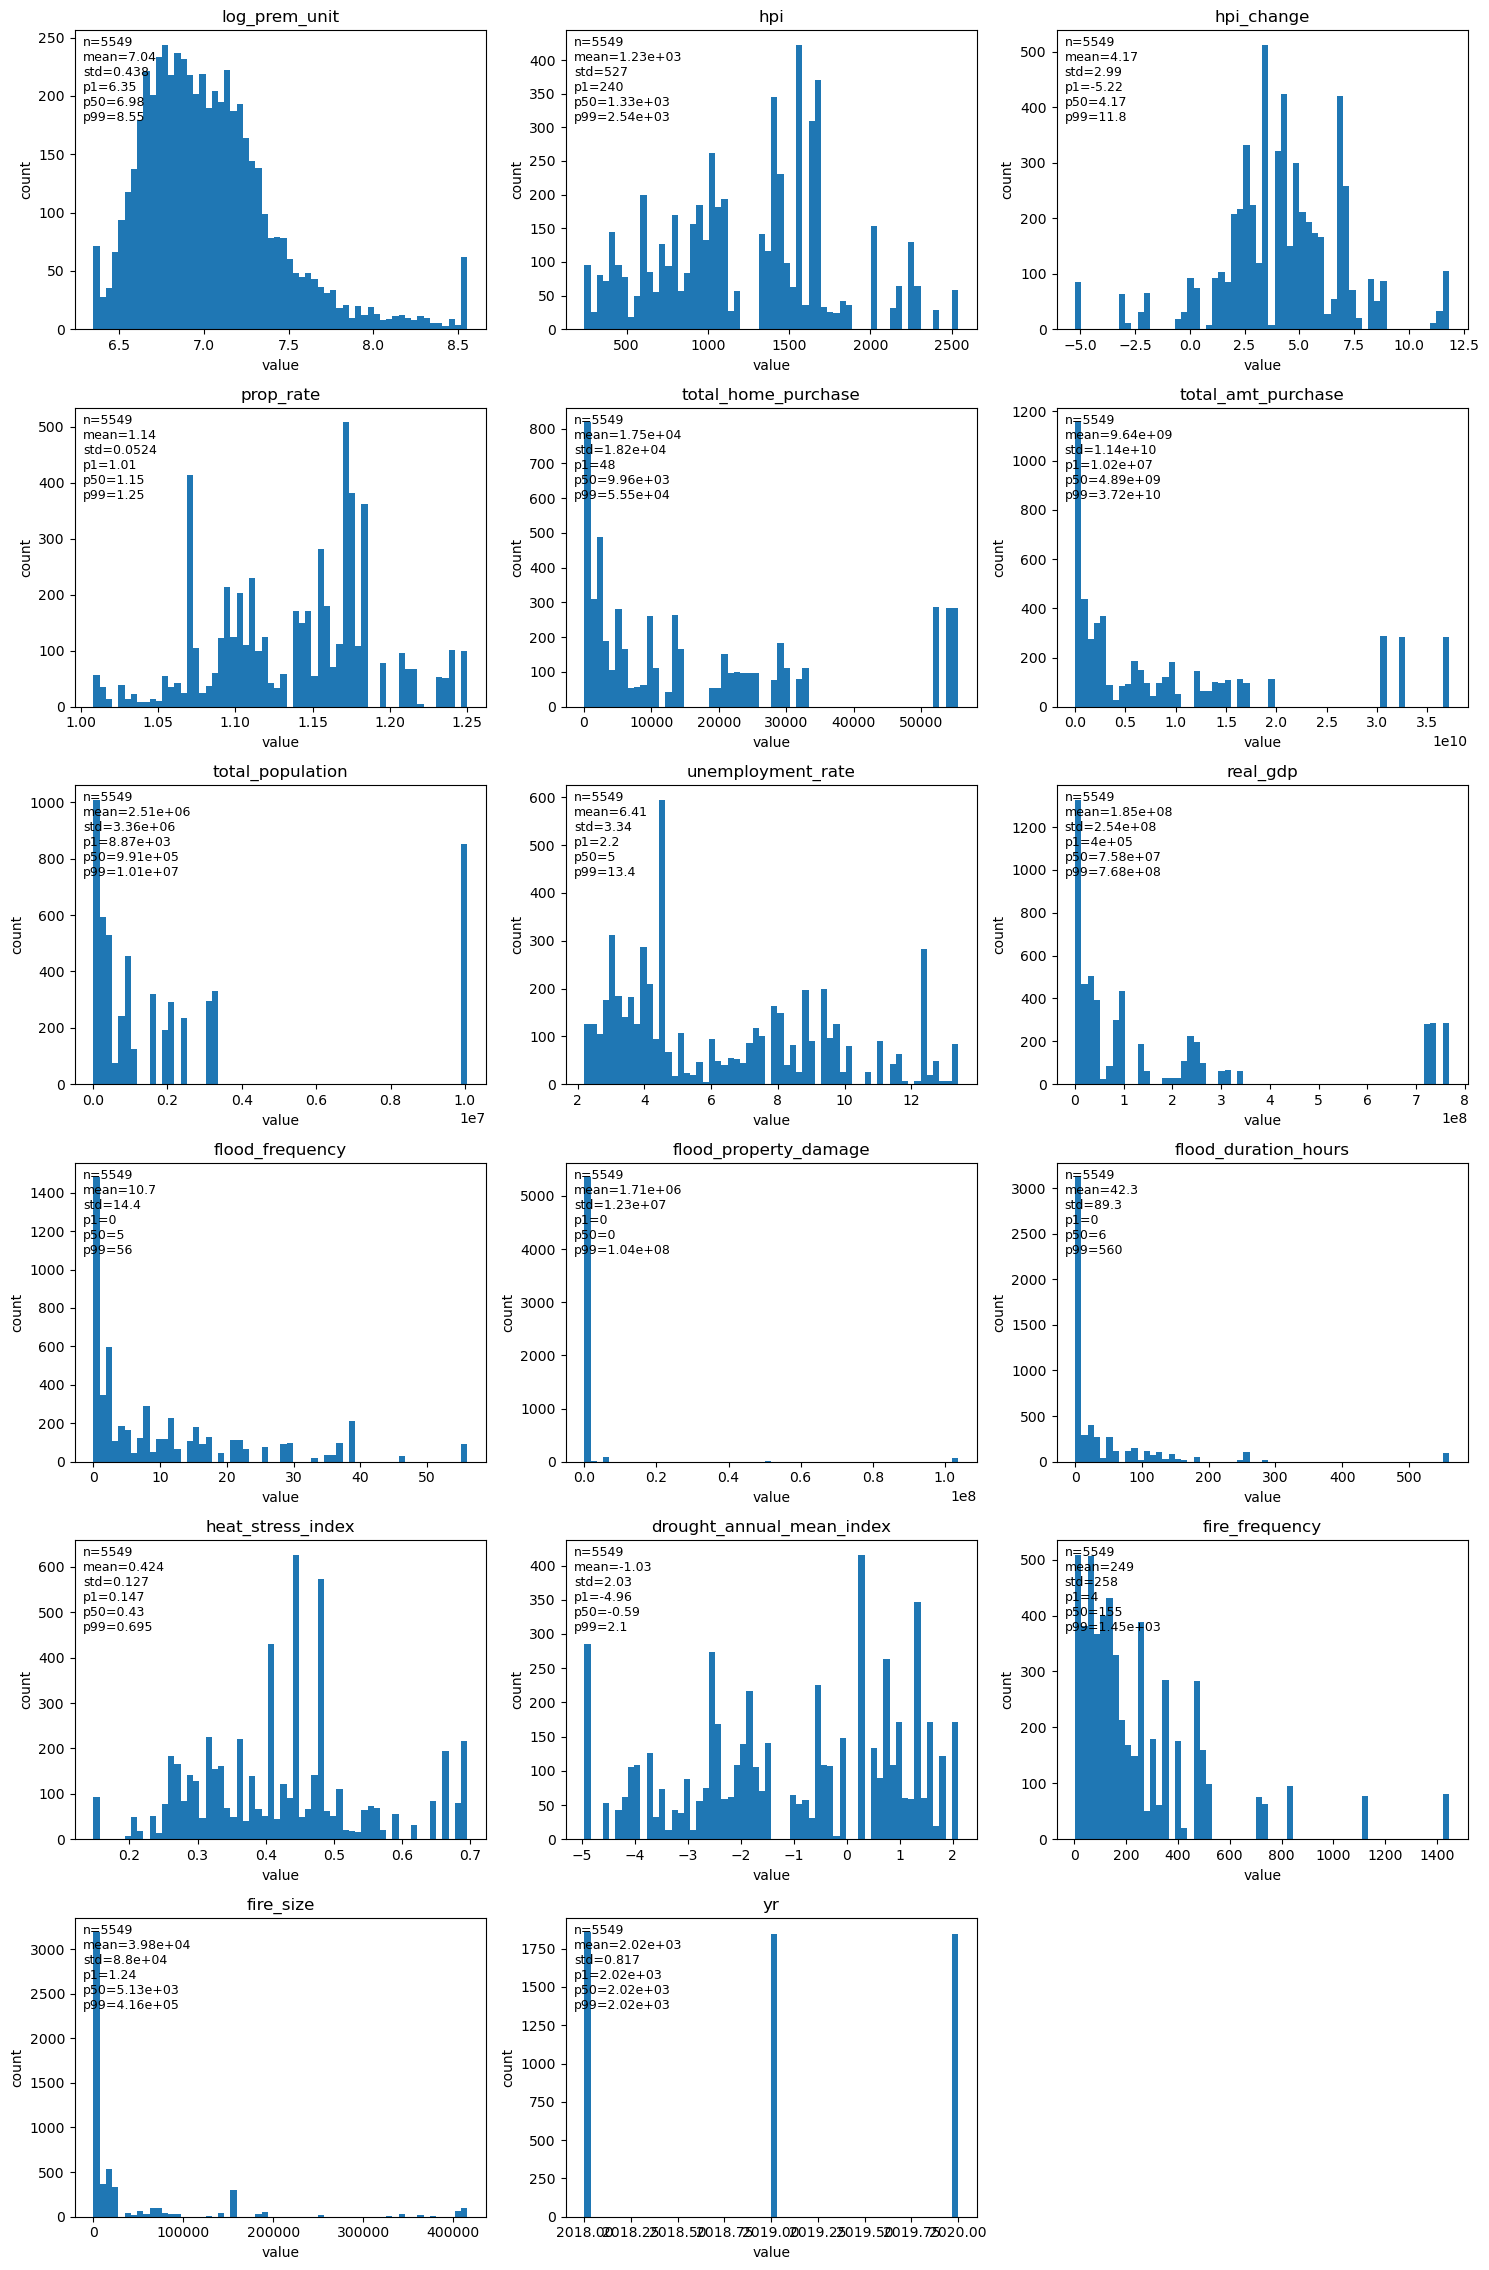

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# =========================
# Make sure df_m exists
# (ZIP-level: use `base` from RF chunk; County-year: use df_m from MLR chunk)
# Here I assume ZIP-level `base` exists and has `log_prem_unit` + features.
# =========================

# --- choose the dataframe to plot ---
plot_df = base.copy()   # <-- ZIP-level
target_col = "log_prem_unit"

# pick feature columns (numeric + categorical if you want)
num_cols = []
for c in plot_df.columns:
    if pd.api.types.is_numeric_dtype(plot_df[c]):
        num_cols.append(c)

# keep only columns you care about (recommended: target + model features)
# If you already have num_features list from RF chunk, use that:
cols_to_plot = [target_col] + [c for c in num_features if c in plot_df.columns]
cols_to_plot = list(dict.fromkeys(cols_to_plot))  # drop duplicates, preserve order

# optional: drop columns that are IDs / not meaningful to histogram
drop_like = {"Earned Prem","Earned Exp","prem_per_unit","county_fips5"}
cols_to_plot = [c for c in cols_to_plot if c in plot_df.columns and c not in drop_like]

# =========================
# Histogram plotting helper
# =========================
def plot_histograms(df, cols, bins=50, max_cols_per_row=3, winsor=(0.0, 1.0), log1p_if_skew=False):
    """
    winsor=(lo_q, hi_q) trims extreme tails for visualization only.
    log1p_if_skew: if True, auto-add a log1p panel for heavily right-skewed vars.
    """
    cols = [c for c in cols if c in df.columns]
    n = len(cols)
    ncols = max_cols_per_row
    nrows = math.ceil(n / ncols)

    plt.figure(figsize=(5*ncols, 3.8*nrows))

    for i, c in enumerate(cols, 1):
        s = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

        # winsorize for display only
        if winsor != (0.0, 1.0) and len(s) > 0:
            lo, hi = s.quantile([winsor[0], winsor[1]])
            s_plot = s.clip(lo, hi)
        else:
            s_plot = s

        ax = plt.subplot(nrows, ncols, i)
        ax.hist(s_plot.values, bins=bins)
        ax.set_title(c)
        ax.set_ylabel("count")
        ax.set_xlabel("value")

        # show quick stats on plot
        if len(s) > 0:
            ax.text(
                0.02, 0.98,
                f"n={len(s)}\nmean={s.mean():.3g}\nstd={s.std():.3g}\n"
                f"p1={s.quantile(0.01):.3g}\np50={s.quantile(0.5):.3g}\np99={s.quantile(0.99):.3g}",
                transform=ax.transAxes,
                va="top",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

# =========================
# 1) Raw histograms (no trimming)
# =========================
plot_histograms(plot_df, cols_to_plot, bins=60, winsor=(0.0, 1.0))

# =========================
# 2) Trimmed histograms for visibility (recommended)
#    (this DOES NOT change your data; just makes plots readable)
# =========================
plot_histograms(plot_df, cols_to_plot, bins=60, winsor=(0.01, 0.99))


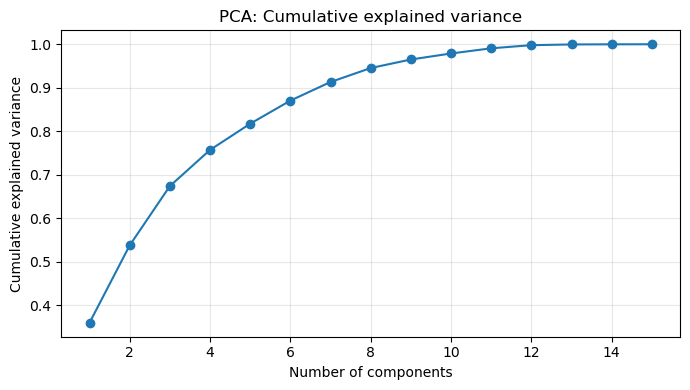

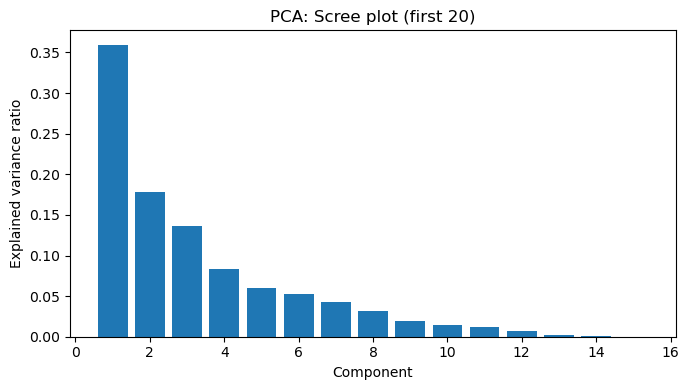

K for 80%: 5  | K for 90%: 7

Top loadings for PC1:
total_home_purchase      0.419200
total_population         0.417361
total_amt_purchase       0.416479
real_gdp                 0.411010
prop_rate                0.303331
fire_frequency           0.264111
hpi                      0.261916
flood_frequency          0.153197
heat_stress_index        0.124981
flood_property_damage    0.115189
Name: PC1, dtype: float64

Top loadings for PC2:
flood_duration_hours         0.534361
flood_property_damage        0.486639
flood_frequency              0.444941
drought_annual_mean_index    0.280333
heat_stress_index            0.265686
hpi                         -0.225934
fire_size                   -0.129724
unemployment_rate           -0.124526
real_gdp                    -0.120413
hpi_change                   0.099323
Name: PC2, dtype: float64

Top loadings for PC3:
fire_size                    0.463112
hpi                         -0.422303
fire_frequency               0.410934
unemployment_rat

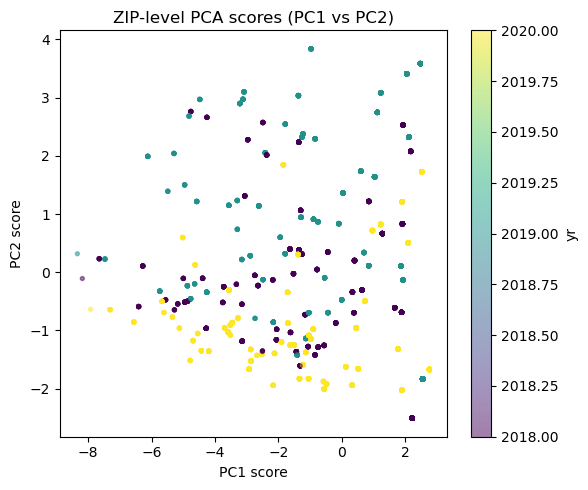


PC score df shape: (5549, 7)


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# -----------------------------
# Choose your ZIP-level dataframe
# -----------------------------
dfp = base.copy()   # base from your RF chunk (ZIP-level), includes target and predictors

# -----------------------------
# Define predictor sets
# -----------------------------
# numeric predictors you want PCA on (exclude target)
pca_features = [
    "hpi","hpi_change","prop_rate",
    "total_home_purchase","total_amt_purchase","total_population",
    "unemployment_rate","real_gdp",
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size"
]
pca_features = [c for c in pca_features if c in dfp.columns]

# ensure numeric
for c in pca_features:
    dfp[c] = pd.to_numeric(dfp[c], errors="coerce")

# -----------------------------
# Transform skewed vars (log1p) before PCA
# -----------------------------
skewed = [c for c in [
    "total_home_purchase","total_amt_purchase","total_population","real_gdp",
    "flood_property_damage","flood_duration_hours","fire_size",
    "flood_frequency","fire_frequency"
] if c in dfp.columns]

dfp_pca = dfp[pca_features].copy()
for c in skewed:
    dfp_pca[c] = np.log1p(dfp_pca[c])

# -----------------------------
# Impute + standardize + PCA
# -----------------------------
X = dfp_pca.copy()

# simple impute then scale
imp = SimpleImputer(strategy="median")
scaler = StandardScaler(with_mean=True, with_std=True)

X_imp = imp.fit_transform(X)
X_scaled = scaler.fit_transform(X_imp)

pca = PCA()
Z = pca.fit_transform(X_scaled)   # principal component scores

# -----------------------------
# Explained variance plots
# -----------------------------
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(evr)+1), cum, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA: Cumulative explained variance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.bar(range(1, min(20, len(evr))+1), evr[:min(20, len(evr))])
plt.xlabel("Component")
plt.ylabel("Explained variance ratio")
plt.title("PCA: Scree plot (first 20)")
plt.tight_layout()
plt.show()

# pick K (e.g. 80% or 90% variance)
K_80 = int(np.argmax(cum >= 0.80) + 1)
K_90 = int(np.argmax(cum >= 0.90) + 1)
print("K for 80%:", K_80, " | K for 90%:", K_90)

# -----------------------------
# Loadings (feature contributions)
# -----------------------------
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=[f"PC{i+1}" for i in range(len(pca_features))]
)

# show top absolute loadings for first few PCs
def top_loadings(pc, n=8):
    s = loadings[pc].sort_values(key=lambda x: np.abs(x), ascending=False)
    return s.head(n)

for pc in ["PC1","PC2","PC3","PC4"]:
    if pc in loadings.columns:
        print(f"\nTop loadings for {pc}:")
        print(top_loadings(pc, n=10))

# -----------------------------
# 2D PCA score plot colored by year (if available)
# -----------------------------
if "yr" in dfp.columns:
    yr = pd.to_numeric(dfp["yr"], errors="coerce")
else:
    yr = None

plt.figure(figsize=(6,5))
if yr is not None:
    sc = plt.scatter(Z[:,0], Z[:,1], c=yr, s=8, alpha=0.5)
    plt.colorbar(sc, label="yr")
else:
    plt.scatter(Z[:,0], Z[:,1], s=8, alpha=0.5)
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.title("ZIP-level PCA scores (PC1 vs PC2)")
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: make a dataframe of PC scores (for regression)
# -----------------------------
K = K_90  # or choose manually
pc_scores = pd.DataFrame(Z[:, :K], columns=[f"PC{i+1}" for i in range(K)], index=dfp.index)
print("\nPC score df shape:", pc_scores.shape)


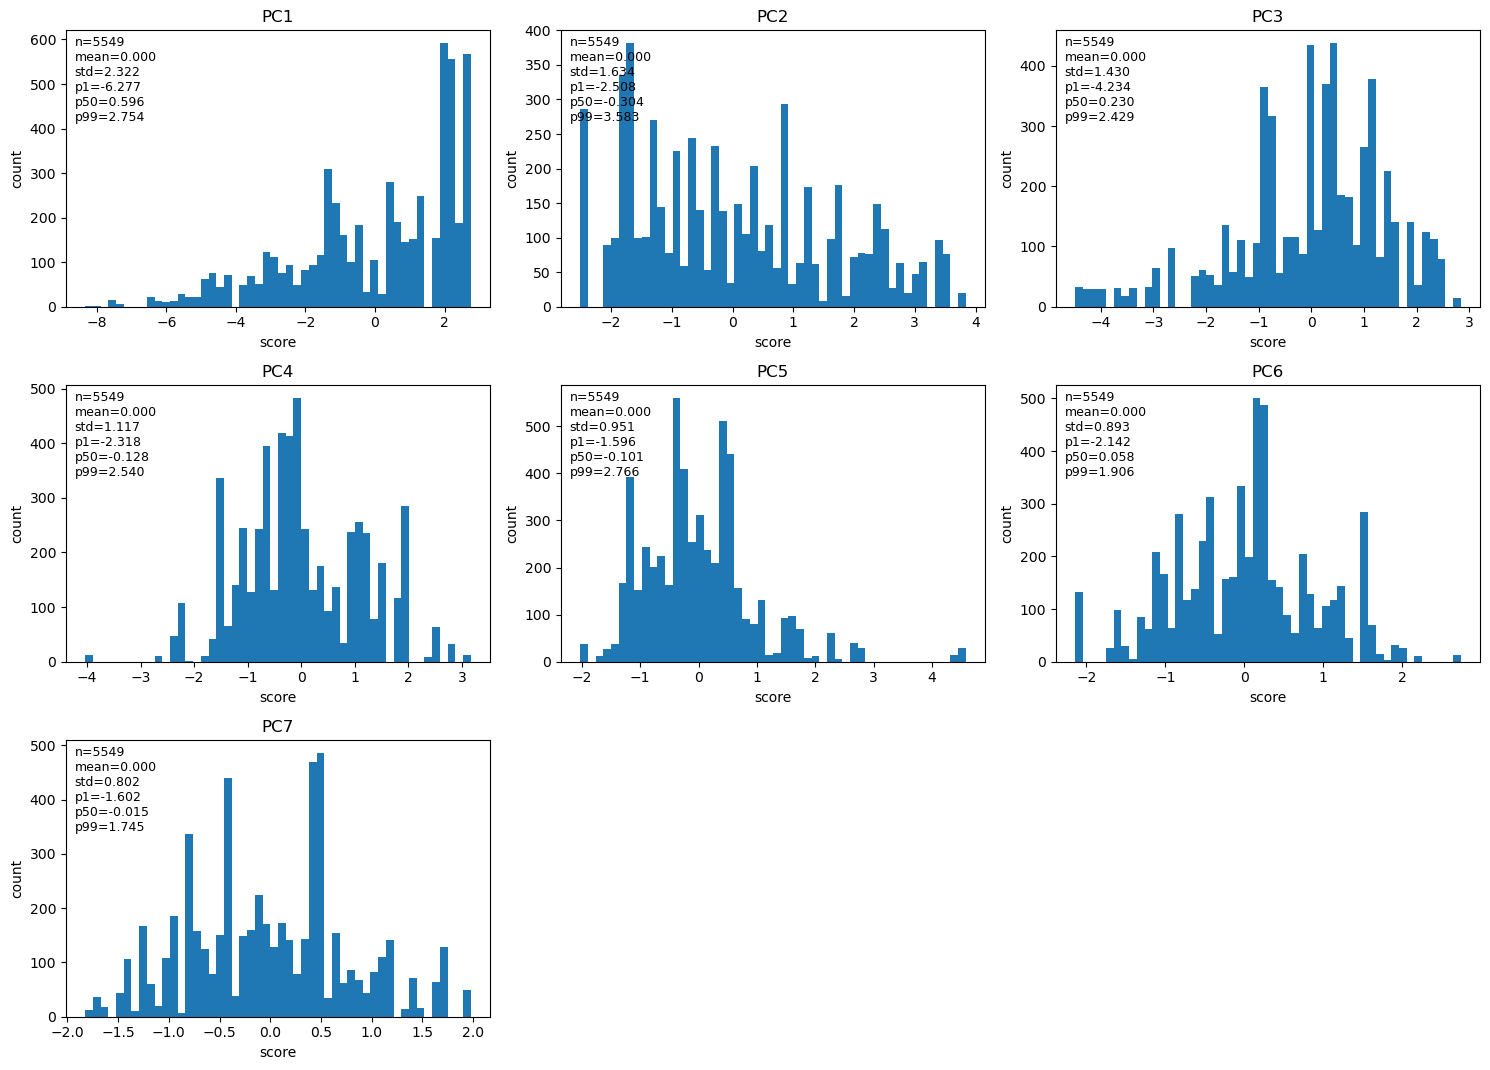

In [72]:
import math
import matplotlib.pyplot as plt

# -----------------------------
# Histograms for PC scores
# -----------------------------
K_plot = min(10, pc_scores.shape[1])  # plot first 10 PCs (or fewer if K<10)
cols = [f"PC{i+1}" for i in range(K_plot)]

ncols = 3
nrows = math.ceil(K_plot / ncols)

plt.figure(figsize=(5*ncols, 3.6*nrows))

for i, c in enumerate(cols, 1):
    s = pc_scores[c].replace([np.inf, -np.inf], np.nan).dropna()

    ax = plt.subplot(nrows, ncols, i)
    ax.hist(s.values, bins=50)
    ax.set_title(c)
    ax.set_xlabel("score")
    ax.set_ylabel("count")

    # quick stats (PC scores should be ~mean 0, sd ~sqrt(eigenvalue); after StandardScaler, typically close to 1-ish)
    ax.text(
        0.02, 0.98,
        f"n={len(s)}\nmean={s.mean():.3f}\nstd={s.std():.3f}\n"
        f"p1={s.quantile(0.01):.3f}\np50={s.quantile(0.5):.3f}\np99={s.quantile(0.99):.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9
    )

plt.tight_layout()
plt.show()


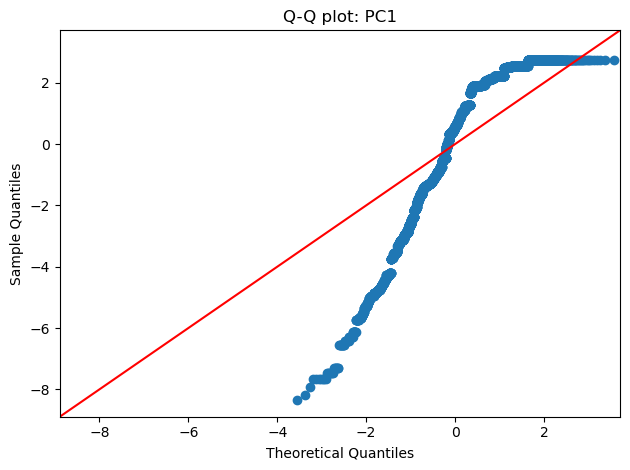

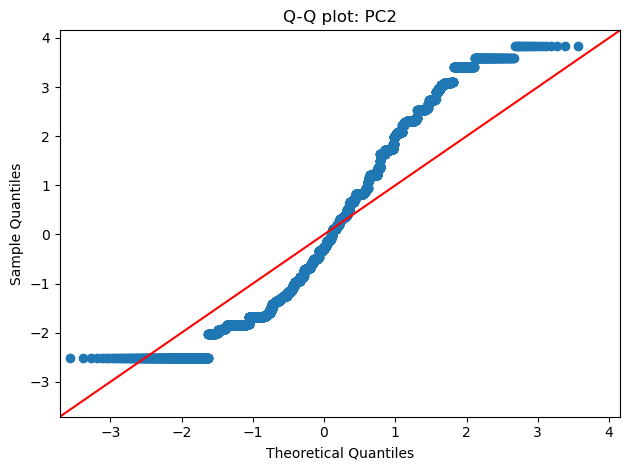

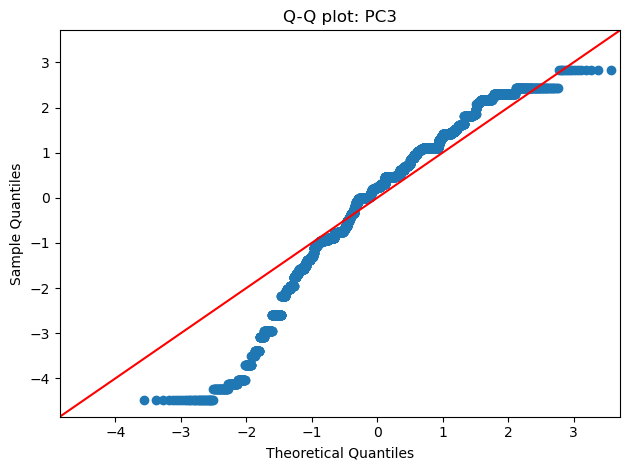

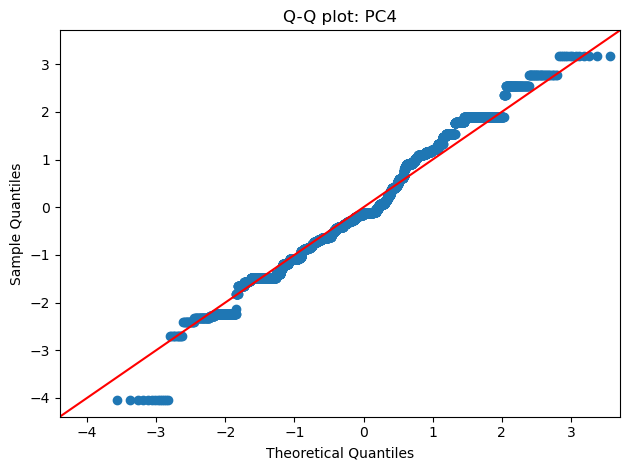

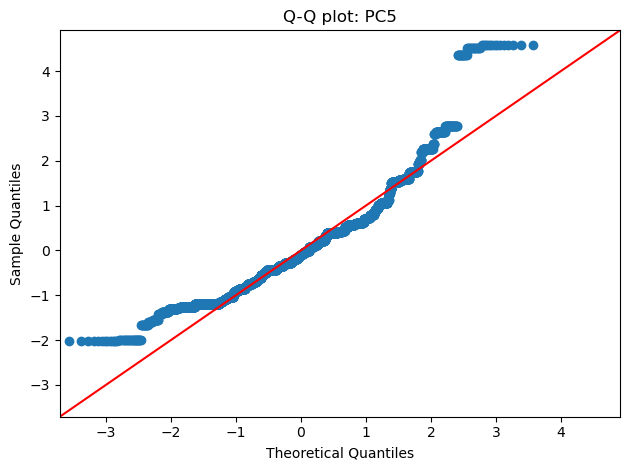

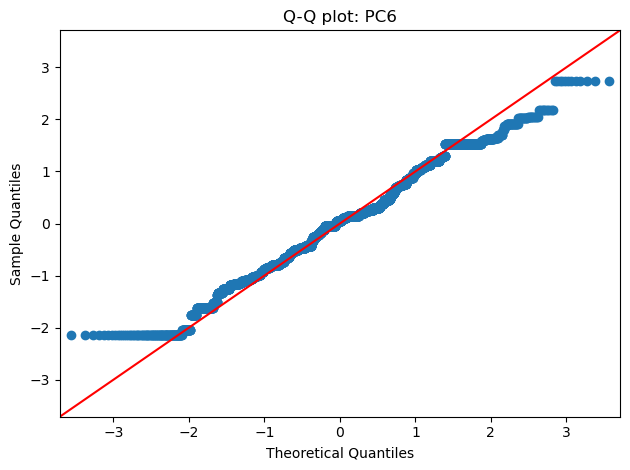

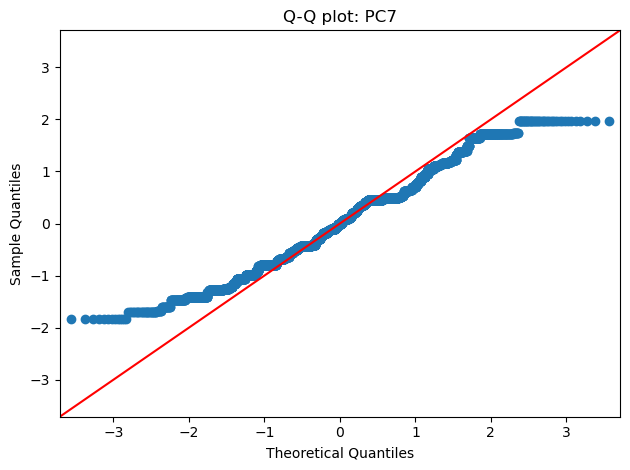

In [74]:
import statsmodels.api as sm

for c in cols:
    sm.qqplot(pc_scores[c].dropna(), line="45")
    plt.title(f"Q-Q plot: {c}")
    plt.tight_layout()
    plt.show()


In [76]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

# -----------------------------
# 1) Build annual exposure-weighted average prem_per_unit
# -----------------------------
d = df.copy()
d["yr"] = pd.to_numeric(d["yr"], errors="coerce")
d["Earned Prem"] = pd.to_numeric(d.get("Earned Prem"), errors="coerce")
d["Earned Exp"]  = pd.to_numeric(d.get("Earned Exp"), errors="coerce")
d = d.dropna(subset=["yr","Earned Prem","Earned Exp"]).copy()
d = d[d["Earned Exp"] > 0].copy()

annual = d.groupby("yr", as_index=False).agg({"Earned Prem":"sum","Earned Exp":"sum"})
annual["avg_ppu"] = annual["Earned Prem"] / annual["Earned Exp"]
annual = annual.replace([np.inf, -np.inf], np.nan).dropna(subset=["avg_ppu"])
annual = annual.sort_values("yr")

y = np.log(annual["avg_ppu"].values)
years = annual["yr"].values.astype(int)
T = len(y)

print(annual[["yr","avg_ppu"]])

# how many steps to forecast
H = 3  # 2021, 2022, 2023 relative to last observed year
y_obs = y

# -----------------------------
# 2) Bayesian local linear trend model (robust obs via Student-t)
# -----------------------------
with pm.Model() as m:
    # priors
    nu = pm.Exponential("nu_minus2", lam=1/10) + 2  # df > 2
    sigma = pm.HalfNormal("sigma", 0.5)

    sigma_level = pm.HalfNormal("sigma_level", 0.2)
    sigma_slope = pm.HalfNormal("sigma_slope", 0.1)

    # initial states
    level0 = pm.Normal("level0", mu=y_obs[0], sigma=1.0)
    slope0 = pm.Normal("slope0", mu=0.0, sigma=0.2)

    # innovations
    level_eps = pm.Normal("level_eps", 0.0, 1.0, shape=T+H-1)
    slope_eps = pm.Normal("slope_eps", 0.0, 1.0, shape=T+H-1)

    level = pm.Deterministic("level", pm.math.concatenate([
        level0[None],
        pm.math.zeros(T+H-1)
    ]))
    slope = pm.Deterministic("slope", pm.math.concatenate([
        slope0[None],
        pm.math.zeros(T+H-1)
    ]))

    # build state recursion
    level_list = [level0]
    slope_list = [slope0]
    for t in range(1, T+H):
        new_level = level_list[t-1] + slope_list[t-1] + sigma_level * level_eps[t-1]
        new_slope = slope_list[t-1] + sigma_slope * slope_eps[t-1]
        level_list.append(new_level)
        slope_list.append(new_slope)

    level_latent = pm.Deterministic("level_latent", pm.math.stack(level_list))
    mu = level_latent  # observation mean in log space

    # observed years likelihood
    pm.StudentT("y_obs", nu=nu, mu=mu[:T], sigma=sigma, observed=y_obs)

    # sample
    idata = pm.sample(
        draws=2000, tune=2000,
        chains=4, target_accept=0.9,
        random_seed=42
    )

# -----------------------------
# 3) Posterior predictive for 2021–2023 (log space -> level space)
# -----------------------------
mu_post = idata.posterior["level_latent"].stack(sample=("chain","draw")).values  # (T+H, samples)

# forecast indices: T, T+1, T+2 correspond to next 3 years
log_fore = mu_post[T:T+H, :]  # (H, samples)
ppu_fore = np.exp(log_fore)   # back to prem_per_unit

# summarize
future_years = np.arange(years.max()+1, years.max()+H+1)

summ = []
for i, yr in enumerate(future_years):
    vals = ppu_fore[i, :]
    summ.append({
        "yr": int(yr),
        "mean": float(np.mean(vals)),
        "p10": float(np.quantile(vals, 0.10)),
        "p50": float(np.quantile(vals, 0.50)),
        "p90": float(np.quantile(vals, 0.90)),
    })

forecast_df = pd.DataFrame(summ)
print("\nForecast avg prem_per_unit:")
print(forecast_df)


     yr      avg_ppu
0  2018  1050.301427
1  2019  1119.561223
2  2020  1244.704950


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [nu_minus2, sigma, sigma_level, sigma_slope, level0, slope0, level_eps, slope_eps]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 15 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Forecast avg prem_per_unit:
     yr         mean         p10          p50          p90
0  2021  1377.986853  879.979175  1328.904341  1903.897999
1  2022  1560.569244  774.303906  1408.039142  2388.360077
2  2023  1857.737291  672.140684  1523.051140  3086.271726


In [88]:
import pandas as pd
import numpy as np
from pathlib import Path

processed_dir = Path.home() / "Documents/duke_mss/stat_698/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data"
xlsx_path = processed_dir / "Residential-Property-Coverage-Amounts-Wildfire-Risk-and-Losses_Export.xlsx"

def read_export_sheet(sheet):
    # read raw with no header so we can grab the real header row
    raw = pd.read_excel(xlsx_path, sheet_name=sheet, header=None)

    # the first non-empty row usually contains headers like:
    # Source, Calendar Year, Policy Type, ZIP Code, ..., Earned Prem, Earned Exp
    # We'll find the row that contains "Earned Prem" and "Earned Exp"
    header_row = None
    for i in range(min(30, len(raw))):
        row_vals = raw.iloc[i].astype(str).str.lower().tolist()
        if any("earned prem" in v for v in row_vals) and any("earned exp" in v for v in row_vals):
            header_row = i
            break

    if header_row is None:
        raise ValueError(f"Could not find header row in {sheet}. Try increasing search window.")

    headers = raw.iloc[header_row].tolist()
    df = raw.iloc[header_row+1:].copy()
    df.columns = headers

    # drop fully empty cols
    df = df.dropna(axis=1, how="all")

    return df

# quick test
df21 = read_export_sheet("Export_21")
print(df21.columns.tolist())
df21.head()


['Source', 'Calendar Year', 'Policy Type', 'ZIP Code', 'Avg Cov A  ', 'Avg Cov C  ', 'Earned Prem', 'Earned Exp', 'NonCat CovA Fire Losses', 'NonCat CovA Fire Count', 'NonCat CovA Smoke Losses', 'NonCat Cov A Smoke Count', 'NonCat CovC Fire Losses', 'NonCat CovC Fire Count', 'NonCat CovC Smoke Losses', 'NonCat CovC Smoke Count', 'Cat CovA Fire Losses', 'Cat CovA Fire Count', 'Cat CovA Smoke Losses', 'Cat CovA Smoke Count', 'Cat CovC Fire Losses', 'Cat CovC Fire Count', 'Cat CovC Smoke Losses', 'Cat CovC Smoke Count', 'County']


,Source,Calendar Year,Policy Type,ZIP Code,Avg Cov A,Avg Cov C,Earned Prem,Earned Exp,NonCat CovA Fire Losses,NonCat CovA Fire Count,...,NonCat CovC Smoke Count,Cat CovA Fire Losses,Cat CovA Fire Count,Cat CovA Smoke Losses,Cat CovA Smoke Count,Cat CovC Fire Losses,Cat CovC Fire Count,Cat CovC Smoke Losses,Cat CovC Smoke Count,County
3,All Companies,21,DO,90001,261326.26,21533.13,665340,2216,18270,1,...,0,0,0,4622,2,0,0,0,0,Los Angeles
4,All Companies,21,DT,90001,257020.41,6220.57,1689308,3293,172884,3,...,0,211321,1,0,0,0,0,0,0,Los Angeles
5,All Companies,21,HO,90001,275921.48,178091.91,1629265,1976,104222,3,...,1,0,0,0,0,0,0,0,0,Los Angeles
6,All Companies,21,MH,90001,269236,25000,249,1,0,0,...,0,0,0,0,0,0,0,0,0,Los Angeles
7,All Companies,21,RT,90001,874.42,18825.52,126310,945,0,0,...,0,0,0,0,0,0,0,0,0,Los Angeles


In [90]:
def get_avg_ppu_for_year(sheet, year):
    d = read_export_sheet(sheet).copy()

    # normalize col names (strip)
    d.columns = [str(c).strip() for c in d.columns]

    # expected columns from your screenshot
    # (if one is slightly different, print d.columns and adjust)
    prem_col = "Earned Prem"
    exp_col  = "Earned Exp"

    # convert
    d[prem_col] = pd.to_numeric(d[prem_col], errors="coerce")
    d[exp_col]  = pd.to_numeric(d[exp_col], errors="coerce")

    d = d.dropna(subset=[prem_col, exp_col]).copy()
    d = d[d[exp_col] > 0].copy()

    avg_ppu = d[prem_col].sum() / d[exp_col].sum()
    return avg_ppu, d[prem_col].sum(), d[exp_col].sum(), len(d)

results = []
for yr in [2021, 2022, 2023]:
    sheet = f"Export_{str(yr)[-2:]}"  # Export_21, Export_22, Export_23
    avg_ppu, prem_sum, exp_sum, n = get_avg_ppu_for_year(sheet, yr)
    results.append({"yr": yr, "avg_prem_per_unit": avg_ppu, "prem_sum": prem_sum, "exp_sum": exp_sum, "n_rows": n})

actual_df = pd.DataFrame(results)
print(actual_df)


     yr  avg_prem_per_unit     prem_sum   exp_sum  n_rows
0  2021         933.612247  11410905773  12222318   11773
1  2022        1027.301081  12804187183  12463909   11773
2  2023        1130.055503  14217194377  12580970   11760


In [92]:
compare = actual_df.merge(forecast_df, on="yr", how="left")

compare["err_mean"] = compare["avg_prem_per_unit"] - compare["mean"]
compare["pct_err_mean"] = compare["err_mean"] / compare["avg_prem_per_unit"]

if set(["p10","p90"]).issubset(compare.columns):
    compare["inside_80_PI"] = (compare["avg_prem_per_unit"] >= compare["p10"]) & (compare["avg_prem_per_unit"] <= compare["p90"])

print(compare)


     yr  avg_prem_per_unit     prem_sum   exp_sum  n_rows         mean  \
0  2021         933.612247  11410905773  12222318   11773  1377.986853   
1  2022        1027.301081  12804187183  12463909   11773  1560.569244   
2  2023        1130.055503  14217194377  12580970   11760  1857.737291   

          p10          p50          p90    err_mean  pct_err_mean  \
0  879.979175  1328.904341  1903.897999 -444.374606     -0.475973   
1  774.303906  1408.039142  2388.360077 -533.268163     -0.519096   
2  672.140684  1523.051140  3086.271726 -727.681789     -0.643935   

   inside_80_PI  
0          True  
1          True  
2          True  


In [98]:
import numpy as np
import pandas as pd
from pathlib import Path

processed_dir = Path.home() / "Documents/duke_mss/stat_698/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data"
xlsx_path = processed_dir / "Residential-Property-Coverage-Amounts-Wildfire-Risk-and-Losses_Export.xlsx"

def read_export_sheet(sheet):
    raw = pd.read_excel(xlsx_path, sheet_name=sheet, header=None)

    header_row = None
    for i in range(min(50, len(raw))):
        row_vals = raw.iloc[i].astype(str).str.lower().tolist()
        if any("earned prem" in v for v in row_vals) and any("earned exp" in v for v in row_vals):
            header_row = i
            break
    if header_row is None:
        raise ValueError(f"Could not find header row in {sheet}")

    headers = [str(x).strip() for x in raw.iloc[header_row].tolist()]
    df = raw.iloc[header_row+1:].copy()
    df.columns = headers
    df = df.dropna(axis=1, how="all")
    return df

def zip_year_from_sheet(sheet, year):
    d = read_export_sheet(sheet).copy()
    d.columns = [str(c).strip() for c in d.columns]

    zip_col  = "ZIP Code"
    prem_col = "Earned Prem"
    exp_col  = "Earned Exp"

    # Optional: keep only All Companies
    if "Source" in d.columns:
        d = d[d["Source"].astype(str).str.strip().eq("All Companies")].copy()

    d[zip_col]  = pd.to_numeric(d[zip_col], errors="coerce")
    d[prem_col] = pd.to_numeric(d[prem_col], errors="coerce")
    d[exp_col]  = pd.to_numeric(d[exp_col], errors="coerce")

    d = d.dropna(subset=[zip_col, prem_col, exp_col]).copy()
    d = d[d[exp_col] > 0].copy()

    # Aggregate across policy types etc. => one row per ZIP-year
    out = d.groupby(zip_col, as_index=False).agg({prem_col:"sum", exp_col:"sum"})
    out = out.rename(columns={zip_col: "zip", prem_col: "earned_prem", exp_col: "earned_exp"})
    out["yr"] = year
    out["prem_per_unit"] = out["earned_prem"] / out["earned_exp"]
    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=["prem_per_unit"])
    out = out[out["prem_per_unit"] > 0].copy()
    out["log_ppu"] = np.log(out["prem_per_unit"])
    return out[["zip","yr","earned_prem","earned_exp","prem_per_unit","log_ppu"]]

# Build full panel 2018-2023
panel_list = []
for yy in [2018,2019,2020,2021,2022,2023]:
    sheet = f"Export_{str(yy)[-2:]}"
    panel_list.append(zip_year_from_sheet(sheet, yy))

panel = pd.concat(panel_list, ignore_index=True)
print("Panel rows:", panel.shape)
print(panel.head())
print("Years:", sorted(panel["yr"].unique()))
print("Unique ZIPs:", panel["zip"].nunique())


Panel rows: (12934, 6)
     zip    yr  earned_prem  earned_exp  prem_per_unit   log_ppu
0  90001  2018      3394309        8354     406.309433  6.007115
1  90002  2018      3419883        7685     445.007547  6.098091
2  90003  2018      4500963        9884     455.378693  6.121129
3  90004  2018      8431854        9273     909.290844  6.812665
4  90005  2018      2831634        4610     614.237310  6.420381
Years: [2018, 2019, 2020, 2021, 2022, 2023]
Unique ZIPs: 2437


In [100]:
import pymc as pm
import arviz as az

train_years = [2018, 2019, 2020]
test_years  = [2021, 2022, 2023]

train = panel[panel["yr"].isin(train_years)].copy()
test  = panel[panel["yr"].isin(test_years)].copy()

# Use only ZIPs that appear in training (so we can estimate u_zip)
known_zips = set(train["zip"].unique())
test = test[test["zip"].isin(known_zips)].copy()

# ZIP index
zip_ids = np.sort(train["zip"].unique())
zip_to_idx = {z:i for i,z in enumerate(zip_ids)}

# year index (train + future)
all_years = np.array(train_years + test_years)
year_to_idx = {y:i for i,y in enumerate(all_years)}

train["zip_idx"] = train["zip"].map(zip_to_idx).astype(int)
train["year_idx"] = train["yr"].map(year_to_idx).astype(int)

# We’ll predict for EVERY (zip, future_year) combination that exists in test actuals
test["zip_idx"] = test["zip"].map(zip_to_idx).astype(int)
test["year_idx"] = test["yr"].map(year_to_idx).astype(int)

y_obs = train["log_ppu"].values
zip_idx = train["zip_idx"].values
year_idx = train["year_idx"].values

n_zip = len(zip_ids)
T = len(all_years)  # 6 years (18-23)

with pm.Model() as m:
    # robust likelihood df
    nu = pm.Exponential("nu_minus2", 1/10) + 2

    # global intercept
    alpha = pm.Normal("alpha", mu=y_obs.mean(), sigma=1.0)

    # ZIP random intercepts
    sigma_zip = pm.HalfNormal("sigma_zip", 0.5)
    u_zip = pm.Normal("u_zip", mu=0.0, sigma=sigma_zip, shape=n_zip)

    # Year random walk (set gamma_2018 = 0 for identifiability)
    sigma_year = pm.HalfNormal("sigma_year", 0.2)
    eps = pm.Normal("eps", 0.0, 1.0, shape=T-1)
    gamma = pm.Deterministic("gamma", pm.math.concatenate([[0.0], pm.math.cumsum(eps * sigma_year)]))

    # obs noise
    sigma = pm.HalfNormal("sigma", 0.5)

    mu = alpha + u_zip[zip_idx] + gamma[year_idx]

    pm.StudentT("y", nu=nu, mu=mu, sigma=sigma, observed=y_obs)

    idata = pm.sample(
        draws=2000, tune=2000, chains=4,
        target_accept=0.9, random_seed=42
    )

az.summary(idata, var_names=["alpha","sigma","sigma_zip","sigma_year","nu_minus2"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [nu_minus2, alpha, sigma_zip, u_zip, sigma_year, eps, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 700 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,6.455,0.014,6.425,6.478,0.006,0.003,6.0,13.0,1.74
sigma,0.024,0.000,0.023,0.025,0.000,0.000,2939.0,5211.0,1.00
sigma_zip,0.680,0.011,0.659,0.700,0.001,0.000,121.0,3006.0,1.02
sigma_year,0.134,0.068,0.038,0.269,0.002,0.002,1452.0,1300.0,1.00
nu_minus2,0.002,0.002,0.000,0.005,0.000,0.000,3999.0,1433.0,1.00


ZIP-level MSE (2021-2023 pooled): 1482835.9634257678

MSE by year:
 yr
2021    9.997711e+05
2022    2.943267e+06
2023    4.971514e+05
Name: sq_err, dtype: float64


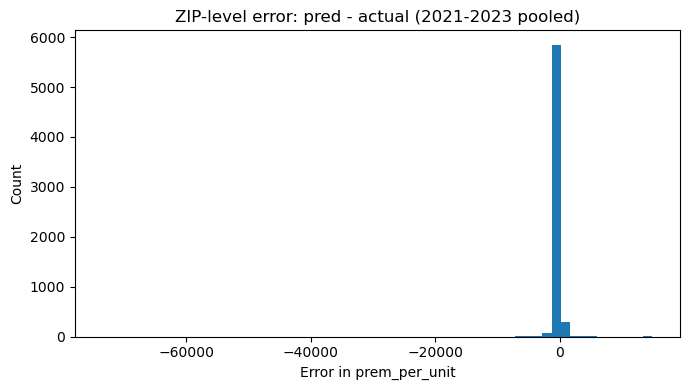

/var/folders/26/4y4fzxhd7td390hxfyvrnw1m0000gp/T/ipykernel_40070/1235233511.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=years)


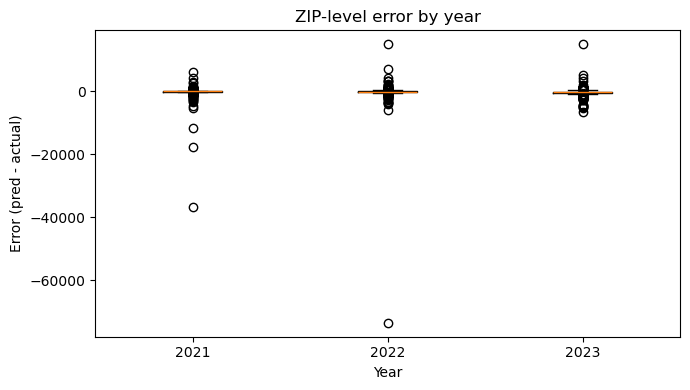

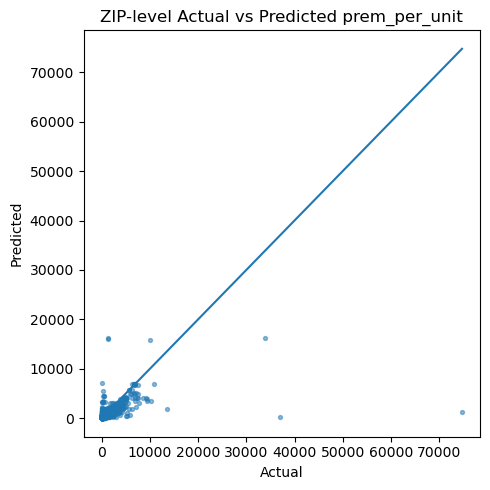

In [102]:
import matplotlib.pyplot as plt

# Pull posterior samples
post = idata.posterior.stack(sample=("chain","draw"))

alpha_s = post["alpha"].values                    # (S,)
u_zip_s = post["u_zip"].values                    # (n_zip, S)
gamma_s = post["gamma"].values                    # (T, S)

# Build test predictions in log space (posterior mean of mu)
zip_idx_test = test["zip_idx"].values
year_idx_test = test["year_idx"].values

# mu_samples: (n_test, S)
mu_samples = (alpha_s[None, :]
              + u_zip_s[zip_idx_test, :]
              + gamma_s[year_idx_test, :])

# Convert to prem_per_unit scale.
# Using exp(mu) = median of lognormal-ish; for mean on original scale you’d need sigma too.
pred_ppu_mean = np.exp(mu_samples).mean(axis=1)

eval_df = test[["zip","yr","prem_per_unit"]].copy()
eval_df = eval_df.rename(columns={"prem_per_unit":"actual_ppu"})
eval_df["pred_ppu"] = pred_ppu_mean

# errors
eval_df["err"] = eval_df["pred_ppu"] - eval_df["actual_ppu"]
eval_df["sq_err"] = eval_df["err"]**2

mse = eval_df["sq_err"].mean()
print("ZIP-level MSE (2021-2023 pooled):", mse)

mse_by_year = eval_df.groupby("yr")["sq_err"].mean()
print("\nMSE by year:\n", mse_by_year)

# ---- plots
plt.figure(figsize=(7,4))
plt.hist(eval_df["err"], bins=60)
plt.title("ZIP-level error: pred - actual (2021-2023 pooled)")
plt.xlabel("Error in prem_per_unit")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
years = sorted(eval_df["yr"].unique())
data = [eval_df.loc[eval_df["yr"]==y, "err"].values for y in years]
plt.boxplot(data, labels=years)
plt.title("ZIP-level error by year")
plt.xlabel("Year")
plt.ylabel("Error (pred - actual)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(eval_df["actual_ppu"], eval_df["pred_ppu"], s=8, alpha=0.5)
mn = min(eval_df["actual_ppu"].min(), eval_df["pred_ppu"].min())
mx = max(eval_df["actual_ppu"].max(), eval_df["pred_ppu"].max())
plt.plot([mn, mx], [mn, mx])
plt.title("ZIP-level Actual vs Predicted prem_per_unit")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()


In [104]:
# exposure-weighted avg using ACTUAL exposures from the sheets
eval_df2 = test[["zip","yr","earned_exp"]].merge(
    eval_df[["zip","yr","pred_ppu","actual_ppu"]],
    on=["zip","yr"],
    how="inner"
)

def wavg(x, val_col, w_col):
    return (x[val_col] * x[w_col]).sum() / x[w_col].sum()

year_summary = []
for y in test_years:
    sub = eval_df2[eval_df2["yr"]==y].copy()
    year_summary.append({
        "yr": y,
        "actual_avg_ppu": wavg(sub, "actual_ppu", "earned_exp"),
        "pred_avg_ppu":   wavg(sub, "pred_ppu", "earned_exp"),
    })

year_summary = pd.DataFrame(year_summary)
year_summary["err"] = year_summary["pred_avg_ppu"] - year_summary["actual_avg_ppu"]
print(year_summary)


     yr  actual_avg_ppu  pred_avg_ppu         err
0  2021      933.613755    865.861031  -67.752724
1  2022     1027.303500    874.978565 -152.324935
2  2023     1130.059007    881.519216 -248.539791


In [106]:
import numpy as np
import pandas as pd

# ---------- basic cleaning ----------
d = df.copy()
d["yr"] = pd.to_numeric(d["yr"], errors="coerce")
d["ZIP Code"] = pd.to_numeric(d["ZIP Code"], errors="coerce")
d["Earned Prem"] = pd.to_numeric(d.get("Earned Prem"), errors="coerce")
d["Earned Exp"]  = pd.to_numeric(d.get("Earned Exp"), errors="coerce")

# keep years you have covariates for
d = d.dropna(subset=["yr","ZIP Code","Earned Prem","Earned Exp"]).copy()
d = d[d["Earned Exp"] > 0].copy()

d["prem_per_unit"] = d["Earned Prem"] / d["Earned Exp"]
d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=["prem_per_unit"])
d = d[d["prem_per_unit"] > 0].copy()

# winsor + log target (stable)
lo, hi = d["prem_per_unit"].quantile([0.01, 0.99])
d["prem_use"] = d["prem_per_unit"].clip(lo, hi)
d["log_ppu"] = np.log(d["prem_use"])

# choose covariates you want to forecast (financial + climate)
X_cols = [
    # financial block (use your transformed ones if you want)
    "log_pop","log_gdp_pc","log_amt_pc","log_home_pc",
    "hpi","hpi_change","unemployment_rate","prop_rate",
    # climate block
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size",
]
X_cols = [c for c in X_cols if c in d.columns]

# ensure numeric
for c in X_cols:
    d[c] = pd.to_numeric(d[c], errors="coerce")

# training window (you can extend if you have more years — recommended)
train_years = [2018, 2019, 2020]
d_tr = d[d["yr"].isin(train_years)].dropna(subset=["log_ppu"] + X_cols).copy()

print("Train rows:", d_tr.shape, "Years:", sorted(d_tr["yr"].unique()))


Train rows: (5549, 35) Years: [2018, 2019, 2020]


In [108]:
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler

# ---------- build year-level covariate series ----------
def wavg_year(df_year, cols, wcol="Earned Exp"):
    w = df_year[wcol].values
    X = df_year[cols].values
    return (X * w[:, None]).sum(axis=0) / w.sum()

years = np.array(sorted(d_tr["yr"].unique()))
X_year = np.vstack([wavg_year(d_tr[d_tr["yr"]==y], X_cols) for y in years])

# standardize across years (crucial)
scaler = StandardScaler()
X_year_std = scaler.fit_transform(X_year)

T, P = X_year_std.shape
K = 3  # number of latent factors (try 2-4; 3 is a good start)

with pm.Model() as cov_model:
    # factor RW scale
    sigma_f = pm.HalfNormal("sigma_f", 0.5, shape=K)
    # observation noise per covariate
    sigma_x = pm.HalfNormal("sigma_x", 0.5, shape=P)

    # loadings
    Lambda = pm.Normal("Lambda", 0, 1.0, shape=(P, K))

    # latent factors (random walk)
    f0 = pm.Normal("f0", 0, 1.0, shape=K)
    eta = pm.Normal("eta", 0, 1.0, shape=(T-1, K))
    f = pm.Deterministic("f", pm.math.concatenate([f0[None, :],
                                                  f0[None, :] + pm.math.cumsum(eta * sigma_f, axis=0)]))

    mu = f @ Lambda.T  # (T,K) @ (K,P) => (T,P)

    pm.Normal("Xobs", mu=mu, sigma=sigma_x, observed=X_year_std)

    cov_idata = pm.sample(draws=2000, tune=2000, chains=4, target_accept=0.9, random_seed=42)

az.summary(cov_idata, var_names=["sigma_f","sigma_x"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_f, sigma_x, Lambda, f0, eta]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 172 seconds.
There were 1422 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_f[0],0.677,0.318,0.045,1.198,0.034,0.010,82.0,180.0,1.05
sigma_f[1],0.670,0.306,0.044,1.160,0.053,0.017,32.0,58.0,1.09
sigma_f[2],0.846,0.293,0.309,1.437,0.026,0.011,120.0,245.0,1.04
sigma_x[0],0.136,0.180,0.001,0.477,0.009,0.008,293.0,648.0,1.01
sigma_x[1],0.172,0.216,0.002,0.578,0.009,0.008,324.0,670.0,1.01
sigma_x[2],0.156,0.208,0.001,0.561,0.012,0.010,252.0,773.0,1.01
sigma_x[3],0.139,0.189,0.001,0.501,0.009,0.010,487.0,705.0,1.01
sigma_x[4],0.140,0.194,0.001,0.513,0.009,0.008,240.0,542.0,1.03
sigma_x[5],0.141,0.190,0.001,0.515,0.011,0.011,260.0,666.0,1.02
sigma_x[6],0.127,0.176,0.000,0.462,0.008,0.008,369.0,936.0,1.00


In [110]:
# years to forecast
future_years = np.array([2021, 2022, 2023])
H = len(future_years)

post = cov_idata.posterior.stack(sample=("chain","draw"))
Lambda_s = post["Lambda"].values          # (P,K,S)
sigma_f_s = post["sigma_f"].values        # (K,S)
f_s = post["f"].values                    # (T,K,S)

S = f_s.shape[-1]
f_last = f_s[-1, :, :]                    # (K,S)

# simulate factor random walk forward for each posterior draw
rng = np.random.default_rng(123)
f_future = np.zeros((H, K, S))
f_prev = f_last.copy()
for h in range(H):
    step = rng.normal(size=(K, S)) * sigma_f_s
    f_next = f_prev + step
    f_future[h, :, :] = f_next
    f_prev = f_next

# (optional) reconstruct future covariates (standardized scale):
X_future_std = np.einsum("hks,pks->hps", f_future, Lambda_s)  # (H,P,S)


In [112]:
# --- get factor values for train years from Stage 1 posterior (use posterior mean) ---
f_train_mean = cov_idata.posterior["f"].mean(dim=("chain","draw")).values  # shape (T,K)
year_to_pos = {y:i for i,y in enumerate(years)}
d_tr["year_pos"] = d_tr["yr"].map(year_to_pos).astype(int)

# zip indexing
zips = np.sort(d_tr["ZIP Code"].unique())
zip_to_idx = {z:i for i,z in enumerate(zips)}
d_tr["zip_idx"] = d_tr["ZIP Code"].map(zip_to_idx).astype(int)

y_obs = d_tr["log_ppu"].values
zip_idx = d_tr["zip_idx"].values
year_pos = d_tr["year_pos"].values
n_zip = len(zips)

# design: factor values per observation
F_obs = f_train_mean[year_pos, :]  # (N,K)

with pm.Model() as prem_model:
    nu = pm.Exponential("nu_minus2", 1/10) + 2

    alpha = pm.Normal("alpha", mu=y_obs.mean(), sigma=1.0)

    sigma_zip = pm.HalfNormal("sigma_zip", 0.5)
    u_zip = pm.Normal("u_zip", 0, sigma_zip, shape=n_zip)

    # coefficients on factors
    beta = pm.Normal("beta", 0, 0.5, shape=K)  # PC/factor coefficients should be modest on log scale

    sigma = pm.HalfNormal("sigma", 0.5)

    mu = alpha + u_zip[zip_idx] + pm.math.sum(F_obs * beta, axis=1)

    pm.StudentT("y", nu=nu, mu=mu, sigma=sigma, observed=y_obs)

    prem_idata = pm.sample(draws=2000, tune=2000, chains=4, target_accept=0.9, random_seed=42)

az.summary(prem_idata, var_names=["alpha","beta","sigma","sigma_zip","nu_minus2"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [nu_minus2, alpha, sigma_zip, u_zip, beta, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 715 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,7.040,0.007,7.026,7.053,0.001,0.001,28.0,35.0,1.1
beta[0],-0.122,0.434,-0.916,0.712,0.007,0.005,4251.0,4939.0,1.0
beta[1],0.232,0.005,0.223,0.241,0.000,0.000,4243.0,4693.0,1.0
beta[2],0.214,0.266,-0.274,0.726,0.004,0.003,4242.0,4709.0,1.0
sigma,0.016,0.000,0.015,0.016,0.000,0.000,4604.0,6218.0,1.0
sigma_zip,0.401,0.007,0.388,0.413,0.000,0.000,6011.0,5923.0,1.0
nu_minus2,0.005,0.005,0.000,0.013,0.000,0.000,7729.0,3804.0,1.0


In [126]:
import pandas as pd
import numpy as np
from pathlib import Path

processed_dir = Path.home() / "Documents/duke_mss/stat_698/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data"
xlsx_path = processed_dir / "Residential-Property-Coverage-Amounts-Wildfire-Risk-and-Losses_Export.xlsx"

def read_export_sheet(sheet):
    raw = pd.read_excel(xlsx_path, sheet_name=sheet, header=None)

    header_row = None
    for i in range(min(50, len(raw))):
        row_vals = raw.iloc[i].astype(str).str.lower().tolist()
        if any("earned prem" in v for v in row_vals) and any("earned exp" in v for v in row_vals):
            header_row = i
            break
    if header_row is None:
        raise ValueError(f"Could not find header row in {sheet}")

    headers = [str(x).strip() for x in raw.iloc[header_row].tolist()]
    df = raw.iloc[header_row+1:].copy()
    df.columns = headers
    df = df.dropna(axis=1, how="all")
    return df

def zip_year_actual(year):
    sheet = f"Export_{str(year)[-2:]}"
    d = read_export_sheet(sheet).copy()
    d.columns = [str(c).strip() for c in d.columns]

    # Optional: restrict to All Companies
    if "Source" in d.columns:
        d = d[d["Source"].astype(str).str.strip().eq("All Companies")].copy()

    zip_col = "ZIP Code"
    prem_col = "Earned Prem"
    exp_col  = "Earned Exp"

    d[zip_col]  = pd.to_numeric(d[zip_col], errors="coerce")
    d[prem_col] = pd.to_numeric(d[prem_col], errors="coerce")
    d[exp_col]  = pd.to_numeric(d[exp_col], errors="coerce")

    d = d.dropna(subset=[zip_col, prem_col, exp_col]).copy()
    d = d[d[exp_col] > 0].copy()

    # aggregate to ZIP-year totals (across policy types, etc.)
    out = d.groupby(zip_col, as_index=False).agg({prem_col:"sum", exp_col:"sum"})
    out = out.rename(columns={zip_col:"zip", prem_col:"earned_prem", exp_col:"earned_exp"})
    out["yr"] = year
    out["prem_per_unit_actual"] = out["earned_prem"] / out["earned_exp"]
    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=["prem_per_unit_actual"])
    out = out[out["prem_per_unit_actual"] > 0].copy()

    out["zip"] = out["zip"].astype(int)
    return out[["zip","yr","earned_prem","earned_exp","prem_per_unit_actual"]]

actual_zip_year = pd.concat([zip_year_actual(y) for y in [2021, 2022, 2023]], ignore_index=True)

print("ZIP-year actual shape:", actual_zip_year.shape)
print(actual_zip_year.head())
print("Unique ZIPs:", actual_zip_year["zip"].nunique())


ZIP-year actual shape: (6397, 5)
     zip    yr  earned_prem  earned_exp  prem_per_unit_actual
0  90001  2021      4249540        8721            487.276688
1  90002  2021      4329968        8143            531.741127
2  90003  2021      5871826       10572            555.412978
3  90004  2021     11959019       11261           1061.985525
4  90005  2021      4318712        6458            668.738309
Unique ZIPs: 2251


In [128]:
actual_df = actual_zip_year  # <-- use this for the ZIP-level error code


ZIP-level MSE (2021-2023 pooled): 2513703.3087569554
MSE by year:
 yr
2021    1.281411e+06
2022    4.174812e+06
2023    2.082572e+06
Name: sq_err, dtype: float64


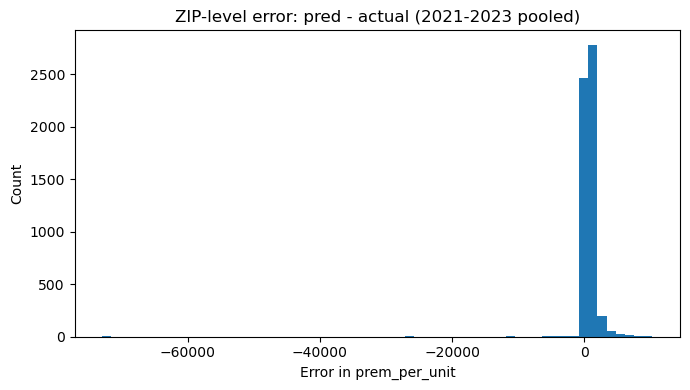

/var/folders/26/4y4fzxhd7td390hxfyvrnw1m0000gp/T/ipykernel_40070/2108730450.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=years_plot)


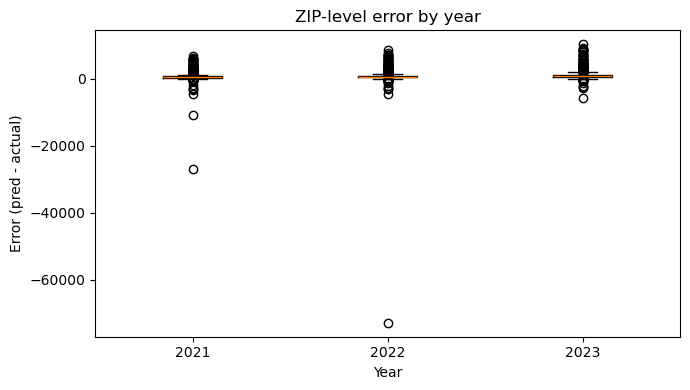

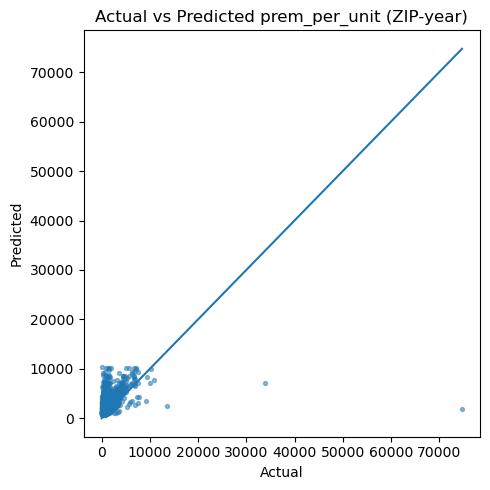

In [130]:
# ----- build actual ZIP-year ppu from Excel for 2021-2023 (you already have functions) -----
# actual_df must have columns: zip (int), yr, prem_per_unit_actual
# where zip matches ZIP Code format in d_tr (numeric)
# (Use your earlier Excel extraction and rename accordingly.)

# Example placeholder:
# actual_df = actual  # if you built it as: zip, yr, prem_per_unit_actual

# ----- align zips: only those seen in training -----
actual_df = actual_df[actual_df["zip"].isin(zips)].copy()

# posterior samples from premium model
post_p = prem_idata.posterior.stack(sample=("chain","draw"))
alpha_s = post_p["alpha"].values          # (S,)
beta_s  = post_p["beta"].values           # (K,S)
u_s     = post_p["u_zip"].values          # (n_zip,S)

S2 = alpha_s.shape[0]
S = min(S, S2)  # align sample counts if different
alpha_s = alpha_s[:S]
beta_s  = beta_s[:, :S]
u_s     = u_s[:, :S]
f_future_use = f_future[:, :, :S]         # (H,K,S)

# mapping for ZIP index
zip_to_idx2 = {z:i for i,z in enumerate(zips)}

# make prediction rows for actual zip-year keys
keys = actual_df[["zip","yr","prem_per_unit_actual"]].copy()
keys["zip_idx"] = keys["zip"].map(zip_to_idx2).astype(int)
year_to_h = {2021:0, 2022:1, 2023:2}
keys["h"] = keys["yr"].map(year_to_h).astype(int)

zip_idx_k = keys["zip_idx"].values
h_k = keys["h"].values
n_keys = len(keys)

# mu_samples: (n_keys, S)
mu_samples = (
    alpha_s[None, :]
    + u_s[zip_idx_k, :]
    + np.einsum("nks,ks->ns", f_future_use[h_k, :, :], beta_s)
)

pred_ppu_mean = np.exp(mu_samples).mean(axis=1)  # posterior mean on ppu scale

keys["pred_ppu"] = pred_ppu_mean
keys["err"] = keys["pred_ppu"] - keys["prem_per_unit_actual"]
keys["sq_err"] = keys["err"]**2

mse = keys["sq_err"].mean()
print("ZIP-level MSE (2021-2023 pooled):", mse)

mse_by_year = keys.groupby("yr")["sq_err"].mean()
print("MSE by year:\n", mse_by_year)

# ----- plots -----
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(keys["err"], bins=60)
plt.title("ZIP-level error: pred - actual (2021-2023 pooled)")
plt.xlabel("Error in prem_per_unit")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
years_plot = sorted(keys["yr"].unique())
data = [keys.loc[keys["yr"]==y, "err"].values for y in years_plot]
plt.boxplot(data, labels=years_plot)
plt.title("ZIP-level error by year")
plt.xlabel("Year")
plt.ylabel("Error (pred - actual)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(keys["prem_per_unit_actual"], keys["pred_ppu"], s=8, alpha=0.5)
mn = min(keys["prem_per_unit_actual"].min(), keys["pred_ppu"].min())
mx = max(keys["prem_per_unit_actual"].max(), keys["pred_ppu"].max())
plt.plot([mn, mx], [mn, mx])
plt.title("Actual vs Predicted prem_per_unit (ZIP-year)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()


In [132]:
# keys has: zip, yr, prem_per_unit_actual, pred_ppu, err, sq_err
outlier_k = 20

outliers = keys.sort_values("err", ascending=True).head(outlier_k)  # most negative (pred << actual)
outliers2 = keys.sort_values("err", ascending=False).head(outlier_k) # most positive (pred >> actual)

print("Most NEGATIVE errors (pred - actual):")
display(outliers[["zip","yr","prem_per_unit_actual","pred_ppu","err"]].head(outlier_k))

print("\nMost POSITIVE errors (pred - actual):")
display(outliers2[["zip","yr","prem_per_unit_actual","pred_ppu","err"]].head(outlier_k))

# single worst by absolute error
worst = keys.loc[keys["err"].abs().idxmax()].copy()
print("\nWorst absolute-error row:")
print(worst[["zip","yr","prem_per_unit_actual","pred_ppu","err"]])


Most NEGATIVE errors (pred - actual):


,zip,yr,prem_per_unit_actual,pred_ppu,err
2180,90051,2022,74730.000000,1833.265315,-72896.734685
97,90264,2021,33983.000000,7159.375066,-26823.624934
129,90506,2021,13476.000000,2519.948716,-10956.051284
5015,92658,2023,9242.000000,3582.200232,-5659.799768
2883,92658,2022,7588.500000,3037.709972,-4550.790028
747,92658,2021,7007.500000,2592.394054,-4415.105946
382,91944,2021,7856.000000,4395.759921,-3460.240079
1230,94119,2021,7426.500000,4393.269236,-3033.230764
3396,94188,2022,10798.000000,7835.808215,-2962.191785
2979,93002,2022,5209.000000,2258.526660,-2950.473340



Most POSITIVE errors (pred - actual):


,zip,yr,prem_per_unit_actual,pred_ppu,err
5910,95402,2023,142.000000,10439.718969,10297.718969
4289,90020,2023,976.942903,10101.669043,9124.726140
4796,92235,2023,217.000000,9154.654530,8937.654530
5661,94914,2023,1420.000000,10081.056143,8661.056143
5493,94111,2023,622.184411,9280.636261,8658.451850
5496,94115,2023,1501.226258,10103.674796,8602.448538
3785,95402,2022,198.000000,8742.474617,8544.474617
4330,90067,2023,1909.024165,10095.543303,8186.519137
4332,90069,2023,1592.625410,9753.260864,8160.635454
5491,94109,2023,686.681332,8704.954271,8018.272939



Worst absolute-error row:
zip                     90051.000000
yr                       2022.000000
prem_per_unit_actual    74730.000000
pred_ppu                 1833.265315
err                    -72896.734685
Name: 2180, dtype: float64


Dropped |err| > 1000: 1208 / 5576 (21.66%) remaining=4368
ZIP-level MSE (2021-2023 pooled, filtered): 354510.0588618608
MSE by year (filtered):
 yr
2021    257142.023389
2022    354687.722968
2023    485392.903998
Name: sq_err, dtype: float64


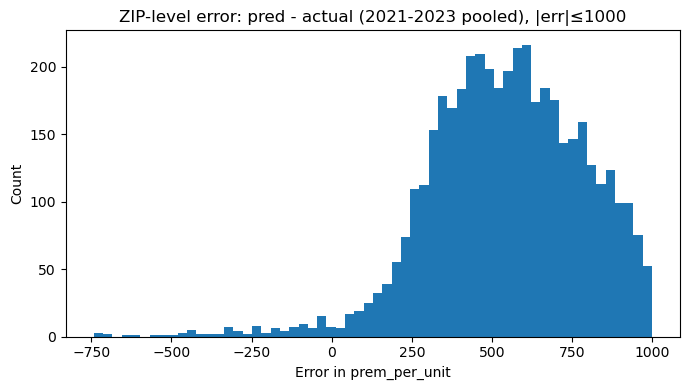

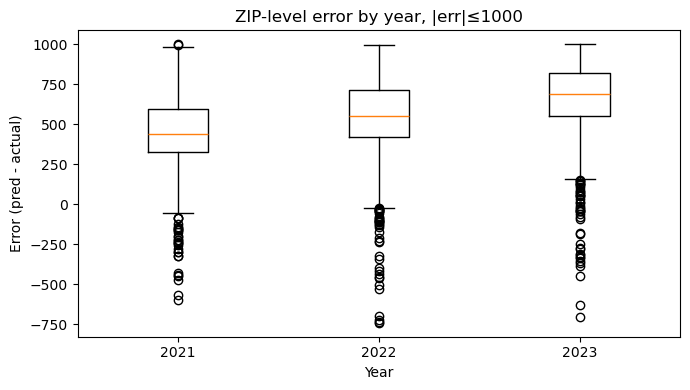

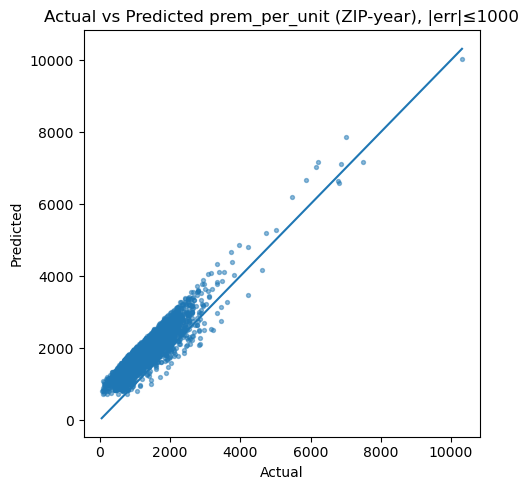


Top 15 dropped by abs_err:
        zip    yr  prem_per_unit_actual      pred_ppu           err  \
2180  90051  2022          74730.000000   1833.265315 -72896.734685   
97    90264  2021          33983.000000   7159.375066 -26823.624934   
129   90506  2021          13476.000000   2519.948716 -10956.051284   
5910  95402  2023            142.000000  10439.718969  10297.718969   
4289  90020  2023            976.942903  10101.669043   9124.726140   
4796  92235  2023            217.000000   9154.654530   8937.654530   
5661  94914  2023           1420.000000  10081.056143   8661.056143   
5493  94111  2023            622.184411   9280.636261   8658.451850   
5496  94115  2023           1501.226258  10103.674796   8602.448538   
3785  95402  2022            198.000000   8742.474617   8544.474617   
4330  90067  2023           1909.024165  10095.543303   8186.519137   
4332  90069  2023           1592.625410   9753.260864   8160.635454   
5491  94109  2023            686.681332   8704.95

In [134]:
# ----- align zips: only those seen in training -----
actual_df = actual_df[actual_df["zip"].isin(zips)].copy()

# posterior samples from premium model
post_p = prem_idata.posterior.stack(sample=("chain","draw"))
alpha_s = post_p["alpha"].values          # (S,)
beta_s  = post_p["beta"].values           # (K,S)
u_s     = post_p["u_zip"].values          # (n_zip,S)

S2 = alpha_s.shape[0]
S = min(S, S2)  # align sample counts if different
alpha_s = alpha_s[:S]
beta_s  = beta_s[:, :S]
u_s     = u_s[:, :S]
f_future_use = f_future[:, :, :S]         # (H,K,S)

# mapping for ZIP index
zip_to_idx2 = {z:i for i,z in enumerate(zips)}

# make prediction rows for actual zip-year keys
keys = actual_df[["zip","yr","prem_per_unit_actual"]].copy()
keys["zip_idx"] = keys["zip"].map(zip_to_idx2).astype(int)
year_to_h = {2021:0, 2022:1, 2023:2}
keys["h"] = keys["yr"].map(year_to_h).astype(int)

zip_idx_k = keys["zip_idx"].values
h_k = keys["h"].values
n_keys = len(keys)

# mu_samples: (n_keys, S)
mu_samples = (
    alpha_s[None, :]
    + u_s[zip_idx_k, :]
    + np.einsum("nks,ks->ns", f_future_use[h_k, :, :], beta_s)
)

pred_ppu_mean = np.exp(mu_samples).mean(axis=1)  # posterior mean on ppu scale

keys["pred_ppu"] = pred_ppu_mean
keys["err"] = keys["pred_ppu"] - keys["prem_per_unit_actual"]
keys["abs_err"] = keys["err"].abs()

# -----------------------------
# DROP OUTLIERS by |error| > 1000
# -----------------------------
thr = 1000
n0 = len(keys)
keys_f = keys[keys["abs_err"] <= thr].copy()
n1 = len(keys_f)
dropped = n0 - n1
print(f"Dropped |err| > {thr}: {dropped} / {n0} ({dropped/n0:.2%}) remaining={n1}")

# recompute squared error + MSE on filtered set
keys_f["sq_err"] = keys_f["err"]**2

mse = keys_f["sq_err"].mean()
print("ZIP-level MSE (2021-2023 pooled, filtered):", mse)

mse_by_year = keys_f.groupby("yr")["sq_err"].mean()
print("MSE by year (filtered):\n", mse_by_year)

# ----- plots -----
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(keys_f["err"], bins=60)
plt.title(f"ZIP-level error: pred - actual (2021-2023 pooled), |err|≤{thr}")
plt.xlabel("Error in prem_per_unit")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
years_plot = sorted(keys_f["yr"].unique())
data = [keys_f.loc[keys_f["yr"]==y, "err"].values for y in years_plot]
plt.boxplot(data, tick_labels=years_plot)  # avoids matplotlib deprecation warning
plt.title(f"ZIP-level error by year, |err|≤{thr}")
plt.xlabel("Year")
plt.ylabel("Error (pred - actual)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(keys_f["prem_per_unit_actual"], keys_f["pred_ppu"], s=8, alpha=0.5)
mn = min(keys_f["prem_per_unit_actual"].min(), keys_f["pred_ppu"].min())
mx = max(keys_f["prem_per_unit_actual"].max(), keys_f["pred_ppu"].max())
plt.plot([mn, mx], [mn, mx])
plt.title(f"Actual vs Predicted prem_per_unit (ZIP-year), |err|≤{thr}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

# Optional: keep the dropped rows for inspection
dropped_rows = keys[keys["abs_err"] > thr].copy()
print("\nTop 15 dropped by abs_err:")
print(dropped_rows.sort_values("abs_err", ascending=False).head(15)[
    ["zip","yr","prem_per_unit_actual","pred_ppu","err","abs_err"]
])


In [142]:
actual_df

,zip,yr,earned_prem,earned_exp,prem_per_unit_actual
0,90001,2021,4249540,8721,487.276688
1,90002,2021,4329968,8143,531.741127
2,90003,2021,5871826,10572,555.412978
3,90004,2021,11959019,11261,1061.985525
4,90005,2021,4318712,6458,668.738309
...,...,...,...,...,...
6391,96155,2023,53078,25,2123.120000
6393,96158,2023,56045,28,2001.607143
6394,96160,2023,29865,10,2986.500000
6395,96161,2023,54577536,18726,2914.532522


In [148]:
dfp

,yr,ZIP Code,Earned Prem,Earned Exp,county_fips5,hpi_change,hpi,state,flood_frequency,flood_property_damage,...,county_fips,total_home_purchase,total_amt_purchase,total_population,prem_per_unit,prem_w,log_prem_w,prem_use,log_prem,log_prem_unit
0,2018,90001,1233018,1799,6037.0,6.71,1566.79,CALIFORNIA,0.0,0.0,...,6037.0,52076.0,3.046519e+10,10061533.0,685.390773,685.390773,6.529989,685.390773,6.529989,6.529989
1,2019,90001,1351943,1863,6037.0,3.50,1621.68,CALIFORNIA,0.0,0.0,...,6037.0,53991.0,3.281898e+10,10011602.0,725.680623,725.680623,6.587110,725.680623,6.587110,6.587110
2,2020,90001,1496492,1908,6037.0,2.72,1665.85,CALIFORNIA,2.0,0.0,...,6037.0,55477.0,3.715788e+10,9996634.0,784.324948,784.324948,6.664823,784.324948,6.664823,6.664823
3,2018,90002,1721682,2517,6037.0,6.71,1566.79,CALIFORNIA,0.0,0.0,...,6037.0,52076.0,3.046519e+10,10061533.0,684.021454,684.021454,6.527989,684.021454,6.527989,6.527989
4,2019,90002,1923430,2660,6037.0,3.50,1621.68,CALIFORNIA,0.0,0.0,...,6037.0,53991.0,3.281898e+10,10011602.0,723.093985,723.093985,6.583539,723.093985,6.583539,6.583539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5684,2019,91393,780,1,6037.0,3.50,1621.68,CALIFORNIA,0.0,0.0,...,6037.0,53991.0,3.281898e+10,10011602.0,780.000000,780.000000,6.659294,780.000000,6.659294,6.659294
5688,2020,91921,811,1,6073.0,3.36,1412.49,CALIFORNIA,21.0,390000.0,...,6073.0,32881.0,1.938722e+10,3301182.0,811.000000,811.000000,6.698268,811.000000,6.698268,6.698268
5689,2020,93005,343,1,6111.0,2.24,1543.42,CALIFORNIA,0.0,0.0,...,6111.0,7880.0,4.481700e+09,843808.0,343.000000,571.766257,6.348730,571.766257,6.348730,5.837730
5690,2020,93714,617,1,6019.0,4.16,780.31,CALIFORNIA,4.0,0.0,...,6019.0,10264.0,2.858960e+09,1009613.0,617.000000,617.000000,6.424869,617.000000,6.424869,6.424869


In [174]:
import pandas as pd
from pathlib import Path

# from your current notebook/script location:
csv_path = Path("../../02_processed_data/final_df_insurance_merged_data_in_california_2021_included.csv")

df = pd.read_csv(csv_path, low_memory=False)
print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())


Shape: (15342, 23)
     zip  county_fips5    yr  hpi_change      hpi  flood_frequency  \
0  90001        6037.0  2017        6.85  1468.26              7.0   
1  90002        6037.0  2017        6.85  1468.26              7.0   
2  90003        6037.0  2017        6.85  1468.26              7.0   
3  90004        6037.0  2017        6.85  1468.26              7.0   
4  90005        6037.0  2017        6.85  1468.26              7.0   

   flood_property_damage  flood_duration_hours  heat_stress_index  \
0                    0.0                  9.75           0.557622   
1                    0.0                  9.75           0.557622   
2                    0.0                  9.75           0.557622   
3                    0.0                  9.75           0.557622   
4                    0.0                  9.75           0.557622   

   drought_annual_mean_index  ...  injuries_hurricane  damage_hurricane  \
0                      -2.72  ...                 0.0               0.

In [200]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 0) Build COUNTY-YEAR dataset (expects final_df exists)
# -----------------------------
id_col, time_col = "county_fips5", "yr"

df[time_col] = pd.to_numeric(df[time_col], errors="coerce").astype("Int64")
df[id_col] = df[id_col].astype(str).str.zfill(5)
df["Earned Prem"] = pd.to_numeric(df["Earned Prem"], errors="coerce")
df["Earned Exp"]  = pd.to_numeric(df["Earned Exp"],  errors="coerce")

df = df[df[time_col].between(2018, 2021)].copy()

# county-year insurance aggregation
ins_cty = (
    df.groupby([id_col, time_col], as_index=False)
      .agg({"Earned Prem": "sum", "Earned Exp": "sum"})
)
ins_cty["prem_per_unit"] = np.where(ins_cty["Earned Exp"].gt(0),
                                    ins_cty["Earned Prem"] / ins_cty["Earned Exp"],
                                    np.nan)

# county-year features (mean, since repeated across zips)
drop_cols = [c for c in ["zip", "Earned Prem", "Earned Exp", "prem_per_unit"] if c in df.columns]
feat_cty = (
    df.drop(columns=drop_cols, errors="ignore")
      .groupby([id_col, time_col], as_index=False)
      .mean(numeric_only=True)
)

df_cty = feat_cty.merge(ins_cty[[id_col, time_col, "prem_per_unit"]], on=[id_col, time_col], how="inner")
df_cty = df_cty[df_cty["prem_per_unit"].notna() & (df_cty["prem_per_unit"] > 0)].copy()

# log target
df_cty["y_log"] = np.log(df_cty["prem_per_unit"].astype(float))

# -----------------------------
# 1) Select features (no lagging)
# -----------------------------
numeric_cols = df_cty.select_dtypes(include=[np.number]).columns.tolist()
exclude = {"prem_per_unit", "y_log", time_col, "Unnamed: 0", "county_fips"}
feature_cols = [c for c in numeric_cols if c not in exclude]

# -----------------------------
# 2) Time splits
# -----------------------------
train_df = df_cty[df_cty[time_col].isin([2018, 2019])].copy()
val_df   = df_cty[df_cty[time_col] == 2020].copy()
test_df  = df_cty[df_cty[time_col] == 2021].copy()

def XY(d):
    return d[feature_cols].values, d["y_log"].values

X_tr, y_tr = XY(train_df)
X_va, y_va = XY(val_df)
X_te, y_te = XY(test_df)

# -----------------------------
# 3) Pipeline: impute -> scale -> lasso
# -----------------------------
# We'll tune alpha using the 2020 validation set (time-faithful)
alphas = np.logspace(-4, 1, 60)

best_alpha, best_rmse = None, np.inf
best_model = None

for a in alphas:
    model = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        ("lasso", Lasso(alpha=a, max_iter=20000, random_state=42))
    ])
    model.fit(X_tr, y_tr)
    pred_va = model.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_va, pred_va))
    if rmse < best_rmse:
        best_rmse, best_alpha, best_model = rmse, a, model

print("Best alpha from 2020 validation:", best_alpha, "| val RMSE_log:", best_rmse)

# Refit on 2018-2020 with best alpha
trainval_df = df_cty[df_cty[time_col].isin([2018, 2019, 2020])].copy()
X_tv, y_tv = XY(trainval_df)

final_model = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("lasso", Lasso(alpha=best_alpha, max_iter=20000, random_state=42))
])
final_model.fit(X_tv, y_tv)

# -----------------------------
# 4) Evaluate on 2021
# -----------------------------
y_pred_log = final_model.predict(X_te)

rmse_log = float(np.sqrt(mean_squared_error(y_te, y_pred_log)))
mae_log  = float(mean_absolute_error(y_te, y_pred_log))
r2_log   = float(r2_score(y_te, y_pred_log))

print("\n===== 2021 LOG-SPACE METRICS (Lasso) =====")
print("RMSE_log:", rmse_log, "| MAE_log:", mae_log, "| R2_log:", r2_log)

# back-transform
y_true = np.exp(y_te)
y_pred = np.exp(y_pred_log)

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))
eps = 1e-8
smape = float(np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100.0)

print("\n===== 2021 LEVEL METRICS (exp back-transform) =====")
print("RMSE:", rmse, "| MAE:", mae, "| R2:", r2, "| sMAPE:", smape)

# -----------------------------
# 5) Inspect selected variables
# -----------------------------
lasso = final_model.named_steps["lasso"]
coef = pd.Series(lasso.coef_, index=feature_cols)
selected = coef[coef.abs() > 1e-12].sort_values(key=np.abs, ascending=False)

print("\nSelected features (non-zero):", selected.shape[0])
print(selected.head(20))

# Save preds
out = test_df[[id_col, time_col, "prem_per_unit"]].copy()
out["y_true_log"] = y_te
out["y_pred_log"] = y_pred_log
out["y_pred"] = y_pred
out["abs_err"] = np.abs(out["prem_per_unit"] - out["y_pred"])
#out.to_csv("county_2021_preds_lasso_logtarget.csv", index=False)
print("\nSaved county_2021_preds_lasso_logtarget.csv")


Best alpha from 2020 validation: 0.0001 | val RMSE_log: 0.2056169302011713

===== 2021 LOG-SPACE METRICS (Lasso) =====
RMSE_log: 0.3249452154140554 | MAE_log: 0.2624234815498309 | R2_log: -1.0412211163769518

===== 2021 LEVEL METRICS (exp back-transform) =====
RMSE: 446.6413676761254 | MAE: 341.7336890744949 | R2: -0.9496042857161864 | sMAPE: 25.827874145423667

Selected features (non-zero): 13
amt_purchase_per_cap         0.209192
hpi                         -0.109079
home_purchase_per_cap       -0.102023
heat_stress_index           -0.064354
hpi_change                  -0.039013
drought_annual_mean_index    0.034807
flood_duration_hours        -0.031864
prop_rate                   -0.031239
unemployment_rate            0.024123
fire_frequency               0.023094
flood_frequency              0.015242
fire_size                    0.012831
flood_property_damage        0.011639
dtype: float64

Saved county_2021_preds_lasso_logtarget.csv


In [202]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- df_cty is the county-year dataset you already built ---
# it must have: county_fips5, yr, prem_per_unit, y_log, and your numeric features

# 1) Add year dummies (keeps "yr" information)
df_fe = df_cty.copy()
df_fe["yr"] = df_fe["yr"].astype(int)
df_fe = pd.get_dummies(df_fe, columns=["yr"], drop_first=True)  # adds yr_2019, yr_2020, yr_2021

# 2) Build feature columns AFTER dummies
numeric_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
exclude = {"prem_per_unit", "y_log"}  # keep yr_* dummies in X
feature_cols_fe = [c for c in numeric_cols if c not in exclude]

# 3) Time splits based on original yr values (use df_cty for masks)
train_mask = df_cty["yr"].isin([2018, 2019]).values
val_mask   = (df_cty["yr"] == 2020).values
test_mask  = (df_cty["yr"] == 2021).values

X_tr = df_fe.loc[train_mask, feature_cols_fe].values
y_tr = df_fe.loc[train_mask, "y_log"].values

X_va = df_fe.loc[val_mask, feature_cols_fe].values
y_va = df_fe.loc[val_mask, "y_log"].values

X_te = df_fe.loc[test_mask, feature_cols_fe].values
y_te = df_fe.loc[test_mask, "y_log"].values

# 4) Tune alpha using 2020 (time-faithful)
alphas = np.logspace(-4, 1, 60)
best_alpha, best_rmse, best_model = None, np.inf, None

for a in alphas:
    model = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        ("lasso", Lasso(alpha=a, max_iter=20000, random_state=42))
    ])
    model.fit(X_tr, y_tr)
    pred_va = model.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_va, pred_va))
    if rmse < best_rmse:
        best_rmse, best_alpha, best_model = rmse, a, model

print("Best alpha from 2020 validation:", best_alpha, "| val RMSE_log:", best_rmse)

# 5) Refit on 2018-2020
trainval_mask = df_cty["yr"].isin([2018, 2019, 2020]).values
X_tv = df_fe.loc[trainval_mask, feature_cols_fe].values
y_tv = df_fe.loc[trainval_mask, "y_log"].values

final_model = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("lasso", Lasso(alpha=best_alpha, max_iter=20000, random_state=42))
])
final_model.fit(X_tv, y_tv)

# 6) Evaluate on 2021
y_pred_log = final_model.predict(X_te)

rmse_log = float(np.sqrt(mean_squared_error(y_te, y_pred_log)))
mae_log  = float(mean_absolute_error(y_te, y_pred_log))
r2_log   = float(r2_score(y_te, y_pred_log))

print("\n===== 2021 LOG-SPACE METRICS (Lasso + year dummies) =====")
print("RMSE_log:", rmse_log, "| MAE_log:", mae_log, "| R2_log:", r2_log)

# back-transform to level
y_true = np.exp(y_te)
y_pred = np.exp(y_pred_log)

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))
eps = 1e-8
smape = float(np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100.0)

print("\n===== 2021 LEVEL METRICS (exp back-transform) =====")
print("RMSE:", rmse, "| MAE:", mae, "| R2:", r2, "| sMAPE:", smape)

# Inspect coefficients (including yr_* dummies)
lasso = final_model.named_steps["lasso"]
coef = pd.Series(lasso.coef_, index=feature_cols_fe)
selected = coef[coef.abs() > 1e-12].sort_values(key=np.abs, ascending=False)

print("\nSelected features (non-zero):", selected.shape[0])
print(selected.head(30))


Best alpha from 2020 validation: 0.0001 | val RMSE_log: 0.20521705860841388

===== 2021 LOG-SPACE METRICS (Lasso + year dummies) =====
RMSE_log: 0.3249066077803012 | MAE_log: 0.2623895798695915 | R2_log: -1.0407360990145595

===== 2021 LEVEL METRICS (exp back-transform) =====
RMSE: 446.6014571283497 | MAE: 341.6978249907411 | R2: -0.9492558795711474 | sMAPE: 25.824615024423377

Selected features (non-zero): 14
amt_purchase_per_cap         0.199645
hpi                         -0.095903
home_purchase_per_cap       -0.094217
heat_stress_index           -0.064639
hpi_change                  -0.039556
drought_annual_mean_index    0.034861
prop_rate                   -0.034844
flood_duration_hours        -0.031803
unemployment_rate            0.024223
fire_frequency               0.022117
flood_frequency              0.014357
county_fips                 -0.014169
fire_size                    0.013558
flood_property_damage        0.012869
dtype: float64


In [208]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================
# 0) Start from county-year df_cty you already built
# Must have: county_fips5, yr, prem_per_unit, y_log, and numeric features
# =========================
df_model = df_cty.copy()

id_col = "county_fips5"
time_col = "yr"

df_model[id_col] = df_model[id_col].astype(str).str.zfill(5)
df_model[time_col] = df_model[time_col].astype(int)

# =========================
# 1) Split (no lagging)
# =========================
train_df = df_model[df_model[time_col].isin([2018, 2019, 2020])].copy()
test_df  = df_model[df_model[time_col] == 2021].copy()

y_train = train_df["y_log"].values
y_test  = test_df["y_log"].values

# =========================
# 2) Feature sets
#   - numeric features: drop IDs, target, and any ID-like columns
#   - categorical: county fixed effect
# =========================
bad_num = {"prem_per_unit", "y_log", time_col, "county_fips", "Unnamed: 0"}
num_cols = [c for c in df_model.select_dtypes(include=[np.number]).columns if c not in bad_num]

cat_cols = [id_col]  # county intercept / random effect

X_train = train_df[num_cols + cat_cols]
X_test  = test_df[num_cols + cat_cols]

# =========================
# 3) Preprocess + model
# =========================
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cty", OneHotEncoder(handle_unknown="ignore", drop=None), cat_cols),
    ],
    remainder="drop"
)

# Ridge = L2 regularization (stable with correlated features)
model = Pipeline([
    ("pre", pre),
    ("ridge", Ridge(alpha=10.0, random_state=42))
])

model.fit(X_train, y_train)
y_pred_log = model.predict(X_test)

# =========================
# 4) Evaluate (log space)
# =========================
rmse_log = float(np.sqrt(mean_squared_error(y_test, y_pred_log)))
mae_log  = float(mean_absolute_error(y_test, y_pred_log))
r2_log   = float(r2_score(y_test, y_pred_log))

print("\n===== 2021 LOG-SPACE METRICS (Ridge + county FE) =====")
print("RMSE_log:", rmse_log, "| MAE_log:", mae_log, "| R2_log:", r2_log)

# =========================
# 5) Evaluate (level space)
# =========================
y_true = np.exp(y_test)
y_pred = np.exp(y_pred_log)

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))
eps = 1e-8
smape = float(np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100.0)

print("\n===== 2021 LEVEL METRICS (exp back-transform) =====")
print("RMSE:", rmse, "| MAE:", mae, "| R2:", r2, "| sMAPE:", smape)

# =========================
# 6) Save predictions
# =========================
out = test_df[[id_col, time_col, "prem_per_unit"]].copy()
out["y_true_log"] = y_test
out["y_pred_log"] = y_pred_log
out["y_pred"] = np.exp(y_pred_log)
out["abs_err"] = np.abs(out["prem_per_unit"] - out["y_pred"])
out.to_csv("county_2021_preds_ridge_countyFE_logtarget.csv", index=False)
print("\nSaved county_2021_preds_ridge_countyFE_logtarget.csv")



===== 2021 LOG-SPACE METRICS (Ridge + county FE) =====
RMSE_log: 0.3041427019609241 | MAE_log: 0.24764624678815966 | R2_log: -0.7882348681104439

===== 2021 LEVEL METRICS (exp back-transform) =====
RMSE: 423.38060164057146 | MAE: 325.7049901485368 | R2: -0.75182408477074 | sMAPE: 24.429548731201947

Saved county_2021_preds_ridge_countyFE_logtarget.csv


In [206]:
from sklearn.linear_model import ElasticNet

alphas = np.logspace(-4, 2, 50)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

best = None
best_rmse = np.inf

# time-faithful: tune on 2020
tr = df_model[df_model[time_col].isin([2018, 2019])].copy()
va = df_model[df_model[time_col] == 2020].copy()
te = df_model[df_model[time_col] == 2021].copy()

X_tr, y_tr = tr[num_cols + cat_cols], tr["y_log"].values
X_va, y_va = va[num_cols + cat_cols], va["y_log"].values
X_te, y_te = te[num_cols + cat_cols], te["y_log"].values

for a in alphas:
    for l1 in l1_ratios:
        m = Pipeline([
            ("pre", pre),
            ("enet", ElasticNet(alpha=a, l1_ratio=l1, max_iter=100000, random_state=42))
        ])
        m.fit(X_tr, y_tr)
        pred = m.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        if rmse < best_rmse:
            best_rmse = rmse
            best = (a, l1)

print("Best (alpha, l1_ratio):", best, "| val RMSE_log:", best_rmse)

# refit on 2018-2020
a, l1 = best
final = Pipeline([
    ("pre", pre),
    ("enet", ElasticNet(alpha=a, l1_ratio=l1, max_iter=100000, random_state=42))
])
trainval = df_model[df_model[time_col].isin([2018, 2019, 2020])]
final.fit(trainval[num_cols + cat_cols], trainval["y_log"].values)

pred_log = final.predict(X_te)
print("Test RMSE_log:", np.sqrt(mean_squared_error(y_te, pred_log)))


Best (alpha, l1_ratio): (0.0001, 0.1) | val RMSE_log: 0.1865000150459392
Test RMSE_log: 0.24704245540479816


In [210]:
tmp = df_cty.pivot(index="county_fips5", columns="yr", values="prem_per_unit")
y_true = tmp[2021].dropna()
y_pred = tmp.loc[y_true.index, 2020]

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
smape = np.mean(2*np.abs(y_pred-y_true)/(np.abs(y_pred)+np.abs(y_true)+1e-8))*100
print(rmse, mae, r2, smape)


143.01456414170997 133.41602784890978 0.8001108988085541 10.016246691626495


In [214]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 0) Start from df_cty (county-year)
# Must contain: county_fips5, yr, prem_per_unit, y_log, and numeric covariates
# -----------------------------
dfm = df_cty.copy()
id_col, time_col = "county_fips5", "yr"

dfm[id_col] = dfm[id_col].astype(str).str.zfill(5)
dfm[time_col] = dfm[time_col].astype(int)

# Sort for lagging
dfm = dfm.sort_values([id_col, time_col]).reset_index(drop=True)

# -----------------------------
# 1) Choose which columns to lag
#    Lag ALL numeric covariates (and optionally y_log too)
# -----------------------------
# numeric columns available
numeric_cols = dfm.select_dtypes(include=[np.number]).columns.tolist()

# exclude columns that should NOT be used as covariates
# - keep y_log as target only (we'll optionally add y_log_lag1)
exclude_from_covars = {
    "prem_per_unit", "y_log", time_col, "county_fips", "Unnamed: 0"
}

base_covars = [c for c in numeric_cols if c not in exclude_from_covars]

# OPTIONAL: include lagged target as a predictor (often very powerful)
USE_LAGGED_TARGET = True

g = dfm.groupby(id_col, sort=False)

# Create lagged covariates
for c in base_covars:
    dfm[f"{c}_lag1"] = g[c].shift(1)

if USE_LAGGED_TARGET:
    dfm["y_log_lag1"] = g["y_log"].shift(1)

# -----------------------------
# 2) Keep rows where we have lag features AND target
#    This ensures for 2021 we only use 2020 info.
# -----------------------------
lag_feature_cols = [f"{c}_lag1" for c in base_covars]
if USE_LAGGED_TARGET:
    lag_feature_cols += ["y_log_lag1"]

# require all lag features present (at least the important ones)
dfm_lag = dfm.dropna(subset=lag_feature_cols + ["y_log"]).copy()

print("Years after lagging:", sorted(dfm_lag[time_col].unique()))
print("Rows:", dfm_lag.shape, "| Counties:", dfm_lag[id_col].nunique())

# -----------------------------
# 3) Time split on y-year (t)
#    Train on y-years 2019-2020; Test on y-year 2021
#    (because 2018 has no lag, 2019 uses 2018 covars, etc.)
# -----------------------------
train_years = [2019, 2020]
test_year = 2021

train = dfm_lag[dfm_lag[time_col].isin(train_years)].copy()
test  = dfm_lag[dfm_lag[time_col] == test_year].copy()

if len(train) == 0 or len(test) == 0:
    raise ValueError("Train or test is empty. Need consecutive years so lag features exist.")

y_train = train["y_log"].values
y_test  = test["y_log"].values

# -----------------------------
# 4) Build X: ONLY lagged features + county FE
# -----------------------------
num_cols = lag_feature_cols
cat_cols = [id_col]

X_train = train[num_cols + cat_cols]
X_test  = test[num_cols + cat_cols]

# -----------------------------
# 5) Preprocess + Ridge
# -----------------------------
pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler())
    ]), num_cols),
    ("cty", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="drop")

model = Pipeline([
    ("pre", pre),
    ("ridge", Ridge(alpha=1.0, random_state=42))
])

model.fit(X_train, y_train)
pred_log = model.predict(X_test)

# -----------------------------
# 6) Evaluate (log + level)
# -----------------------------
rmse_log = float(np.sqrt(mean_squared_error(y_test, pred_log)))
mae_log  = float(mean_absolute_error(y_test, pred_log))
r2_log   = float(r2_score(y_test, pred_log))
print("\n===== 2021 LOG METRICS (X_{t-1} -> y_t) =====")
print("RMSE_log:", rmse_log, "| MAE_log:", mae_log, "| R2_log:", r2_log)

y_true = np.exp(y_test)
y_pred = np.exp(pred_log)

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))
eps = 1e-8
smape = float(np.mean(2*np.abs(y_pred-y_true)/(np.abs(y_pred)+np.abs(y_true)+eps))*100.0)
print("\n===== 2021 LEVEL METRICS =====")
print("RMSE:", rmse, "| MAE:", mae, "| R2:", r2, "| sMAPE:", smape)


# -----------------------------
# 8) Sanity check: confirm NO 2021 raw covariates were used
# (We only used *_lag1 and optional y_log_lag1)
# -----------------------------
print("\nUsed numeric features:", num_cols[:10], "... total", len(num_cols))
print("Used categorical FE:", cat_cols)


Years after lagging: [2019, 2020, 2021]
Rows: (174, 38) | Counties: 58

===== 2021 LOG METRICS (X_{t-1} -> y_t) =====
RMSE_log: 0.05777547747699657 | MAE_log: 0.05004138688877105 | R2_log: 0.9363593516702745

===== 2021 LEVEL METRICS =====
RMSE: 84.11791574858994 | MAE: 69.4977342180469 | R2: 0.9318994419472977 | sMAPE: 5.001965894171804

Used numeric features: ['hpi_change_lag1', 'hpi_lag1', 'flood_frequency_lag1', 'flood_property_damage_lag1', 'flood_duration_hours_lag1', 'heat_stress_index_lag1', 'drought_annual_mean_index_lag1', 'fire_frequency_lag1', 'fire_size_lag1', 'deaths_hurricane_lag1'] ... total 17
Used categorical FE: ['county_fips5']


In [222]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# -----------------------------
# VIF (numeric lagged covariates only; exclude county dummies)
# -----------------------------
X_vif = train[num_cols].copy()   # num_cols = lag_feature_cols (includes y_log_lag1 if USE_LAGGED_TARGET=True)

# If you want VIF for covariates only (NOT lagged y), uncomment:
# X_vif = train[[c for c in num_cols if c != "y_log_lag1"]].copy()

# Impute + scale just like your pipeline (for stability; VIF is scale-invariant but imputation matters)
imp = SimpleImputer(strategy="median")
sc  = StandardScaler()

X_vif_imp = imp.fit_transform(X_vif)
X_vif_sc  = sc.fit_transform(X_vif_imp)

# Drop near-constant columns (can cause crazy VIF / singularities)
col_sd = X_vif_sc.std(axis=0)
keep = col_sd > 1e-12
X_vif_sc = X_vif_sc[:, keep]
vif_names = np.array(X_vif.columns)[keep]

# Compute VIF
vif_vals = [variance_inflation_factor(X_vif_sc, i) for i in range(X_vif_sc.shape[1])]
vif_df = pd.DataFrame({"feature": vif_names, "VIF": vif_vals}).sort_values("VIF", ascending=False)

print("\n===== VIF (lagged numeric features only) =====")
print(vif_df)

print("\nTop 15 VIF:")
print(vif_df.head(15))

# Optional: flag high VIF features
print("\nFeatures with VIF > 10:")
print(vif_df[vif_df["VIF"] > 10])



===== VIF (lagged numeric features only) =====
                           feature       VIF
12       amt_purchase_per_cap_lag1  8.475151
1                         hpi_lag1  7.095791
11      home_purchase_per_cap_lag1  4.543852
10                  prop_rate_lag1  2.674003
9           unemployment_rate_lag1  2.431573
13                      y_log_lag1  2.320010
5           heat_stress_index_lag1  1.917728
6   drought_annual_mean_index_lag1  1.602033
2             flood_frequency_lag1  1.583598
7              fire_frequency_lag1  1.578434
4        flood_duration_hours_lag1  1.419995
0                  hpi_change_lag1  1.196656
3       flood_property_damage_lag1  1.170970
8                   fire_size_lag1  1.115783

Top 15 VIF:
                           feature       VIF
12       amt_purchase_per_cap_lag1  8.475151
1                         hpi_lag1  7.095791
11      home_purchase_per_cap_lag1  4.543852
10                  prop_rate_lag1  2.674003
9           unemployment_rate_lag1  2.4

In [218]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

import statsmodels.api as sm

# -----------------------------
# 0) Rebuild dfm_lag exactly like your pipeline
# -----------------------------
dfm = df_cty.copy()
id_col, time_col = "county_fips5", "yr"

dfm[id_col] = dfm[id_col].astype(str).str.zfill(5)
dfm[time_col] = dfm[time_col].astype(int)
dfm = dfm.sort_values([id_col, time_col]).reset_index(drop=True)

numeric_cols = dfm.select_dtypes(include=[np.number]).columns.tolist()
exclude_from_covars = {"prem_per_unit", "y_log", time_col, "county_fips", "Unnamed: 0"}
base_covars = [c for c in numeric_cols if c not in exclude_from_covars]

USE_LAGGED_TARGET = True
g = dfm.groupby(id_col, sort=False)

for c in base_covars:
    dfm[f"{c}_lag1"] = g[c].shift(1)
if USE_LAGGED_TARGET:
    dfm["y_log_lag1"] = g["y_log"].shift(1)

lag_feature_cols = [f"{c}_lag1" for c in base_covars]
if USE_LAGGED_TARGET:
    lag_feature_cols += ["y_log_lag1"]

dfm_lag = dfm.dropna(subset=lag_feature_cols + ["y_log"]).copy()

# -----------------------------
# 1) Train set only (match your ridge train years)
# -----------------------------
train_years = [2019, 2020]
train = dfm_lag[dfm_lag[time_col].isin(train_years)].copy()

y_train = train["y_log"].values.astype(float)

num_cols = lag_feature_cols
cat_cols = [id_col]
X_train_raw = train[num_cols + cat_cols].copy()

# -----------------------------
# 2) SAME preprocessing: impute+scale numeric, one-hot county
# Force sparse output from one-hot, then densify at the end (small data)
# -----------------------------
pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler())
    ]), num_cols),
    ("cty", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="drop")

X_train = pre.fit_transform(X_train_raw)
feature_names = pre.get_feature_names_out()

# Convert to dense safely
# (X_train is likely scipy sparse; .toarray() works on sparse and dense)
X_train = X_train.toarray() if hasattr(X_train, "toarray") else np.asarray(X_train)

# Add intercept manually (avoid sm.add_constant sparse issues)
X_train_sm = np.column_stack([np.ones(X_train.shape[0]), X_train])
sm_names = ["const"] + list(feature_names)

# -----------------------------
# 3) Fit OLS with robust SE (HC3)
# -----------------------------
ols = sm.OLS(y_train, X_train_sm)
res = ols.fit(cov_type="HC3")
print(res.summary())

# -----------------------------
# 4) Tidy coef table: coef, SE, t, p, CI
# -----------------------------
params = pd.Series(res.params, index=sm_names)
bse    = pd.Series(res.bse,    index=sm_names)
tvals  = pd.Series(res.tvalues,index=sm_names)
pvals  = pd.Series(res.pvalues,index=sm_names)

ci = pd.DataFrame(res.conf_int(), index=sm_names, columns=["ci_low", "ci_high"])

coef_table = pd.concat(
    [params.rename("coef"), bse.rename("se"), tvals.rename("t"), pvals.rename("p"), ci],
    axis=1
).sort_values("p")

print("\nTop 30 terms by smallest p-value:")
print(coef_table.head(30))

# -----------------------------
# 5) Show only numeric lag covariates (hide county dummies)
# -----------------------------
mask_num = coef_table.index.str.startswith("num__") | (coef_table.index == "const")
coef_num_only = coef_table[mask_num].copy()
coef_num_only.index = coef_num_only.index.str.replace("^num__", "", regex=True)

print("\nNumeric (lagged) covariates + intercept only:")
print(coef_num_only.sort_values("p").head(50))

# Optional: percent effect for +1 SD increase (since numeric are standardized)
pct_1sd = (np.exp(coef_num_only["coef"]) - 1) * 100
print("\nApprox % change in prem_per_unit for +1 SD increase (lagged numeric features):")
print(pct_1sd.sort_values(key=np.abs, ascending=False).head(30))

# Save full table if desired
# coef_table.to_csv("ols_coef_table_lag1_with_countyFE.csv", index=True)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 7.040e+06
Date:                Tue, 17 Feb 2026   Prob (F-statistic):          1.55e-140
Time:                        20:23:29   Log-Likelihood:                 367.65
No. Observations:                 116   AIC:                            -591.3
Df Residuals:                      44   BIC:                            -393.0
Df Model:                          71                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9209      0.003   2609.124      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 75, but rank is 72
  warnings.warn('covariance of constraints does not have full '


In [220]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===== 1) Accuracy metrics (log space) =====
rmse_log = float(np.sqrt(mean_squared_error(y_test, pred_log)))
mae_log  = float(mean_absolute_error(y_test, pred_log))
r2_log   = float(r2_score(y_test, pred_log))

print("\n===== 2021 ACCURACY (LOG SPACE) =====")
print("RMSE_log:", rmse_log)
print("MAE_log :", mae_log)
print("R2_log  :", r2_log)

# ===== 2) Accuracy metrics (level space) =====
y_true = np.exp(y_test)
y_pred = np.exp(pred_log)

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))
eps = 1e-8
smape = float(np.mean(2*np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100.0)

print("\n===== 2021 ACCURACY (LEVEL: prem_per_unit) =====")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)
print("sMAPE:", smape)

# ===== 3) Build per-county error table ranked by abs error =====
pred_df = test[[id_col, time_col, "prem_per_unit"]].copy()
pred_df["y_true_log"] = y_test
pred_df["y_pred_log"] = pred_log
pred_df["y_pred"]     = y_pred

pred_df["residual"]   = pred_df["prem_per_unit"] - pred_df["y_pred"]
pred_df["abs_err"]    = pred_df["residual"].abs()
pred_df["pct_err"]    = pred_df["abs_err"] / (pred_df["prem_per_unit"].abs() + 1e-8) * 100

pred_df = pred_df.sort_values("abs_err", ascending=False)

print("\n===== TOP 20 WORST ABS ERRORS (2021) =====")
print(pred_df.head(20)[[id_col, time_col, "prem_per_unit", "y_pred", "residual", "abs_err", "pct_err"]])




===== 2021 ACCURACY (LOG SPACE) =====
RMSE_log: 0.05777547747699657
MAE_log : 0.05004138688877105
R2_log  : 0.9363593516702745

===== 2021 ACCURACY (LEVEL: prem_per_unit) =====
RMSE : 84.11791574858994
MAE  : 69.4977342180469
R2   : 0.9318994419472977
sMAPE: 5.001965894171804

===== TOP 20 WORST ABS ERRORS (2021) =====
    county_fips5    yr  prem_per_unit       y_pred    residual     abs_err  \
131       6063.0  2021    1779.230806  1594.925971  184.304835  184.304835   
187       6091.0  2021    1676.800375  1498.281435  178.518940  178.518940   
119       6057.0  2021    2001.926400  1824.300883  177.625517  177.625517   
223       6109.0  2021    1364.235474  1210.207498  154.027976  154.027976   
107       6051.0  2021    2234.189676  2087.490721  146.698955  146.698955   
23        6009.0  2021    1543.261983  1402.065019  141.196964  141.196964   
75        6035.0  2021    1472.306617  1337.820532  134.486085  134.486085   
15        6005.0  2021    1496.321683  1362.305866  13

In [224]:
import statsmodels.formula.api as smf

mdf = dfm_lag[dfm_lag["yr"].isin([2019, 2020])].copy()

# Choose predictors (lagged numeric only; include y_log_lag1 if you want)
preds = [
    "y_log_lag1",
    "amt_purchase_per_cap_lag1", "hpi_lag1", "home_purchase_per_cap_lag1",
    "prop_rate_lag1", "unemployment_rate_lag1",
    "heat_stress_index_lag1", "drought_annual_mean_index_lag1",
    "flood_frequency_lag1", "flood_property_damage_lag1", "flood_duration_hours_lag1",
    "fire_frequency_lag1", "fire_size_lag1",
    "hpi_change_lag1"
]

use = ["y_log", "county_fips5"] + preds
mdf = mdf[use].dropna().copy()

formula = "y_log ~ " + " + ".join(preds)

# Random intercept by county
m = smf.mixedlm(formula, mdf, groups=mdf["county_fips5"])
res = m.fit(reml=True, method="lbfgs")
print(res.summary())


                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       y_log   
No. Observations:        116           Method:                   REML    
No. Groups:              58            Scale:                    0.0003  
Min. group size:         2             Log-Likelihood:           158.9097
Max. group size:         2             Converged:                Yes     
Mean group size:         2.0                                             
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      -0.030    0.176 -0.171 0.864 -0.375  0.315
y_log_lag1                      1.013    0.020 49.541 0.000  0.973  1.053
amt_purchase_per_cap_lag1      -0.000    0.000 -0.341 0.733 -0.000  0.000
hpi_lag1                        0.000    0.000  0.177 0.

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [230]:
cols = [
    "y_log_lag1", "amt_purchase_per_cap_lag1", "hpi_lag1",
    "home_purchase_per_cap_lag1", "prop_rate_lag1", "unemployment_rate_lag1",
    "heat_stress_index_lag1", "drought_annual_mean_index_lag1",
    "flood_frequency_lag1", "flood_property_damage_lag1",
    "flood_duration_hours_lag1", "fire_frequency_lag1", "fire_size_lag1",
    "hpi_change_lag1"
]

train = dfm_lag[dfm_lag["yr"].isin([2019, 2020])].copy()
print(train[cols].agg(["mean","std"]).T)


                                        mean           std
y_log_lag1                      6.954422e+00  2.160515e-01
amt_purchase_per_cap_lag1       3.416613e+03  1.670493e+03
hpi_lag1                        9.578290e+02  5.818731e+02
home_purchase_per_cap_lag1      9.270779e-03  2.905263e-03
prop_rate_lag1                  1.107534e+00  5.678969e-02
unemployment_rate_lag1          5.262069e+00  2.810652e+00
heat_stress_index_lag1          4.100489e-01  1.282318e-01
drought_annual_mean_index_lag1 -5.767241e-01  1.753250e+00
flood_frequency_lag1            9.025862e+00  1.410116e+01
flood_property_damage_lag1      1.440616e+06  1.069501e+07
flood_duration_hours_lag1       4.437802e+01  9.047448e+01
fire_frequency_lag1             1.298534e+02  1.624655e+02
fire_size_lag1                  1.486905e+04  5.254307e+04
hpi_change_lag1                 5.222069e+00  3.390001e+00


In [232]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

id_col, time_col = "county_fips5", "yr"

# -----------------------------
# 0) Start from your dfm_lag (already contains *_lag1 and y_log_lag1)
# -----------------------------
df_std = dfm_lag.copy()
df_std[id_col] = df_std[id_col].astype(str).str.zfill(5)
df_std[time_col] = df_std[time_col].astype(int)

# Choose predictors (same as your MixedLM)
preds = [
    "y_log_lag1",
    "amt_purchase_per_cap_lag1", "hpi_lag1", "home_purchase_per_cap_lag1",
    "prop_rate_lag1", "unemployment_rate_lag1",
    "heat_stress_index_lag1", "drought_annual_mean_index_lag1",
    "flood_frequency_lag1", "flood_property_damage_lag1", "flood_duration_hours_lag1",
    "fire_frequency_lag1", "fire_size_lag1",
    "hpi_change_lag1"
]

target = "y_log"

# -----------------------------
# 1) Train split (fit scaler ONLY on train years)
# -----------------------------
train_years = [2019, 2020]
test_year = 2021

train_mask = df_std[time_col].isin(train_years)

# ensure no missing on needed cols (MixedLM cannot handle NaN)
needed = [target] + preds + [id_col, time_col]
df_std = df_std.dropna(subset=needed).copy()

train_df = df_std[train_mask].copy()

# -----------------------------
# 2) Standardize predictors using train mean/std
# -----------------------------
means = train_df[preds].mean()
stds  = train_df[preds].std(ddof=0).replace(0, 1.0)  # avoid divide-by-zero

for p in preds:
    df_std[p + "_z"] = (df_std[p] - means[p]) / stds[p]

preds_z = [p + "_z" for p in preds]

# Optional: save the scaler params for reuse later
scaler_params = pd.DataFrame({"mean": means, "std": stds})
# scaler_params.to_csv("mixedlm_scaler_params.csv")

# -----------------------------
# 3) Fit MixedLM on standardized predictors
# -----------------------------
formula = target + " ~ " + " + ".join(preds_z)

train_df = df_std[df_std[time_col].isin(train_years)].copy()
m = smf.mixedlm(formula, train_df, groups=train_df[id_col])
res_z = m.fit(reml=True, method="lbfgs")
print(res_z.summary())

# Random intercepts map
re_map = {str(k).zfill(5): float(v.values[0]) for k, v in res_z.random_effects.items()}

# -----------------------------
# 4) Predict 2021 (fixed + random intercept)
# -----------------------------
test_df = df_std[df_std[time_col] == test_year].copy()

pred_log_fixed = res_z.predict(test_df)
pred_log_re    = test_df[id_col].map(re_map).fillna(0.0).values
pred_log       = pred_log_fixed + pred_log_re

y_test = test_df[target].values.astype(float)

# -----------------------------
# 5) Metrics: log + level
# -----------------------------
rmse_log = float(np.sqrt(mean_squared_error(y_test, pred_log)))
mae_log  = float(mean_absolute_error(y_test, pred_log))
r2_log   = float(r2_score(y_test, pred_log))

print("\n===== 2021 TEST METRICS (MixedLM standardized) | LOG SPACE =====")
print("N:", len(y_test))
print("RMSE_log:", rmse_log)
print("MAE_log :", mae_log)
print("R2_log  :", r2_log)

y_true = np.exp(y_test)
y_pred = np.exp(pred_log)

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))
smape = float(np.mean(2*np.abs(y_pred-y_true)/(np.abs(y_true)+np.abs(y_pred)+1e-8))*100.0)

print("\n===== 2021 TEST METRICS (MixedLM standardized) | LEVEL SPACE =====")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)
print("sMAPE:", smape)

# -----------------------------
# 6) Worst absolute errors table
# -----------------------------
out = test_df[[id_col, time_col, "prem_per_unit"]].copy()
out["y_true_log"] = y_test
out["y_pred_log"] = pred_log
out["y_pred"] = y_pred
out["residual"] = out["prem_per_unit"] - out["y_pred"]
out["abs_err"]  = out["residual"].abs()

print("\n===== TOP 20 WORST ABS ERRORS (2021) =====")
print(out.sort_values("abs_err", ascending=False).head(20))



                    Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        y_log   
No. Observations:          116            Method:                    REML    
No. Groups:                58             Scale:                     0.0003  
Min. group size:           2              Log-Likelihood:            202.4527
Max. group size:           2              Converged:                 Yes     
Mean group size:           2.0                                               
-----------------------------------------------------------------------------
                                 Coef.  Std.Err.    z     P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                         7.040    0.003 2430.579 0.000  7.035  7.046
y_log_lag1_z                      0.218    0.004   49.542 0.000  0.209  0.226
amt_purchase_per_cap_lag1_z      -0.003    0.008   -0.341 0.733 -0.019  0.013
hpi_la

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [228]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assume you already have:
# - dfm_lag (with lag1 columns built)
# - preds list (your lagged features)
# - res (the fitted MixedLM result)
# - id_col="county_fips5", time_col="yr"

id_col, time_col = "county_fips5", "yr"
target_log = "y_log"

# -----------------------------
# 1) Train/Test split (same as before)
# -----------------------------
train_years = [2019, 2020]
test_year = 2021

train = dfm_lag[dfm_lag[time_col].isin(train_years)].copy()
test  = dfm_lag[dfm_lag[time_col] == test_year].copy()

# Ensure group key is string (must match what MixedLM saw)
train[id_col] = train[id_col].astype(str).str.zfill(5)
test[id_col]  = test[id_col].astype(str).str.zfill(5)

# -----------------------------
# 2) Predictions in log space
#    (A) fixed effects only
#    (B) fixed + county random intercept (recommended if available)
# -----------------------------
pred_log_fixed = res.predict(test)

# add random intercepts (if the county exists in fitted random effects)
re_map = {str(k).zfill(5): float(v.values[0]) for k, v in res.random_effects.items()}  # random intercept per county
pred_log_re = test[id_col].map(re_map).fillna(0.0).values

pred_log = pred_log_fixed + pred_log_re

# true log target
y_test = test[target_log].values.astype(float)

# -----------------------------
# 3) Metrics: log space
# -----------------------------
rmse_log = float(np.sqrt(mean_squared_error(y_test, pred_log)))
mae_log  = float(mean_absolute_error(y_test, pred_log))
r2_log   = float(r2_score(y_test, pred_log))

print("\n===== 2021 TEST METRICS (MixedLM) | LOG SPACE =====")
print("N:", len(y_test))
print("RMSE_log:", rmse_log)
print("MAE_log :", mae_log)
print("R2_log  :", r2_log)

# -----------------------------
# 4) Metrics: level space (exp back-transform)
# -----------------------------
y_true = np.exp(y_test)
y_pred = np.exp(pred_log)

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))
eps = 1e-8
smape = float(np.mean(2*np.abs(y_pred-y_true)/(np.abs(y_true)+np.abs(y_pred)+eps))*100.0)

print("\n===== 2021 TEST METRICS (MixedLM) | LEVEL SPACE =====")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)
print("sMAPE:", smape)

# -----------------------------
# 5) Ranked errors table (largest absolute error)
# -----------------------------
out = test[[id_col, time_col, "prem_per_unit"]].copy()
out["y_true_log"] = y_test
out["y_pred_log"] = pred_log
out["y_pred"] = y_pred

out["residual"] = out["prem_per_unit"] - out["y_pred"]
out["abs_err"]  = out["residual"].abs()
out["pct_err"]  = out["abs_err"] / (out["prem_per_unit"].abs() + 1e-8) * 100

out = out.sort_values("abs_err", ascending=False)

print("\n===== TOP 20 WORST ABS ERRORS (2021) =====")
print(out.head(20)[[id_col, time_col, "prem_per_unit", "y_pred", "residual", "abs_err", "pct_err"]])




===== 2021 TEST METRICS (MixedLM) | LOG SPACE =====
N: 58
RMSE_log: 0.051166712739457165
MAE_log : 0.04333434549818847
R2_log  : 0.9500859808901483

===== 2021 TEST METRICS (MixedLM) | LEVEL SPACE =====
RMSE : 74.34196728136577
MAE  : 60.25488334985321
R2   : 0.9468085581171488
sMAPE: 4.331857280809455

===== TOP 20 WORST ABS ERRORS (2021) =====
    county_fips5    yr  prem_per_unit       y_pred    residual     abs_err  \
187       6091.0  2021    1676.800375  1513.160626  163.639749  163.639749   
131       6063.0  2021    1779.230806  1616.648702  162.582104  162.582104   
119       6057.0  2021    2001.926400  1839.805655  162.120745  162.120745   
223       6109.0  2021    1364.235474  1215.704550  148.530924  148.530924   
23        6009.0  2021    1543.261983  1414.272508  128.989475  128.989475   
15        6005.0  2021    1496.321683  1371.292373  125.029310  125.029310   
75        6035.0  2021    1472.306617  1351.627835  120.678782  120.678782   
87        6041.0  2021    2

In [182]:
# -----------------------------
# 1.5) FILTER: drop ZIPs with Earned Exp < 5 in ANY year (within selected years)
# -----------------------------
zip_col = "zip"  # change if your ZIP column name differs

# make sure ZIP exists + numeric
df[zip_col] = pd.to_numeric(df[zip_col], errors="coerce")

# ensure exposure numeric
df["Earned Exp"] = pd.to_numeric(df.get("Earned Exp"), errors="coerce")

# keep only rows with usable ZIP + exposure
df = df.dropna(subset=[zip_col, "Earned Exp"]).copy()

# Identify ZIPs that ever have Earned Exp < 5
bad_zips = (
    df.loc[df["Earned Exp"] < 3, zip_col]
      .dropna()
      .astype(int)
      .unique()
)

n_bad = len(bad_zips)
n_zip_before = df[zip_col].nunique()

# Drop those ZIPs entirely
df = df[~df[zip_col].astype(int).isin(bad_zips)].copy()

n_zip_after = df[zip_col].nunique()
print(f"ZIP filter: dropped {n_bad} ZIPs with Earned Exp < 5 in any year.")
print(f"ZIPs before: {n_zip_before} | after: {n_zip_after} | rows now: {df.shape[0]}")


ZIP filter: dropped 271 ZIPs with Earned Exp < 5 in any year.
ZIPs before: 2012 | after: 1741 | rows now: 6957


In [184]:
import random
import copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 0) Repro + device
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# 1) Load (expects your ZIP-YEAR final_df already exists)
# -----------------------------

id_col   = "zip"
time_col = "yr"
target   = "prem_per_unit"

# Basic type fixing
df[target]   = pd.to_numeric(df[target], errors="coerce")
df[time_col] = pd.to_numeric(df[time_col], errors="coerce").astype("Int64")
df[id_col]   = df[id_col].astype(str).str.zfill(5)

# Need 2017-2021 because:
# train y-years 2018-2020 require X-years 2017-2019
# test  y-year  2021      requires X-year  2020
df = df[(df[time_col] >= 2017) & (df[time_col] <= 2021)].copy()

# Sort for lag creation
df = df.sort_values([id_col, time_col]).reset_index(drop=True)

# -----------------------------
# 2) CLEAN: drop "bad zips" (need at least 2 years to make lag; 4 years is ideal here)
# -----------------------------
min_years = 4  # ideally have 2017,2018,2019,2020,2021; but 4 is enough to form train/test
zip_years = df.groupby(id_col)[time_col].nunique()
good_by_years = zip_years[zip_years >= min_years].index
df_clean = df[df[id_col].isin(good_by_years)].copy()

print("df original:", df.shape, "| unique zips:", df[id_col].nunique())
print("df_clean   :", df_clean.shape, "| unique zips:", df_clean[id_col].nunique())
print("Years in df_clean:", sorted(df_clean[time_col].dropna().unique()))

# -----------------------------
# 3) Build X_{t-1} to predict y_t
# -----------------------------
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

exclude_raw = {
    target, time_col, "Unnamed: 0", "county_fips5", "county_fips",
    "Earned Prem", "Earned Exp"
}
base_feature_cols = [c for c in numeric_cols if c not in exclude_raw]

print("Base numeric covariates:", len(base_feature_cols))

g = df_clean.groupby(id_col, sort=False)
df_lag = df_clean.copy()

# Lag all covariates by 1 year: use 2017-2020 as X to predict 2018-2021 as y
for col in base_feature_cols:
    df_lag[f"{col}_lag1"] = g[col].shift(1)

feature_cols = [f"{c}_lag1" for c in base_feature_cols]

# Drop rows where lagged covariates missing (first year per zip)
df_lag = df_lag.dropna(subset=feature_cols, how="all").copy()

# Need y present
df_lag = df_lag[df_lag[target].notna()].copy()

print("After lagging for X_{t-1} and dropping missing y:", df_lag.shape)
print("Lagged y-years available:", sorted(df_lag[time_col].unique()))

# -----------------------------
# 4) Time-aware split EXACTLY as you requested
# -----------------------------
# Training inputs years: 2017-2019  => corresponds to y-years 2018-2020
# Test input year      : 2020       => corresponds to y-year  2021
train_df  = df_lag[df_lag[time_col].isin([2018, 2019, 2020])].copy()
test21_df = df_lag[df_lag[time_col] == 2021].copy()

# Optional: if you want a validation year inside training (pick 2020 as val)
val_df = df_lag[df_lag[time_col] == 2020].copy()

print("Train:", train_df.shape, "Val:", val_df.shape, "Test21:", test21_df.shape)

if len(train_df) == 0:
    raise ValueError("No train rows after lagging. Check that 2017-2019 covariates and 2018-2020 targets exist.")
if len(test21_df) == 0:
    raise ValueError("No 2021 rows after lagging. Need 2020 covariates present and 2021 target present.")

# -----------------------------
# 5) Build matrices
# -----------------------------
def make_xy(d):
    X = d[feature_cols].values.astype(np.float32)
    y = d[target].values.astype(np.float32).reshape(-1, 1)
    return X, y

X_train, y_train = make_xy(train_df)
X_val, y_val     = make_xy(val_df)
X_test21, y_test21 = make_xy(test21_df)

print("Num features used:", len(feature_cols))

# -----------------------------
# 6) Impute + scale (fit only on train)
# -----------------------------
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test21_imp = imputer.transform(X_test21)

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)
X_test21_scaled = scaler.transform(X_test21_imp)

# -----------------------------
# 7) Torch dataset
# -----------------------------
class TabularAs1DDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float().unsqueeze(1)  # (N, 1, L)
        self.y = torch.from_numpy(y).float()               # (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TabularAs1DDataset(X_train_scaled, y_train), batch_size=128, shuffle=True)
val_loader   = DataLoader(TabularAs1DDataset(X_val_scaled,   y_val),   batch_size=256, shuffle=False)
test21_loader = DataLoader(TabularAs1DDataset(X_test21_scaled, y_test21), batch_size=256, shuffle=False)

# -----------------------------
# 8) CNN model
# -----------------------------
class PremiumCNN(nn.Module):
    def __init__(self, seq_len, y_scale=None):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, seq_len)
            out = self.conv(dummy)
            flat_size = out.view(1, -1).shape[1]

        self.fc1 = nn.Sequential(nn.Linear(flat_size, 64), nn.ReLU())
        self.out = nn.Linear(64, 1)
        self.y_scale = y_scale

    def forward(self, x):
        x = self.conv(x).view(x.size(0), -1)
        x = self.fc1(x)
        x = self.out(x)
        if self.y_scale is not None:
            x = torch.tanh(x) * self.y_scale
        return x

y_scale = float(np.percentile(np.abs(y_train), 99))
print("Using bounded output with y_scale =", y_scale)

model = PremiumCNN(seq_len=X_train_scaled.shape[1], y_scale=y_scale).to(device)

criterion = nn.SmoothL1Loss(beta=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# -----------------------------
# 9) Train + early stopping
# -----------------------------
num_epochs = 30
patience = 6
min_delta = 1e-5

best_val = float("inf")
best_state = copy.deepcopy(model.state_dict())
no_improve = 0

for epoch in range(1, num_epochs + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            val_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    print(f"Epoch {epoch:03d} | train loss {train_loss:.6f} | val loss {val_loss:.6f}")

    if val_loss < best_val - min_delta:
        best_val = val_loss
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val loss {best_val:.6f})")
            break

model.load_state_dict(best_state)

# -----------------------------
# 10) Evaluation helpers
# -----------------------------
def eval_loader(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yhat = model(xb).cpu().numpy()
            preds.append(yhat)
            trues.append(yb.numpy())
    y_pred = np.vstack(preds).reshape(-1)
    y_true = np.vstack(trues).reshape(-1)

    mse  = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    eps = 1e-8
    smape = float(np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100.0)

    return y_true, y_pred, {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2, "smape": smape}

# -----------------------------
# 11) Evaluate 2021 (using 2020 covariates)
# -----------------------------
y_true21, y_pred21, m21 = eval_loader(model, test21_loader)

print("\n===== 2021 HOLDOUT METRICS (train y=2018-2020 using X=2017-2019; test y=2021 using X=2020) =====")
print(f"N (2021) : {len(y_true21)}")
print(f"MSE      : {m21['mse']:.6f}")
print(f"RMSE     : {m21['rmse']:.6f}")
print(f"MAE      : {m21['mae']:.6f}")
print(f"R^2      : {m21['r2']:.6f}")
print(f"sMAPE %  : {m21['smape']:.3f}")

# Save 2021 preds
pred21_out = test21_df[[id_col, time_col, target]].copy()
pred21_out["y_pred"] = y_pred21
pred21_out["residual"] = pred21_out[target] - pred21_out["y_pred"]
pred21_out["abs_err"] = np.abs(pred21_out["residual"])
pred21_out.to_csv("predictions_2021_from_2020cov.csv", index=False)
print("\nSaved predictions_2021_from_2020cov.csv")


Device: cpu
df original: (6957, 23) | unique zips: 1741
df_clean   : (6952, 23) | unique zips: 1738
Years in df_clean: [2018, 2019, 2020, 2021]
Base numeric covariates: 16
After lagging for X_{t-1} and dropping missing y: (5193, 39)
Lagged y-years available: [2019, 2020, 2021]
Train: (3462, 39) Val: (1731, 39) Test21: (1731, 39)
Num features used: 16
Using bounded output with y_scale = 4616.10669921874
Epoch 001 | train loss 560.466290 | val loss 407.482278
Epoch 002 | train loss 366.903247 | val loss 388.277658
Epoch 003 | train loss 357.317799 | val loss 387.244027
Epoch 004 | train loss 353.407231 | val loss 377.565970
Epoch 005 | train loss 361.464821 | val loss 370.164036
Epoch 006 | train loss 348.150179 | val loss 372.340916
Epoch 007 | train loss 339.798224 | val loss 373.297333
Epoch 008 | train loss 359.520981 | val loss 367.078714
Epoch 009 | train loss 338.504028 | val loss 366.087354
Epoch 010 | train loss 340.318726 | val loss 379.550319
Epoch 011 | train loss 341.551193 